# 1. Contexto e Objetivos da Análise


Desenvolver uma análise quantitativa aplicada ao risco de crédito para aprimorar o processo de aprovação de crédito imobiliário da YOCHI Company.

Investigar os determinantes estatísticos da inadimplência (default), considerando uma taxa histórica aproximada de 20%.

Utilizar variáveis financeiras, comportamentais e demográficas para modelagem preditiva supervisionada (classificação binária).

Conduzir análise exploratória e modelagem com foco em interpretabilidade e aderência ao contexto de negócio.

Transformar dados históricos em critérios objetivos de avaliação de risco, apoiando decisões mais eficientes e redução de perdas na carteira.

### 1.1 Dicionário de dados

| Variável    | Tipo   | Nível                | Descrição                                                                              |
| ----------- | ------ | -------------------- | -------------------------------------------------------------------------------------- |
| **BAD**     | Target | Binária              | Indicador de inadimplência. 1 = default (inadimplente); 0 = não default                |
| **CLAGE**   | Input  | Intervalar           | Tempo (em meses) desde a abertura da linha de crédito mais antiga                      |
| **CLNO**    | Input  | Intervalar           | Número total de linhas de crédito                                                      |
| **DEBTINC** | Input  | Intervalar           | Relação dívida / renda (Debt-to-Income Ratio – DTI)                                    |
| **DELINQ**  | Input  | Intervalar           | Número de linhas de crédito em situação de inadimplência                               |
| **DEROG**   | Input  | Intervalar           | Número de registros negativos/depreciativos no histórico de crédito                    |
| **JOB**     | Input  | Nominal              | Categoria ocupacional do solicitante                                                   |
| **LOAN**    | Input  | Intervalar           | Valor do empréstimo solicitado (USD)                                                   |
| **MORTDUE** | Input  | Intervalar           | Valor atualmente devido em hipoteca(s) ativa(s)                                        |
| **NINQ**    | Input  | Intervalar           | Número de consultas de crédito recentes                                                |
| **REASON**  | Input  | Binária (Categórica) | Motivo do empréstimo: DebtCon = consolidação de dívida; HomeImp = melhoria residencial |
| **VALUE**   | Input  | Intervalar           | Valor atual estimado da propriedade                                                    |
| **YOJ**     | Input  | Intervalar           | Anos no emprego atual (Years on Job)                                                   |


### 1.2 Imports

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos a serem utilizados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas e Visualização
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

## 1.3 Funções

In [ ]:
#Paleta de cores\
COLOR_DARK  = "#3c2f2f"   # textos, eixos, pontos\
COLOR_BLUE  = "#00C2F0"   # azul da bolsa\
COLOR_TITLE = "#003d48"   # títulos e headers\

In [ ]:


# =====================================================
# Função: Univariada (Variável Numérica)
# =====================================================
def univariada_variavel_numerica(dado: pd.DataFrame, variavel: str):
    """
    Gera uma matriz de gráficos (2x2) para uma variável contínua,
    com paleta personalizada e tabela de estatísticas formatada.
    """
    # Estatísticas descritivas (arredondadas)
    desc_stats = dado[variavel].describe().to_frame().T.round(2)

    # Figura
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(
        f"Análise da variável: {variavel}",
        fontsize=14, y=0.98, color=COLOR_TITLE
    )

    # ====== TABELA ======
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax_table.axis("off")
    table = ax_table.table(
        cellText=desc_stats.values,
        colLabels=desc_stats.columns,
        rowLabels=desc_stats.index,
        cellLoc="center", loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.2)
    table.auto_set_column_width(col=list(range(len(desc_stats.columns))))

    # Destacar cabeçalho
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # header
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor(COLOR_TITLE)
        if col == -1:  # índice (variável)
            cell.set_text_props(weight="bold", color=COLOR_TITLE)

    # ====== HISTOGRAMA ======
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    sns.histplot(dado[variavel], kde=True, ax=ax1, color=COLOR_BLUE)
    ax1.set_title("Histograma", fontsize=11, color=COLOR_TITLE)
    ax1.set_xlabel(variavel, color=COLOR_DARK, fontsize=9)
    ax1.tick_params(colors=COLOR_DARK, labelsize=8)

    # ====== VIOLINO ======
    ax2 = plt.subplot2grid((3, 2), (1, 1), sharex=ax1)
    sns.violinplot(x=dado[variavel], ax=ax2, color=COLOR_BLUE)
    ax2.set_title("Gráfico de violino", fontsize=11, color=COLOR_TITLE)
    ax2.set_xlabel(variavel, color=COLOR_DARK, fontsize=9)
    ax2.tick_params(colors=COLOR_DARK, labelsize=8)

    # ====== BOXPLOT ======
    ax3 = plt.subplot2grid((3, 2), (2, 0), sharex=ax1)
    sns.boxplot(x=dado[variavel], ax=ax3, color=COLOR_BLUE)
    ax3.set_title("Box plot", fontsize=11, color=COLOR_TITLE)
    ax3.set_xlabel(variavel, color=COLOR_DARK, fontsize=9)
    ax3.tick_params(colors=COLOR_DARK, labelsize=8)

    # ====== BOXPLOT + PONTOS ======
    ax4 = plt.subplot2grid((3, 2), (2, 1), sharex=ax1)
    sns.boxplot(x=dado[variavel], ax=ax4, color=COLOR_BLUE)
    sns.stripplot(x=dado[variavel], ax=ax4, color=COLOR_DARK, alpha=0.5, jitter=True)
    ax4.set_title("Box plot com pontos", fontsize=11, color=COLOR_TITLE)
    ax4.set_xlabel(variavel, color=COLOR_DARK, fontsize=9)
    ax4.tick_params(colors=COLOR_DARK, labelsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# =====================================================
# Função: Univariada (Variável Categórica)
# =====================================================
def univariada_variavel_categoria(dado: pd.DataFrame, variavel: str):
    """
    Análises para variáveis categóricas:
      1) describe() transposto
      2) tabela de frequências com percentuais e total
      3) gráfico de barras com rótulos
      (ajuste automático do tamanho horizontal se >5 categorias)
    """
    if variavel not in dado.columns:
        raise ValueError(f"A variável '{variavel}' não está no DataFrame.")

    # Describe
    describe_table = dado[variavel].describe().to_frame().T
    describe_table.index = [variavel]
    print("Describe da variável categórica:")
    display(describe_table)

    # Frequência + percentuais
    frequency_table = dado[variavel].value_counts(dropna=False).reset_index()
    frequency_table.columns = [variavel, "Frequência"]
    frequency_table["Percentual (%)"] = (frequency_table["Frequência"] / len(dado) * 100).round(2)

    total_row = pd.DataFrame({
        variavel: ["Total"],
        "Frequência": [frequency_table["Frequência"].sum()],
        "Percentual (%)": [100.0],
    })
    frequency_table = pd.concat([frequency_table, total_row], ignore_index=True)

    print("Tabela de frequência da variável categórica (com percentuais e total):")
    display(frequency_table)

    # Ajusta largura se tiver muitas categorias
    n_cat = frequency_table[variavel].nunique() - 1  # exclui 'Total'
    largura = 16 if n_cat > 5 else 8

    # Gráfico
    plt.figure(figsize=(largura, 5))
    ax = sns.barplot(
        x=variavel, y="Frequência",
        data=frequency_table[:-1], errorbar=None, color=COLOR_BLUE
    )
    ax.set_title("Gráfico de Frequência", fontsize=11, color=COLOR_TITLE)
    ax.set_xlabel(variavel, color=COLOR_DARK, fontsize=9)
    ax.set_ylabel("Frequência", color=COLOR_DARK, fontsize=9)
    ax.tick_params(colors=COLOR_DARK, labelsize=8)

    # rótulos retos
    plt.xticks(rotation=0, ha="center", fontsize=8, color=COLOR_DARK)

   # espaço extra no topo
    max_y = frequency_table["Frequência"][:-1].max()
    ax.set_ylim(0, max_y * 1.12)

    # rótulos no topo
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha="center", va="baseline", fontsize=8, color=COLOR_DARK,
            xytext=(0, 3), textcoords="offset points"
        )

    # =====================================================
    # 🔹 Adicionar legenda explicativa
    # =====================================================
    legend_elements = [
        Patch(facecolor=COLOR_BLUE, label="Frequência absoluta por categoria")
    ]
    ax.legend(handles=legend_elements, loc="best", fontsize=8)

    plt.tight_layout()
    plt.show()


# =====================================================
# Função: Bivariada (Numérica vs Target Binária)
# =====================================================

def bivariada_variavel_numerica_target(dado: pd.DataFrame, variavel: str, target: str):
    """
    Análise bivariável entre variável numérica e target binária.
    Inclui:
    - Estatísticas por grupo
    - Boxplot segmentado
    - Histograma por grupo
    - Default rate por quintil
    """

    if variavel not in dado.columns or target not in dado.columns:
        raise ValueError("Variável ou target não encontrada no DataFrame.")

    # ====== Estatísticas por grupo ======
    desc_stats = dado.groupby(target)[variavel].describe().round(2)

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(
        f"Análise Bivariável: {variavel} vs {target}",
        fontsize=14, y=0.98, color=COLOR_TITLE
    )

    # ====== TABELA ======
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax_table.axis("off")

    table = ax_table.table(
        cellText=desc_stats.values,
        colLabels=desc_stats.columns,
        rowLabels=desc_stats.index,
        cellLoc="center", loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.2)

    # ====== BOXPLOT ======
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    sns.boxplot(data=dado, x=target, y=variavel, ax=ax1, palette=[COLOR_BLUE])
    ax1.set_title("Boxplot por grupo", color=COLOR_TITLE)

    # ====== HISTOGRAMA POR GRUPO ======
    ax2 = plt.subplot2grid((3, 2), (1, 1))
    sns.histplot(data=dado, x=variavel, hue=target, kde=True, ax=ax2)
    ax2.set_title("Distribuição por grupo", color=COLOR_TITLE)

    # ====== DEFAULT RATE POR QUINTIL ======
    ax3 = plt.subplot2grid((3, 2), (2, 0), colspan=2)

    temp = dado[[variavel, target]].copy()
    temp["faixa"] = pd.qcut(temp[variavel], 5, duplicates="drop")

    default_rate = temp.groupby("faixa")[target].mean()

    default_rate.plot(kind="bar", ax=ax3, color=COLOR_BLUE)
    ax3.set_title("Taxa de Default por Faixa (Quintil)", color=COLOR_TITLE)
    ax3.set_ylabel("Default Rate")
    ax3.tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# =====================================================
# Função: Bivariada (Categórica vs Target Binária)
# =====================================================

def bivariada_variavel_categoria_target(dado: pd.DataFrame, variavel: str, target: str):
    """
    Análise bivariável entre variável categórica e target binária.
    Inclui:
    - Tabela cruzada
    - Percentual de default por categoria
    - Gráfico de barras
    """

    if variavel not in dado.columns or target not in dado.columns:
        raise ValueError("Variável ou target não encontrada no DataFrame.")

     # ====== TABELA CRUZADA ======
    tabela = pd.crosstab(dado[variavel], dado[target], margins=True)
    percentual = pd.crosstab(dado[variavel], dado[target], normalize="index") * 100

    print("Tabela Cruzada (Frequência):")
    display(tabela)

    print("\nPercentual de Default por Categoria (%):")
    display(percentual.round(2))

    # ====== GRÁFICO ======
    if 1 not in percentual.columns:
        print("A classe 1 (default) não está presente nesta variável.")
        return

    default_rate = percentual[1]

    plt.figure(figsize=(8, 5))
    ax = default_rate.plot(kind="bar", color=COLOR_BLUE)

    ax.set_title(f"Taxa de Default por {variavel}", color=COLOR_TITLE)
    ax.set_ylabel("Default Rate (%)", color=COLOR_DARK)
    ax.set_xlabel(variavel, color=COLOR_DARK)
    ax.tick_params(colors=COLOR_DARK)

    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha="center", va="bottom", fontsize=8,
            xytext=(0, 3), textcoords="offset points"
        )

    plt.tight_layout()
    plt.show()

In [ ]:
def faixa_risco_por_variavel(dado: pd.DataFrame, target: str, variaveis: list):
    """
    Mostra a taxa de default por quintil para múltiplas variáveis
    mantendo o padrão visual do notebook.
    """

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(
        "Taxa de Default por Faixa das Variáveis (Quintis)",
        fontsize=14, y=0.98, color=COLOR_TITLE
    )

    n = len(variaveis)

    for i, var in enumerate(variaveis):

        ax = plt.subplot((n // 2) + 1, 2, i + 1)

        temp = dado[[var, target]].dropna().copy()

        temp["faixa"] = pd.qcut(
            temp[var],
            5,
            labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
            duplicates="drop"
        )

        default_rate = temp.groupby("faixa")[target].mean()

        default_rate.plot(
            kind="bar",
            ax=ax,
            color=COLOR_BLUE
        )

        ax.set_title(var, fontsize=11, color=COLOR_TITLE)
        ax.set_ylabel("Default Rate", fontsize=9, color=COLOR_DARK)
        ax.set_xlabel("Quintil", fontsize=9, color=COLOR_DARK)

        ax.tick_params(colors=COLOR_DARK, labelsize=8)

        # rótulos
        for p in ax.patches:
            ax.annotate(
                f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha="center", va="bottom",
                fontsize=8, color=COLOR_DARK,
                xytext=(0,3),
                textcoords="offset points"
            )

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

In [ ]:
def heatmap_faixa_risco_variaveis(dado: pd.DataFrame, target: str, variaveis: list):
    """
    Heatmap da taxa de default por quintil das variáveis
    seguindo o padrão visual do notebook.
    """

    summary = []

    for var in variaveis:

        temp = dado[[var, target]].dropna().copy()

        try:

            temp["faixa"] = pd.qcut(
                temp[var],
                5,
                labels=["Q1","Q2","Q3","Q4","Q5"],
                duplicates="drop"
            )

        except:
            continue

        grouped = (
            temp
            .groupby("faixa", observed=True)[target]
            .mean()
            .reset_index()
        )

        grouped["variavel"] = var

        summary.append(grouped)

    risk_table = pd.concat(summary)

    risk_pivot = risk_table.pivot(
        index="variavel",
        columns="faixa",
        values=target
    )

    # ====== FIGURA ======
    plt.figure(figsize=(14,6))

    ax = sns.heatmap(
        risk_pivot,
        annot=True,
        fmt=".3f",
        cmap=sns.light_palette(COLOR_BLUE, as_cmap=True),
        linewidths=0.5,
        linecolor="white",
        cbar=True
    )

    ax.set_title(
        "Taxa de Default por Faixa das Variáveis (Q1–Q5)",
        fontsize=12,
        color=COLOR_TITLE
    )

    ax.set_xlabel("Faixa da Variável", fontsize=9, color=COLOR_DARK)
    ax.set_ylabel("Variável", fontsize=9, color=COLOR_DARK)

    ax.tick_params(colors=COLOR_DARK, labelsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
# =====================================================
# Função: Análise de Associação (Variável Categórica)
# =====================================================

def analise_associacao_categorica(dado: pd.DataFrame, variavel: str):

    # tabela de contingência
    contingencia = pd.crosstab(dado[variavel], dado["BAD"])

    # teste qui-quadrado
    chi2, p, dof, expected = chi2_contingency(contingencia)

    # cálculo do Cramér's V
    n = contingencia.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(contingencia.shape) - 1)))

    # tabela resumo
    resumo = pd.DataFrame({
        "Métrica": ["Chi²", "p-value", "Cramér's V"],
        "Valor": [round(chi2,2), round(p,4), round(cramer_v,3)]
    })

    # figura
    fig = plt.figure(figsize=(14,8))

    fig.suptitle(
        f"Análise de Associação: {variavel} x BAD",
        fontsize=14,
        color=COLOR_TITLE
    )

    # ========================
    # Tabela de métricas
    # ========================

    ax_table = plt.subplot2grid((2,2),(0,0))
    ax_table.axis("off")

    tabela = ax_table.table(
        cellText=resumo.values,
        colLabels=resumo.columns,
        loc="center",
        cellLoc="center"
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(10)
    tabela.scale(1.2,1.4)

    # estilizar header
    for (row,col), cell in tabela.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold",color="white")
            cell.set_facecolor(COLOR_TITLE)

    # ========================
    # Gráfico de barras
    # ========================

    ax_bar = plt.subplot2grid((2,2),(0,1))

    sns.barplot(
        data=dado,
        x=variavel,
        y="BAD",
        color=COLOR_BLUE,
        ax=ax_bar
    )

    ax_bar.set_title(
        "Taxa média de default por categoria",
        color=COLOR_TITLE
    )

    ax_bar.set_ylabel("Default Rate")
    ax_bar.set_xlabel(variavel)

    # ========================
    # Heatmap da contingência
    # ========================

    ax_heat = plt.subplot2grid((2,2),(1,0), colspan=2)

    sns.heatmap(
        contingencia,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax_heat
    )

    ax_heat.set_title(
        "Tabela de Contingência",
        color=COLOR_TITLE
    )

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

    return resumo

In [ ]:
# =====================================================
# Função: Análise de Correlação (Variáveis Numéricas)
# =====================================================

def analise_correlacao(dado: pd.DataFrame, threshold: float = 0.7):

    # seleciona apenas variáveis numéricas
    num_df = dado.select_dtypes(include=["int64", "float64"])

    # matriz de correlação
    corr = num_df.corr()

    # identificar correlações fortes
    high_corr = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .abs()
        .sort_values(ascending=False)
    )

    high_corr = high_corr[high_corr > threshold]

    # tabela resumo
    corr_table = pd.DataFrame({
        "Variável 1": [i[0] for i in high_corr.index],
        "Variável 2": [i[1] for i in high_corr.index],
        "Correlação": high_corr.values
    }).round(3)

    # ==============================
    # FIGURA
    # ==============================

    fig = plt.figure(figsize=(14,10))

    fig.suptitle(
        "Análise de Correlação entre Variáveis Numéricas",
        fontsize=14,
        color=COLOR_TITLE
    )

    # ==============================
    # HEATMAP
    # ==============================

    ax1 = plt.subplot2grid((2,1),(0,0))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap=sns.light_palette(COLOR_BLUE, as_cmap=True),
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink":0.8},
        ax=ax1
    )

    ax1.set_title(
        "Matriz de Correlação",
        color=COLOR_TITLE,
        fontsize=12
    )

    ax1.tick_params(axis="x", rotation=45)
    ax1.tick_params(axis="y", rotation=0)

    # ==============================
    # TABELA DE CORRELAÇÕES FORTES
    # ==============================

    ax2 = plt.subplot2grid((2,1),(1,0))
    ax2.axis("off")

    if len(corr_table) > 0:

        table = ax2.table(
            cellText=corr_table.values,
            colLabels=corr_table.columns,
            loc="center",
            cellLoc="center"
        )

        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2,1.4)

        # estilizar cabeçalho
        for (row,col), cell in table.get_celld().items():
            if row == 0:
                cell.set_text_props(weight="bold", color="white")
                cell.set_facecolor(COLOR_TITLE)

        ax2.set_title(
            f"Correlação Forte (>|{threshold}|)",
            fontsize=12,
            color=COLOR_TITLE
        )

    else:
        ax2.text(
            0.5,
            0.5,
            "Nenhuma correlação forte encontrada",
            ha="center",
            fontsize=12
        )

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

    return corr_table

## 1.3 Entendimento Inicial da Base de Dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Organizado/1.Cursos /2. ASN/Longa duração/Aplicação em Crédito/yochi_base.xlsx')

### i. Estrutura das Variáveis

In [ ]:
df.columns

Index(['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG',
       'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC'],
      dtype='object')

### ii. Estatísticas Descritivas Iniciais

In [ ]:
df.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


### iii. Amostra Inicial dos Dados

In [ ]:
df.head(5)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


### iv. Tipos das Variáveis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [ ]:
df.dtypes

,0
BAD,int64
LOAN,int64
MORTDUE,float64
VALUE,float64
REASON,object
JOB,object
YOJ,float64
DEROG,float64
DELINQ,float64
CLAGE,float64


### v. Avaliação de Valores Ausentes

In [ ]:
df.isna().sum()

,0
BAD,0
LOAN,0
MORTDUE,518
VALUE,112
REASON,252
JOB,279
YOJ,515
DEROG,708
DELINQ,580
CLAGE,308


### vi. Verificação de Registros Duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

### vii. Verificação de Valores Inconsistentes

In [ ]:
for col in ["LOAN","VALUE","MORTDUE","CLAGE","YOJ","DEROG","DELINQ","CLNO","NINQ"]:
    print(col, (df[col] < 0).sum())

LOAN 0
VALUE 0
MORTDUE 0
CLAGE 0
YOJ 0
DEROG 0
DELINQ 0
CLNO 0
NINQ 0


# 2. Análises Descritivas

## 2.1 Análise da Variável Target

### BAD — Indicador de Inadimplência

In [ ]:
df['BAD'].isna().sum()

np.int64(0)

Describe da variável categórica:


,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,0.199497,0.399656,0.0,0.0,0.0,0.0,1.0


Tabela de frequência da variável categórica (com percentuais e total):


,BAD,Frequência,Percentual (%)
0,0,4771,80.05
1,1,1189,19.95
2,Total,5960,100.00


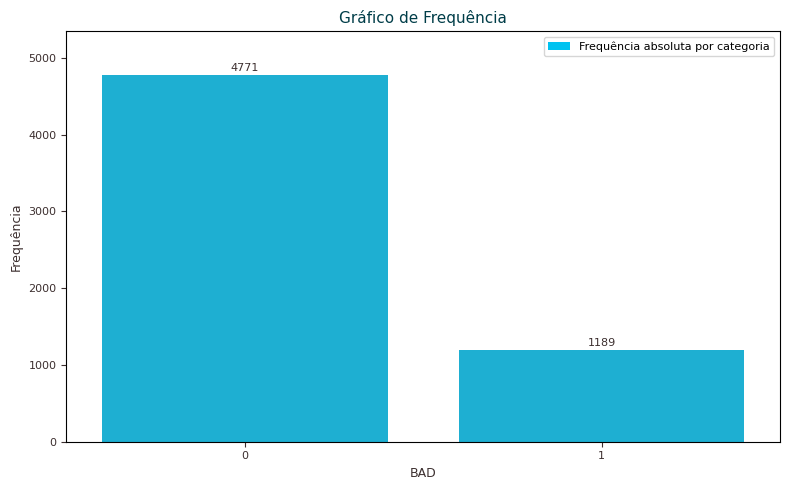

In [ ]:
univariada_variavel_categoria(df, "BAD")


taxa base de inadimplencia 20%

## 2.2 Perfil do Cliente (Estabilidade e Histórico de Crédito)

### YOJ — Anos no emprego atual

In [ ]:
var = "YOJ"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: YOJ
Quantidade de nulos: 515
% de nulos total: 8.64%
% de nulos em BAD=0: 9.43%
% de nulos em BAD=1: 5.47%


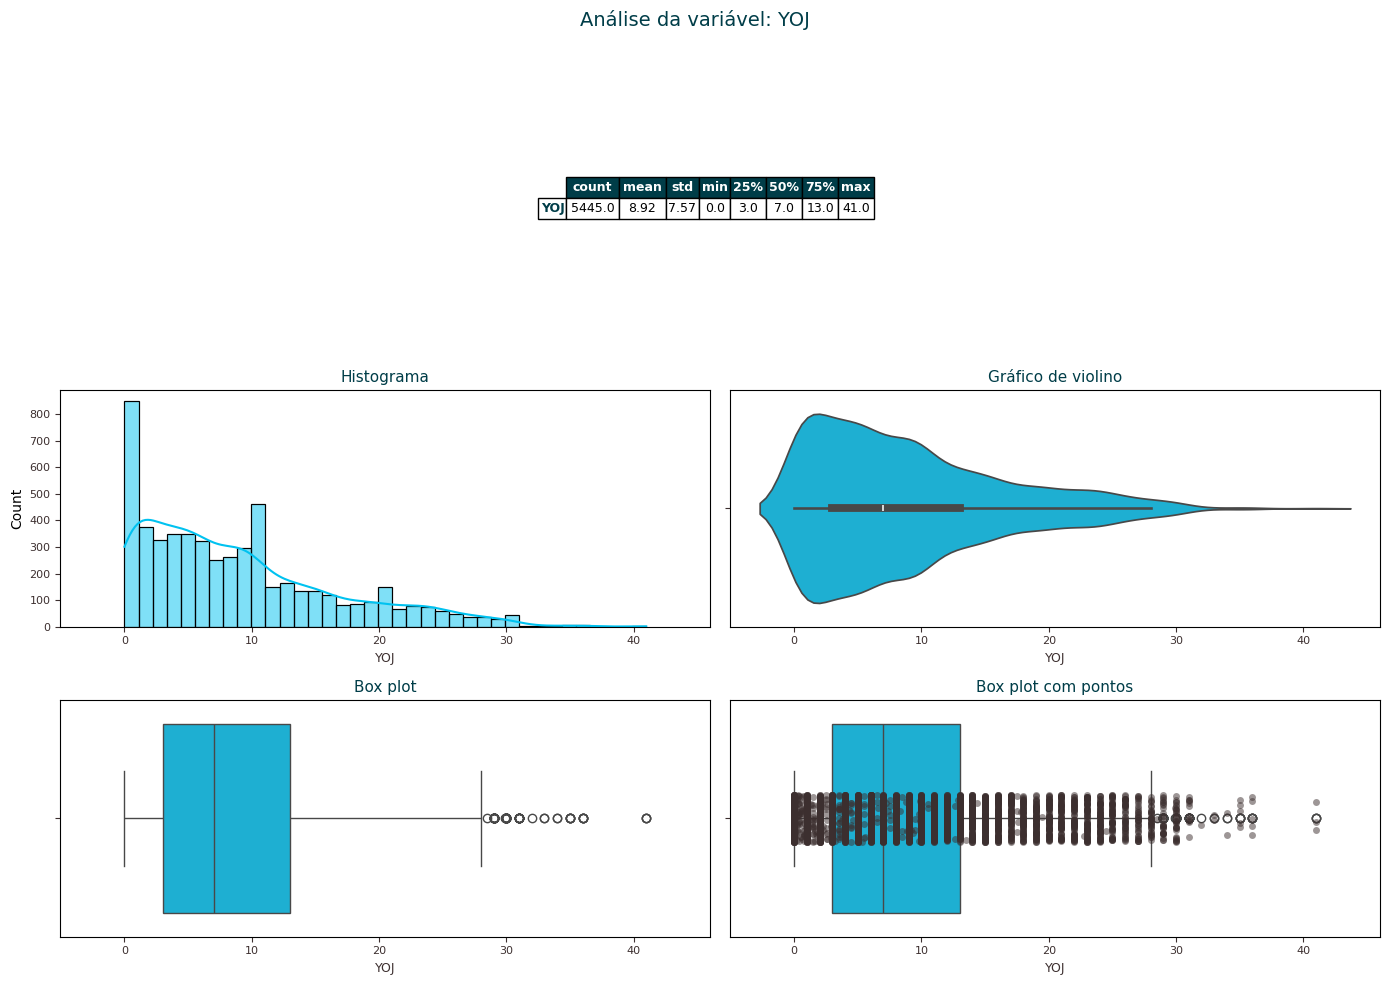

In [ ]:
univariada_variavel_numerica(df, "YOJ")

--> Média da idade de mercado de 9 anos, mas com desvio padrão foi de 7,6.

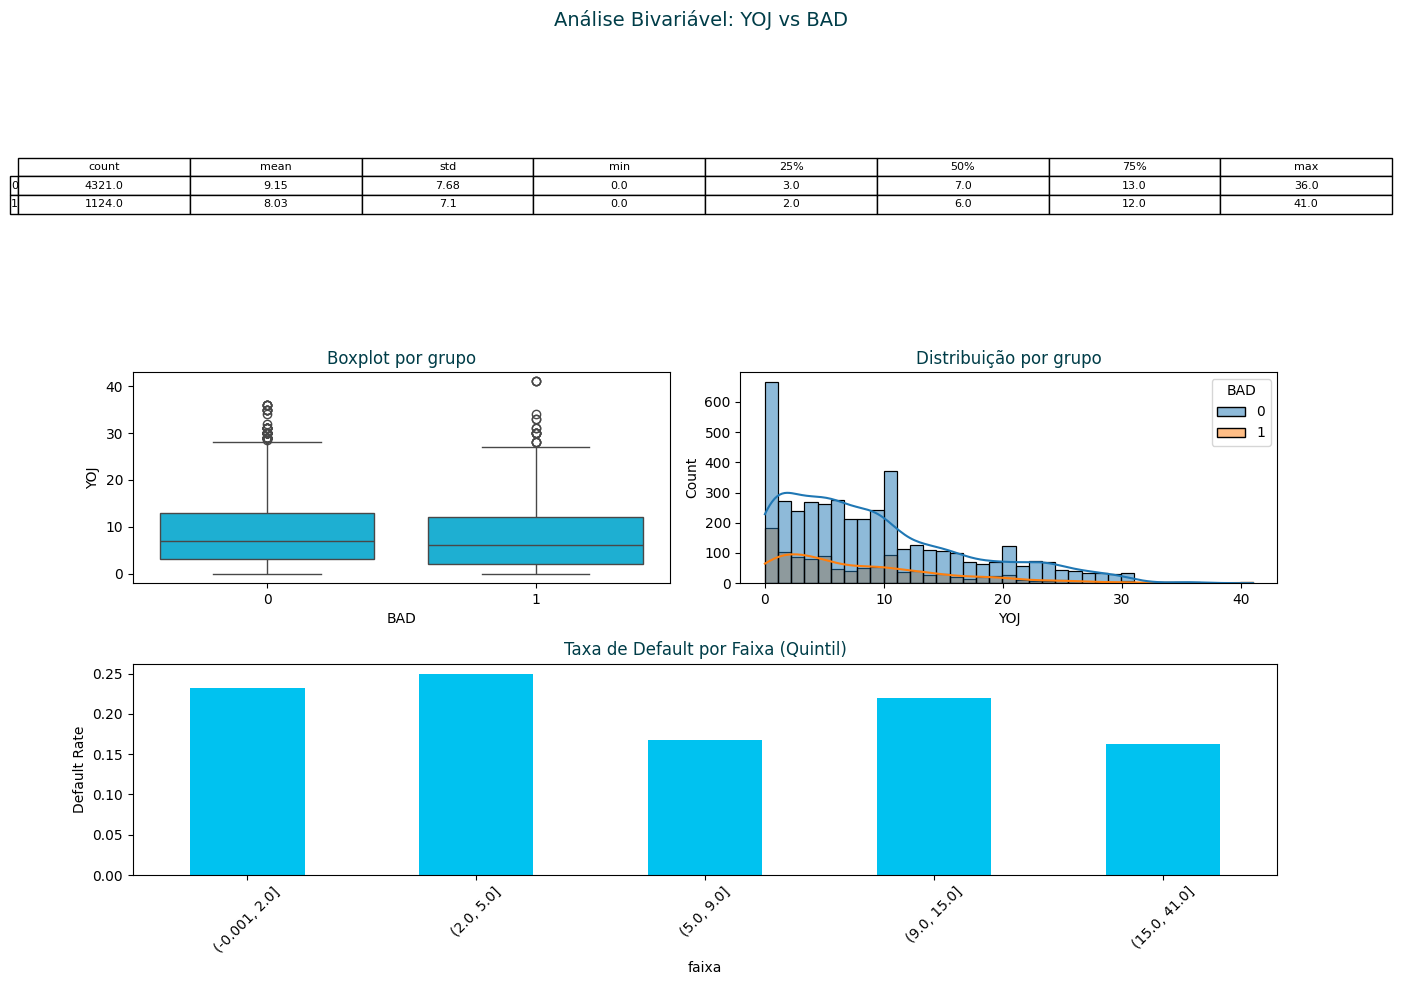

In [ ]:
bivariada_variavel_numerica_target(df, "YOJ", "BAD")

--> A relação de idade com a inadimplencia não tem diferença entre os 2 grupos.

### JOB — Categoria ocupacional

In [ ]:
var = "JOB"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: JOB
Quantidade de nulos: 279
% de nulos total: 4.68%
% de nulos em BAD=0: 5.37%
% de nulos em BAD=1: 1.93%


### JOB – Categoria ocupacional do solicitante

| Categoria | Descrição |
|------------|------------|
| Mgr | Gerente ou supervisor, com responsabilidade hierárquica |
| Office | Funcionário administrativo ou operacional de escritório |
| Other | Outras ocupações não classificadas nas categorias específicas |
| ProfExe | Profissional qualificado ou executivo (ex.: engenheiro, advogado, médico) |
| Sales | Profissional da área comercial, geralmente com renda variável |
| Self | Trabalhador autônomo ou por conta própria |

Describe da variável categórica:


,count,unique,top,freq
JOB,5681,6,Other,2388


Tabela de frequência da variável categórica (com percentuais e total):


,JOB,Frequência,Percentual (%)
0,Other,2388,40.07
1,ProfExe,1276,21.41
2,Office,948,15.91
3,Mgr,767,12.87
4,NaN,279,4.68
5,Self,193,3.24
6,Sales,109,1.83
7,Total,5960,100.00


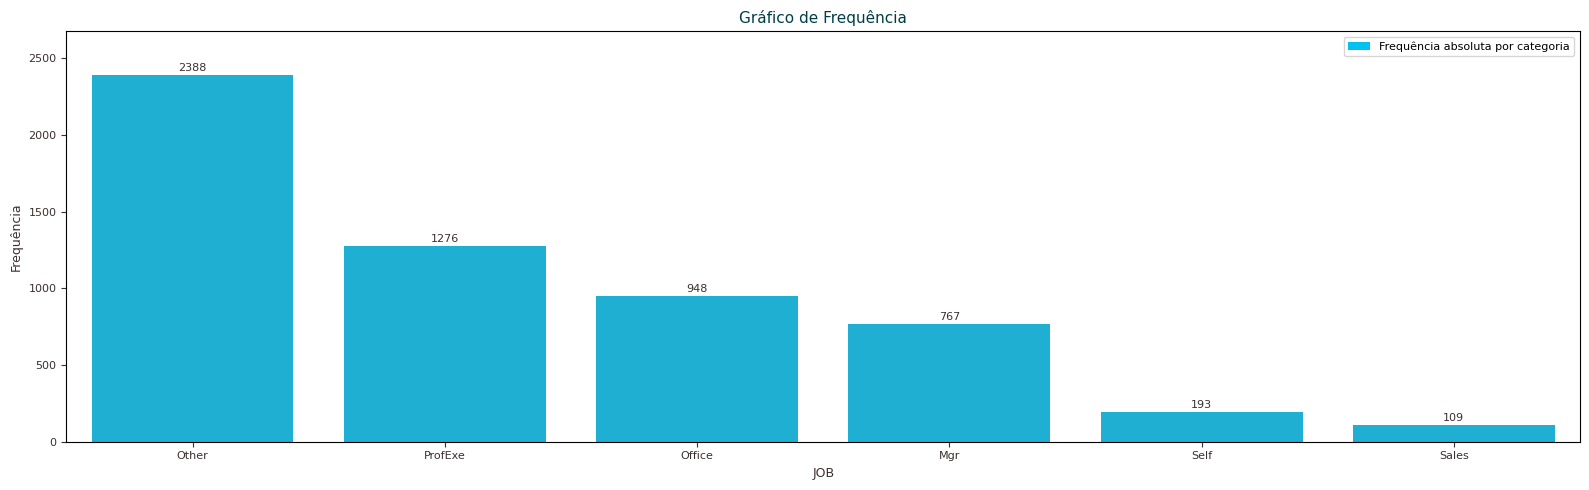

In [ ]:

univariada_variavel_categoria(df, "JOB")

Tabela Cruzada (Frequência):


BAD,0,1,All
JOB,,,
Mgr,588,179,767
Office,823,125,948
Other,1834,554,2388
ProfExe,1064,212,1276
Sales,71,38,109
Self,135,58,193
All,4515,1166,5681



Percentual de Default por Categoria (%):


BAD,0,1
JOB,,
Mgr,76.66,23.34
Office,86.81,13.19
Other,76.80,23.20
ProfExe,83.39,16.61
Sales,65.14,34.86
Self,69.95,30.05


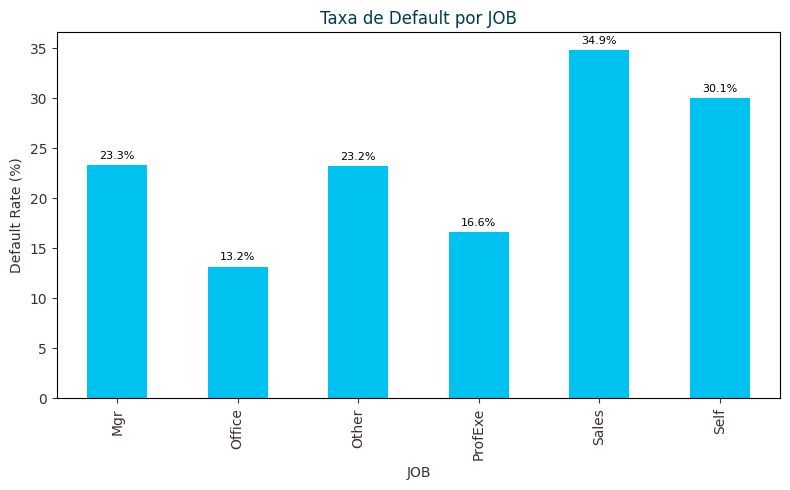

In [ ]:
bivariada_variavel_categoria_target(df, "JOB", "BAD")

-> a Taxa de Default por job coloca como maior para vendas e depois

###CLAGE — Tempo de histórico de crédito

In [ ]:
var = "CLAGE"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: CLAGE
Quantidade de nulos: 308
% de nulos total: 5.17%
% de nulos em BAD=0: 4.82%
% de nulos em BAD=1: 6.56%


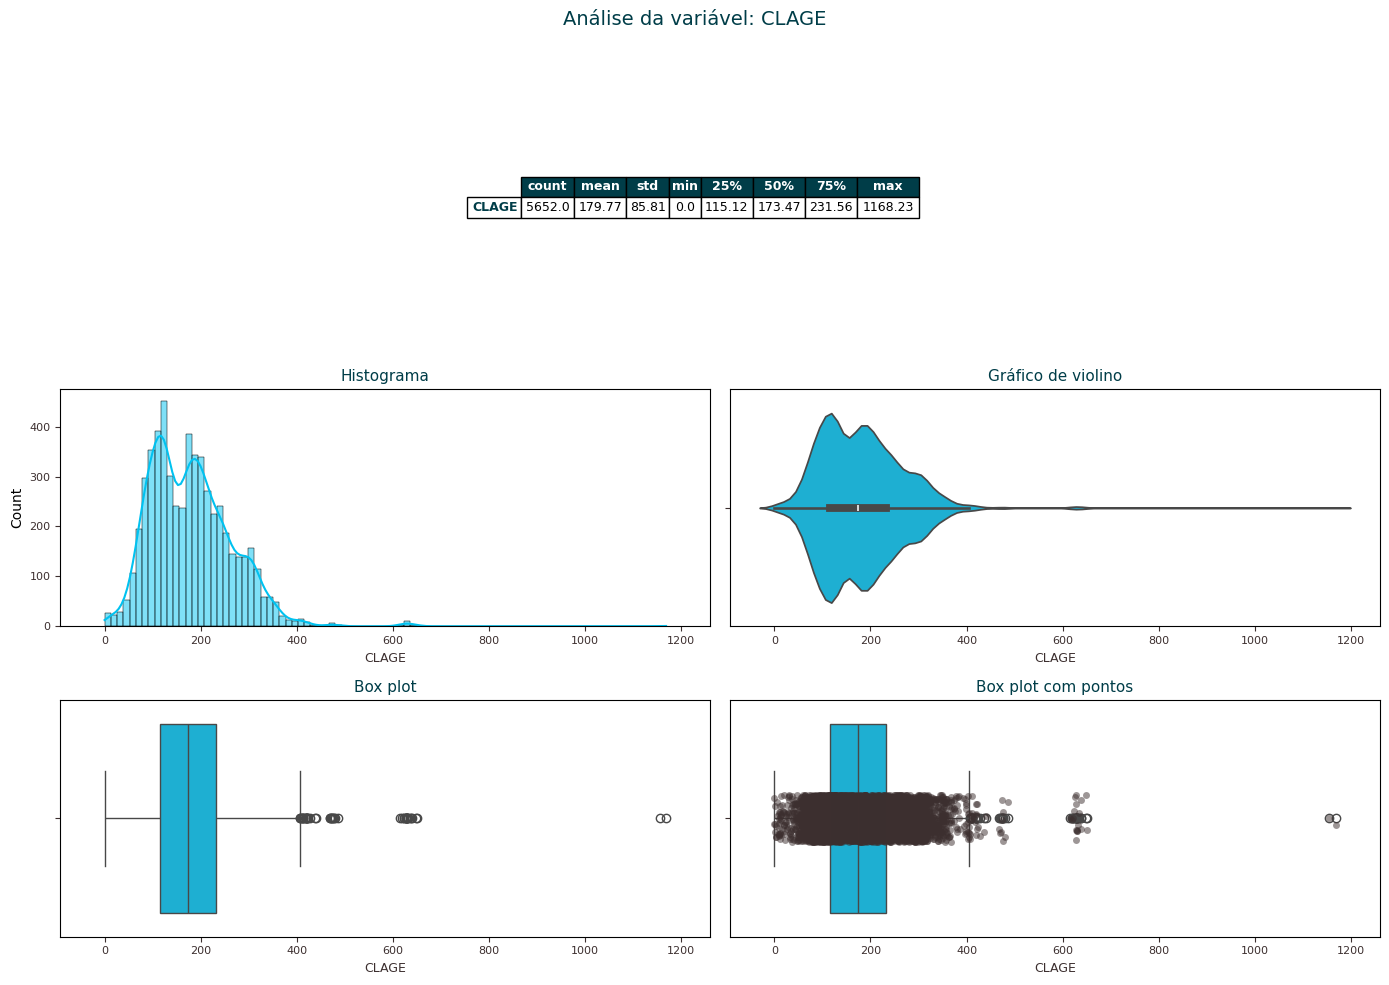

In [ ]:
univariada_variavel_numerica(df, "CLAGE")

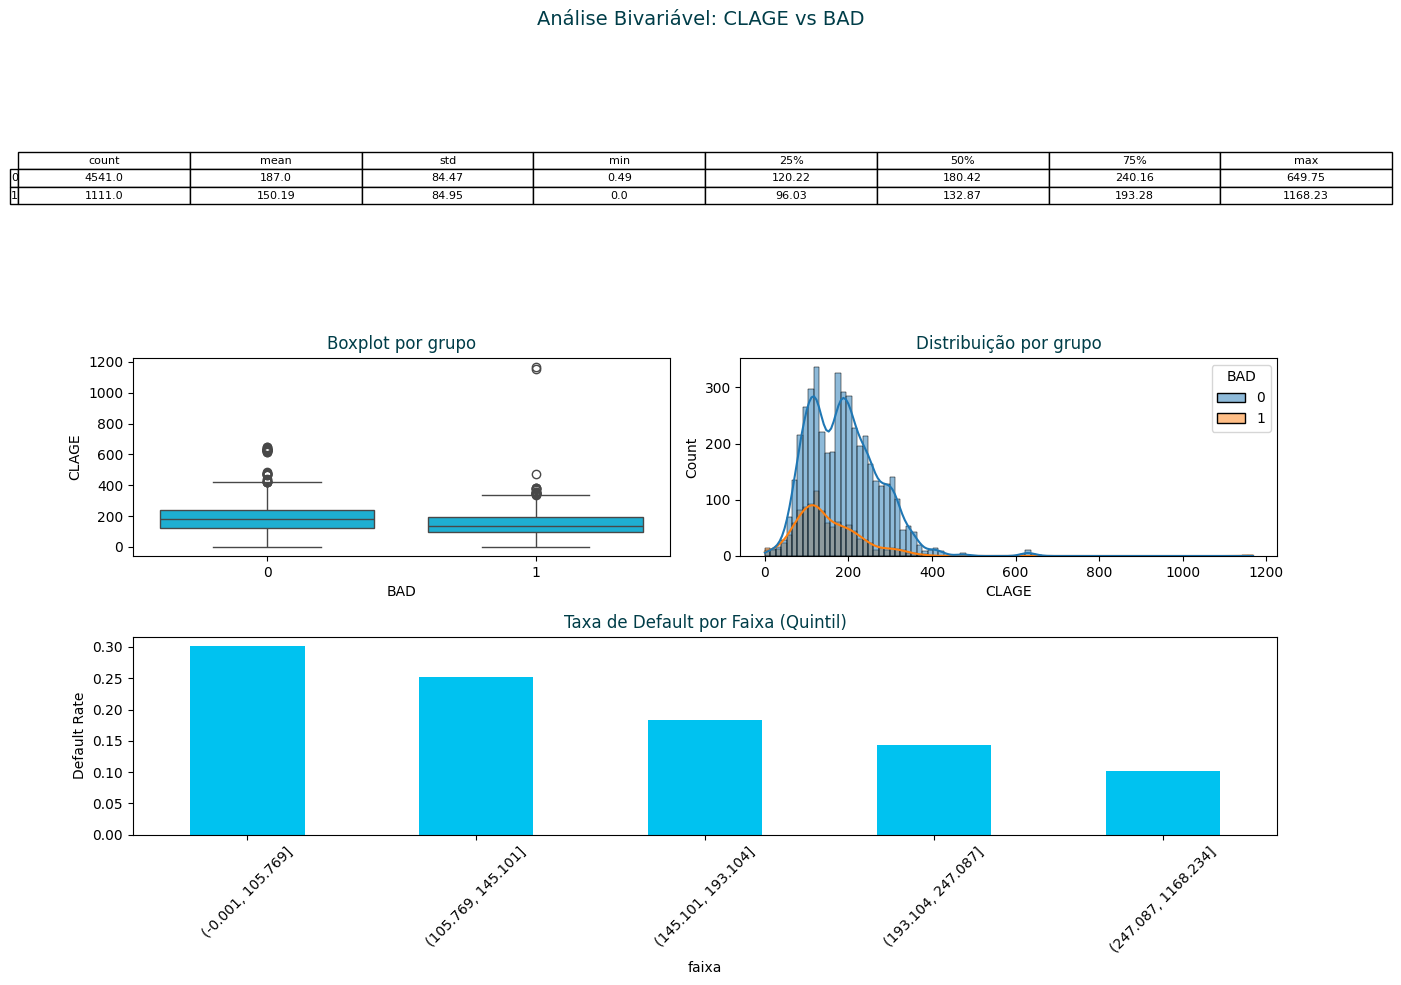

In [ ]:
bivariada_variavel_numerica_target(df, "CLAGE", "BAD")

--> Tempo de histórico de crédito tem comportamentos distintos quanto a média e mediana mas com desvio padrão similar, para adimplentes em torno de 197 de media, e mediana de 180.. para inadimplentes 132 . Inadimplentes tem mais outliers nesse tempo de historico de credito. E tem bastante nulo... nesse caso a media por grupo ou mediana faria mais sentido?

###CLNO — Número total de linhas de crédito

In [ ]:
var = "CLNO"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: CLNO
Quantidade de nulos: 222
% de nulos total: 3.72%
% de nulos em BAD=0: 3.54%
% de nulos em BAD=1: 4.46%


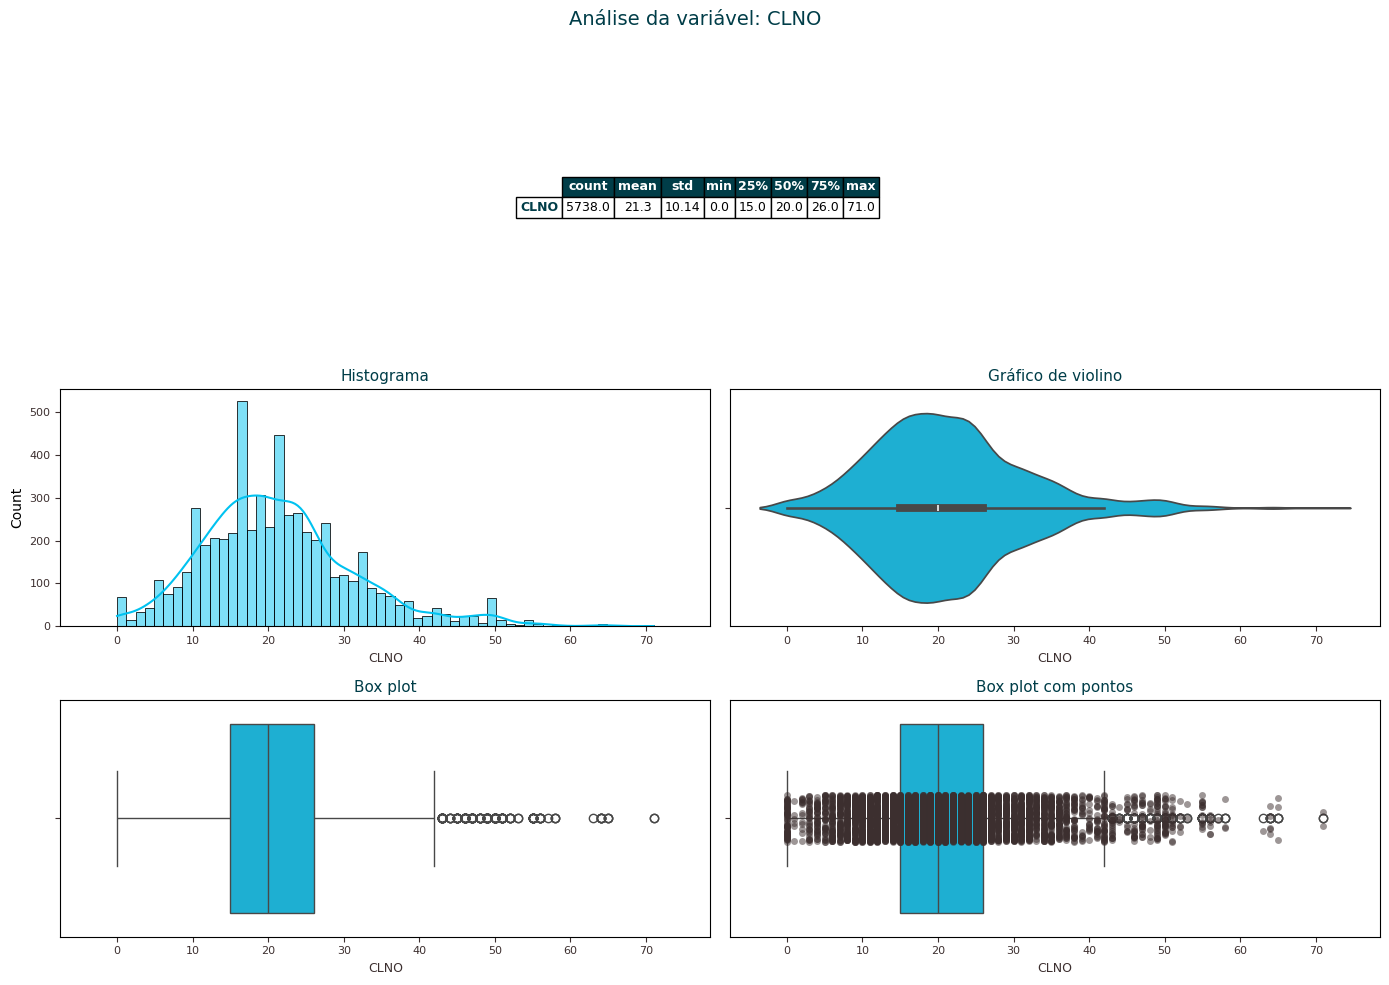

In [ ]:

univariada_variavel_numerica(df, "CLNO")

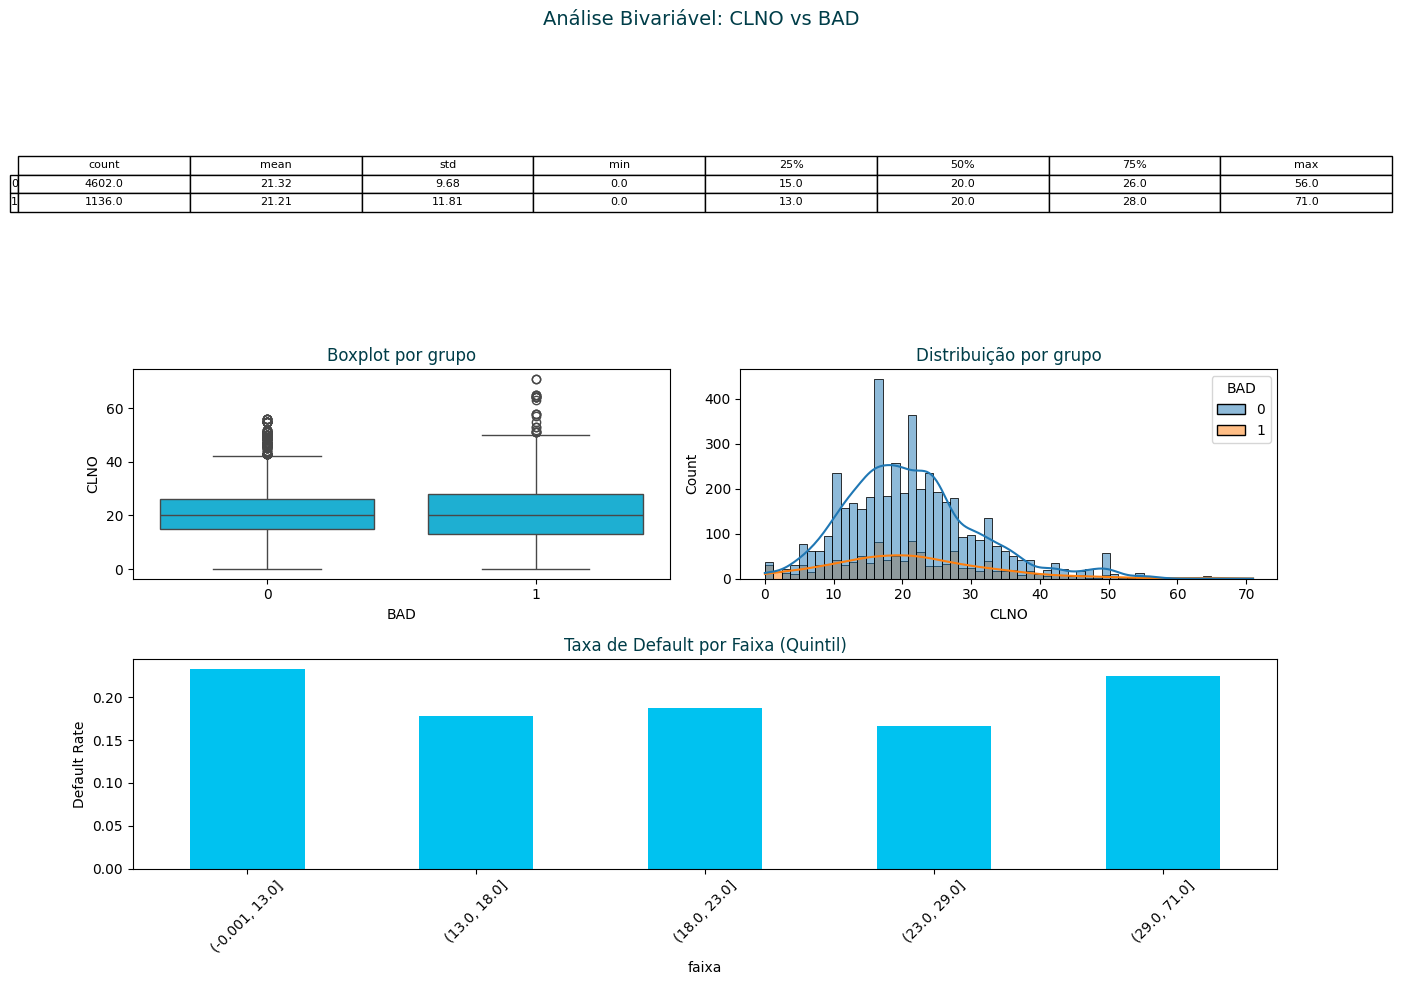

In [ ]:
bivariada_variavel_numerica_target(df, "CLNO", "BAD")

- análise: a quantidade total de linhas de crédito tem baixa relação com inadimplencia, a media e mediana dos dois grupos sao iguais. O que muda são alguns outliers significativos para inadimplentes.

##2.3 Capacidade de Pagamento

###DEBTINC - Relação Dívida/Renda (Debt-to-Income Ratio)

In [ ]:
var = "DEBTINC"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: DEBTINC
Quantidade de nulos: 1267
% de nulos total: 21.26%
% de nulos em BAD=0: 10.08%
% de nulos em BAD=1: 66.11%


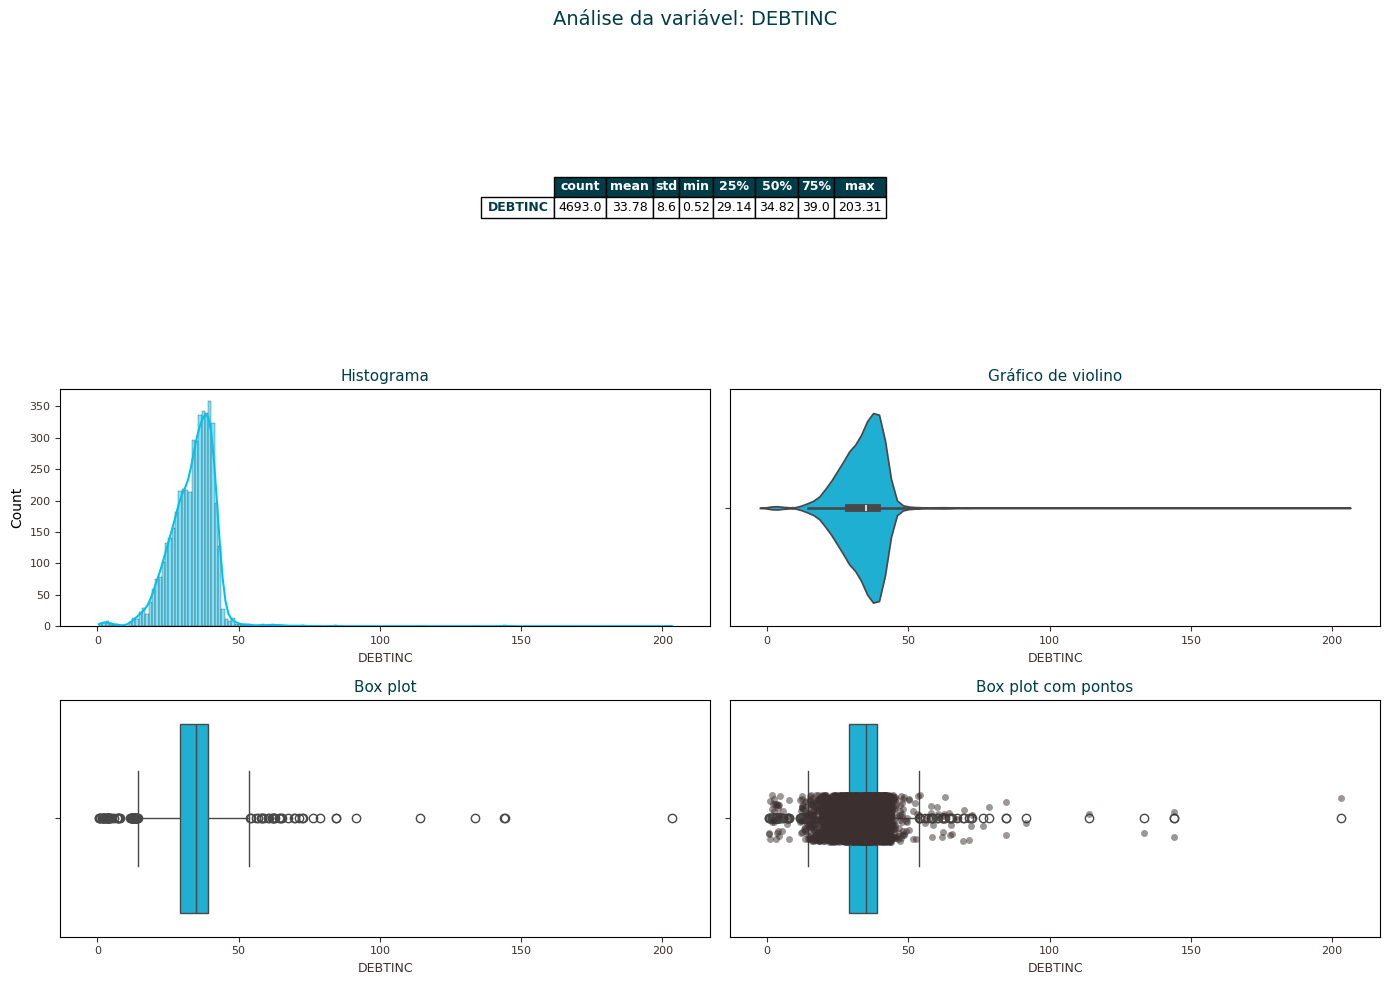

In [ ]:
univariada_variavel_numerica(df, "DEBTINC")

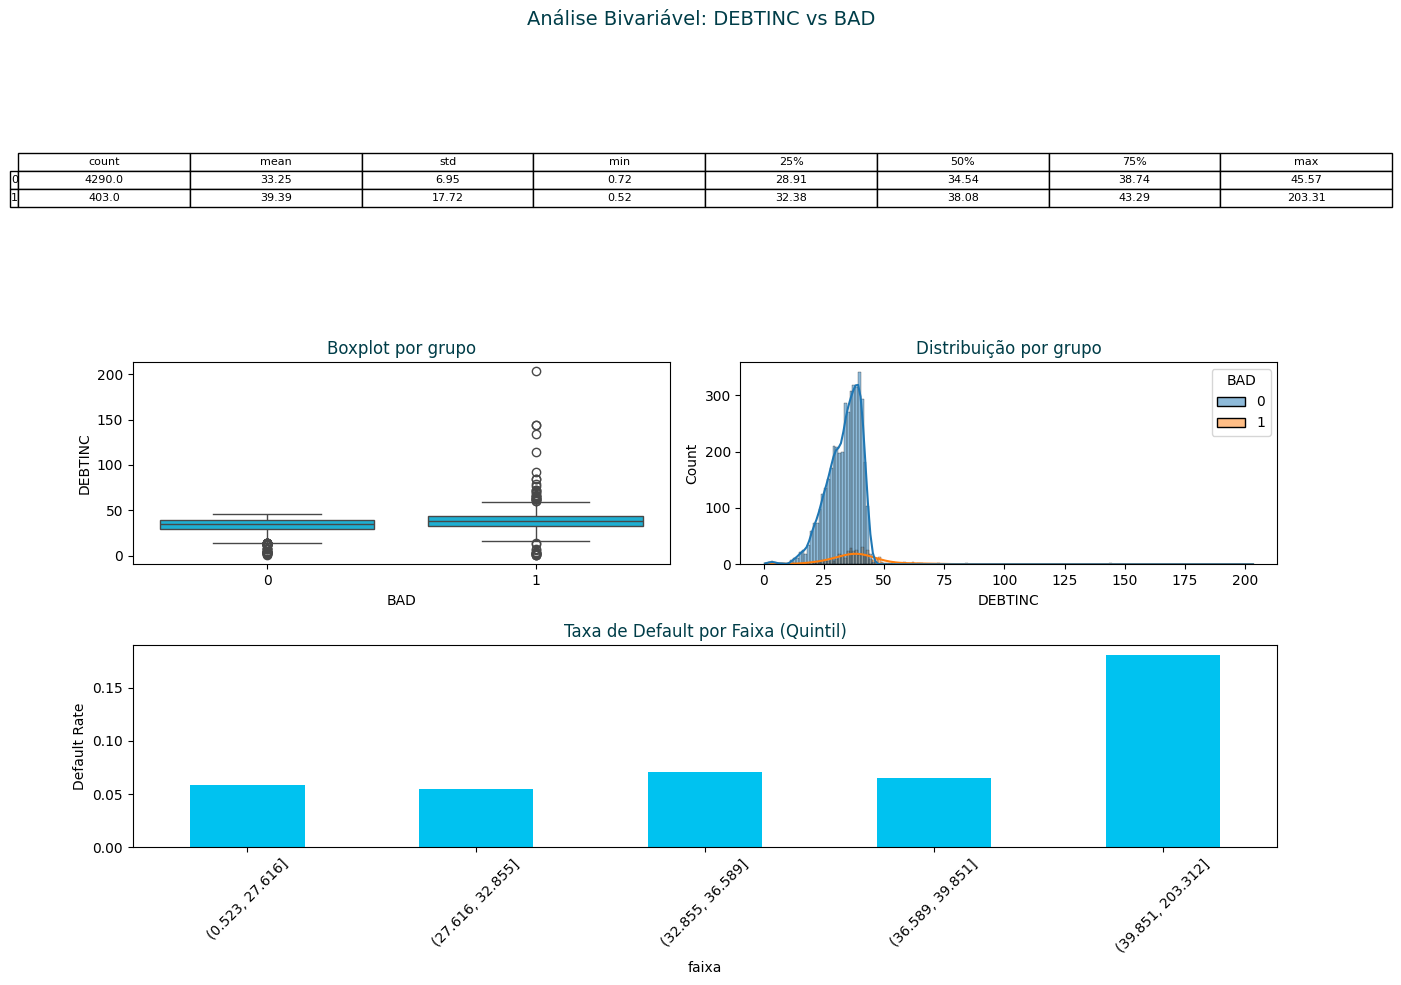

In [ ]:
bivariada_variavel_numerica_target(df, "DEBTINC", "BAD")

- análise:o default rate aumenta significativamente conforme aumenta a relação de capacidade de pagamento, inadimplentes possuem bastante outliers.

###DELINQ - Número de Linhas em Inadimplência

In [ ]:
var = "DELINQ"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: DELINQ
Quantidade de nulos: 580
% de nulos total: 9.73%
% de nulos em BAD=0: 10.65%
% de nulos em BAD=1: 6.06%


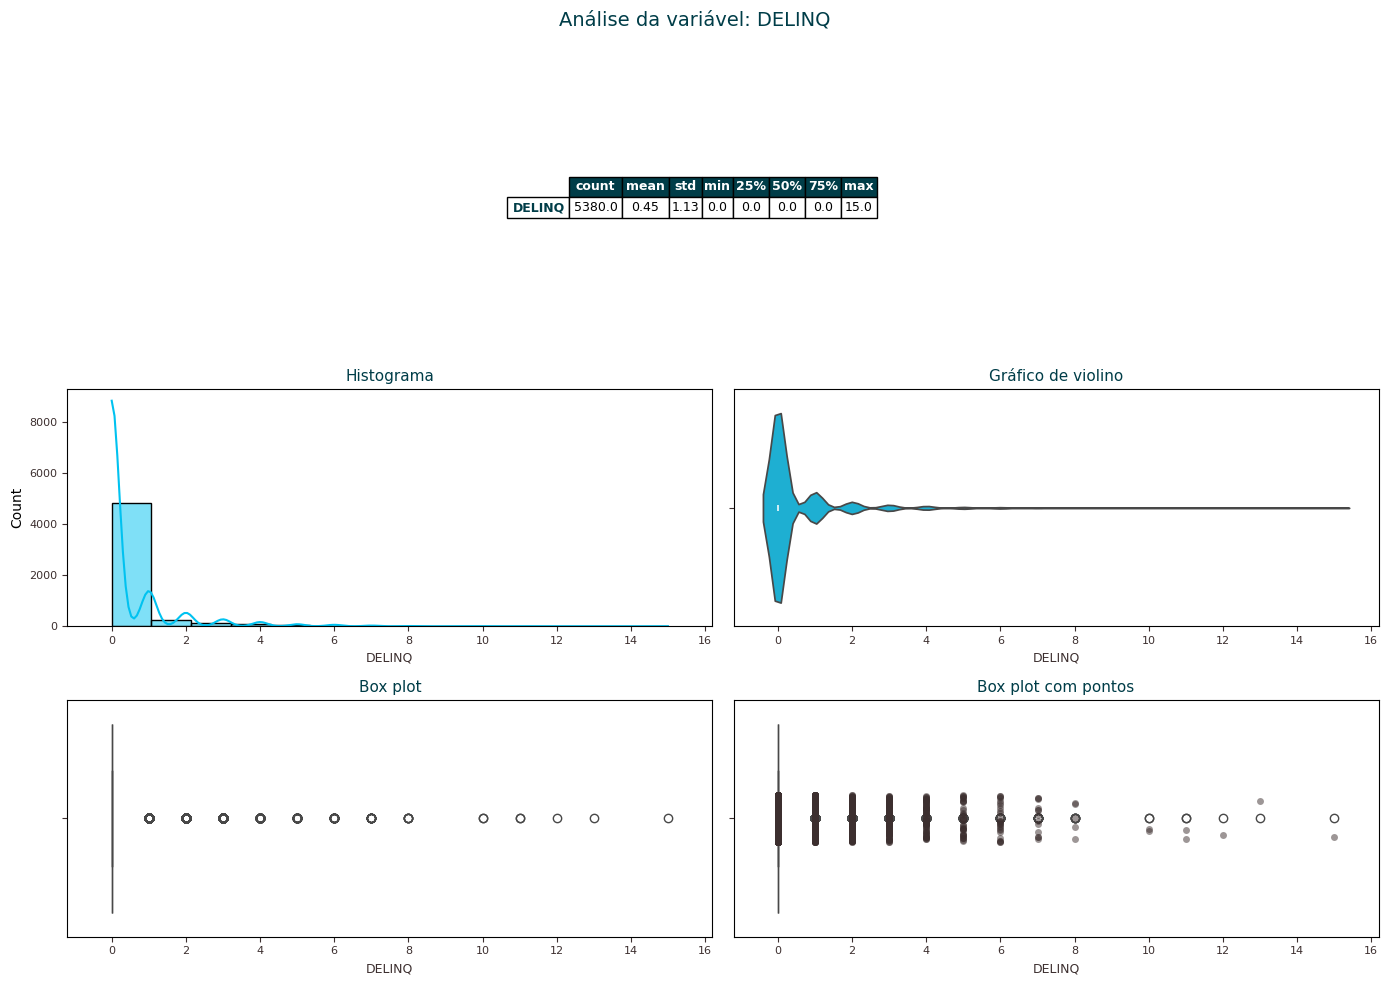

In [ ]:
univariada_variavel_numerica(df, "DELINQ")

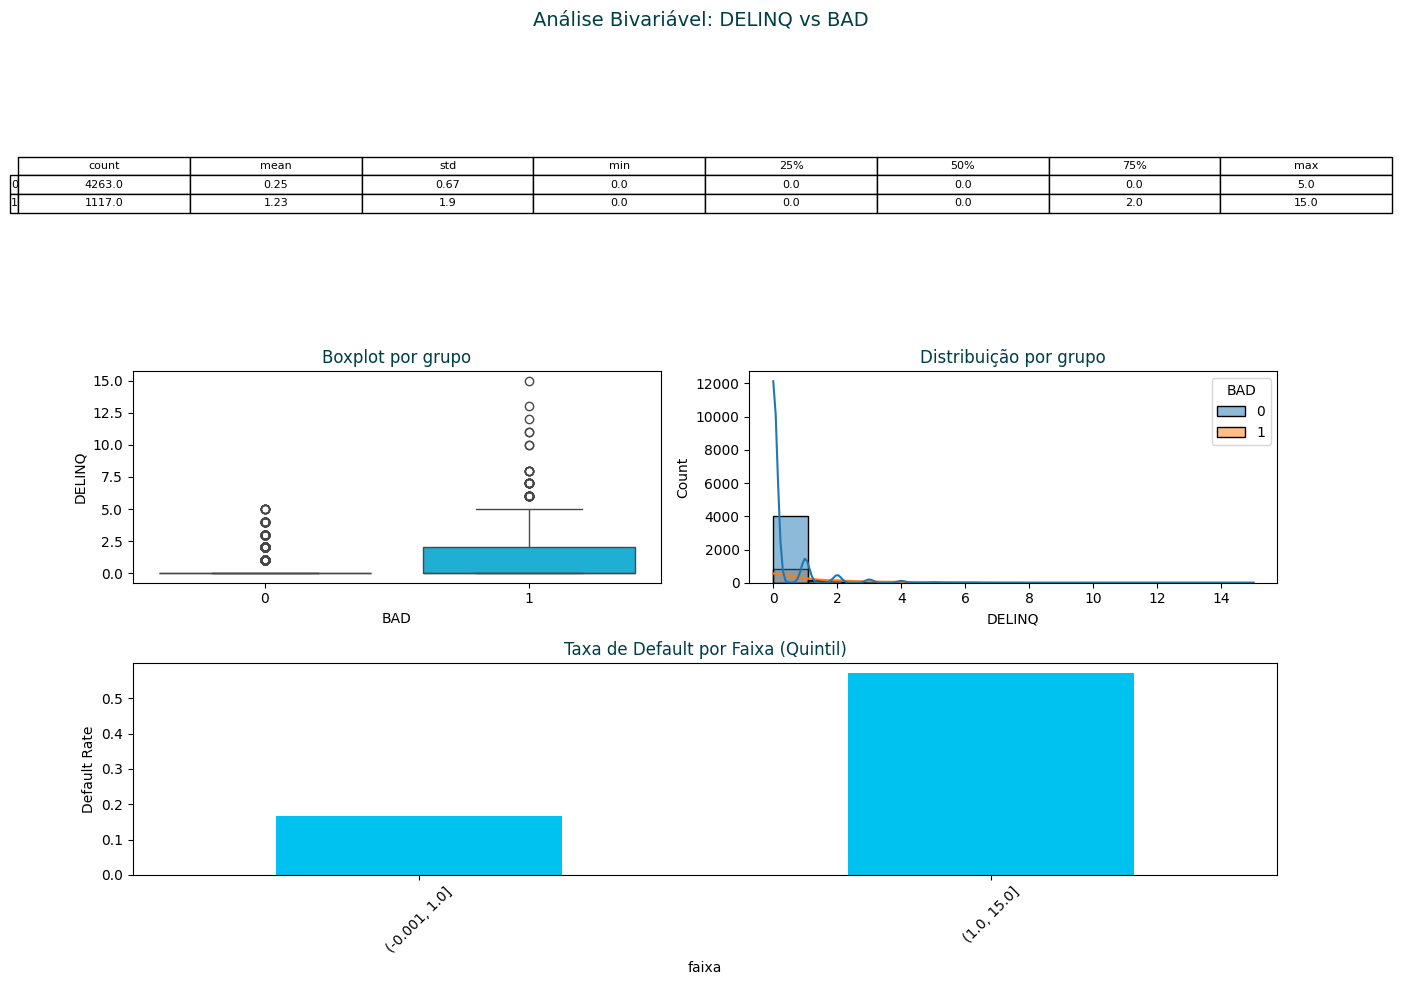

In [ ]:
bivariada_variavel_numerica_target(df, "DELINQ", "BAD")

analise- a quantidade de linhas de inadimplencia tem medias distinta de quem não esta inadimplente, e é quase 0 quem tem outras inadimplencias e esta inadimplente.

###DEROG - Número de Registros Negativos no Histórico

In [ ]:
var = "DEROG"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: DEROG
Quantidade de nulos: 708
% de nulos total: 11.88%
% de nulos em BAD=0: 13.02%
% de nulos em BAD=1: 7.32%


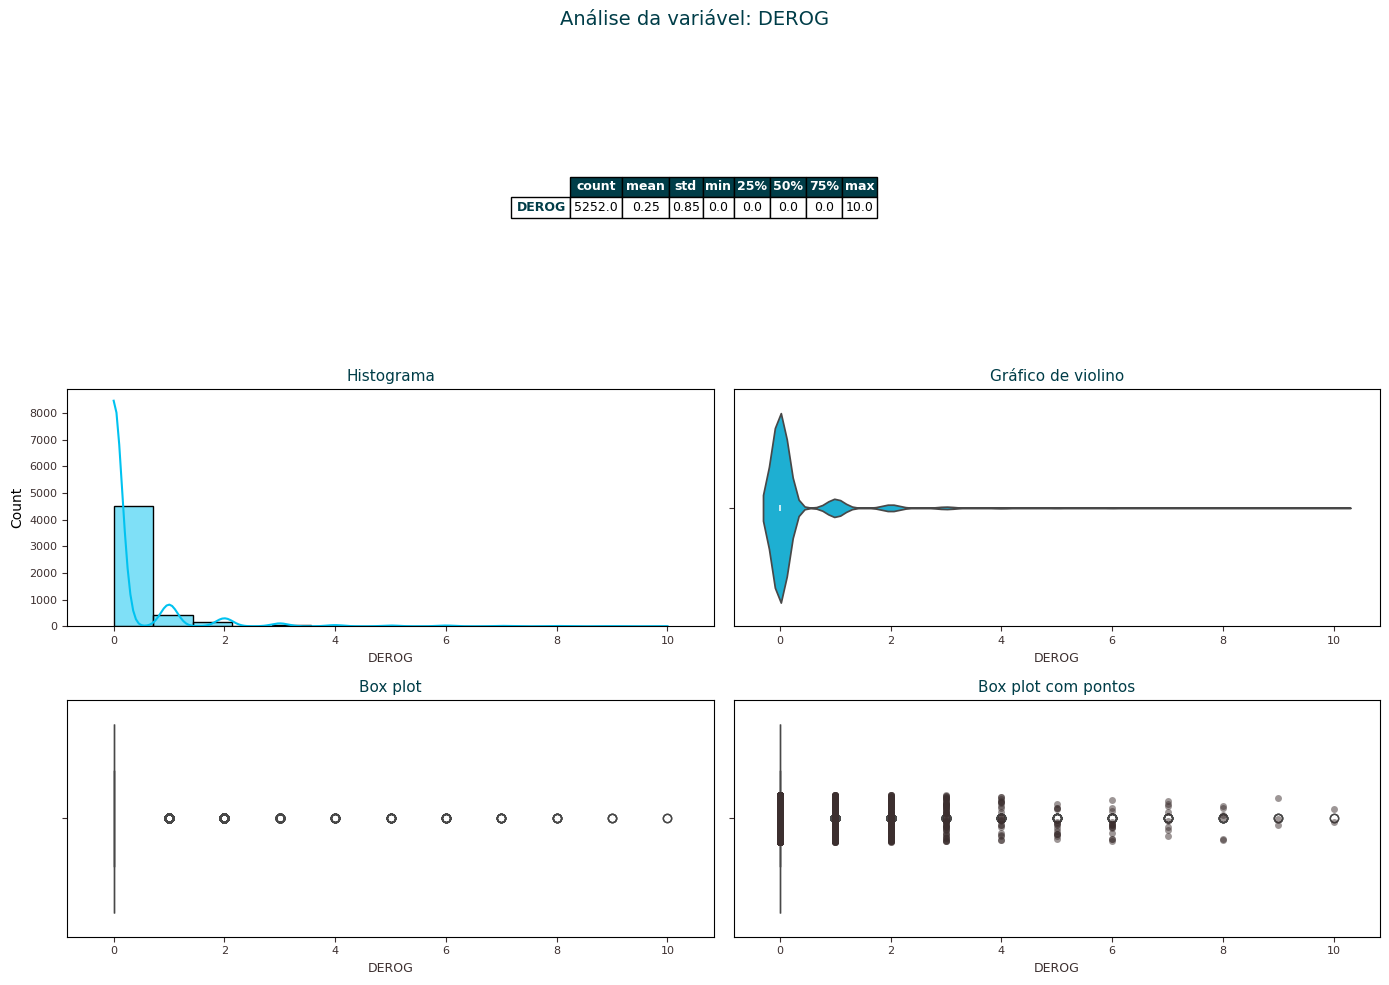

In [ ]:
univariada_variavel_numerica(df, "DEROG")

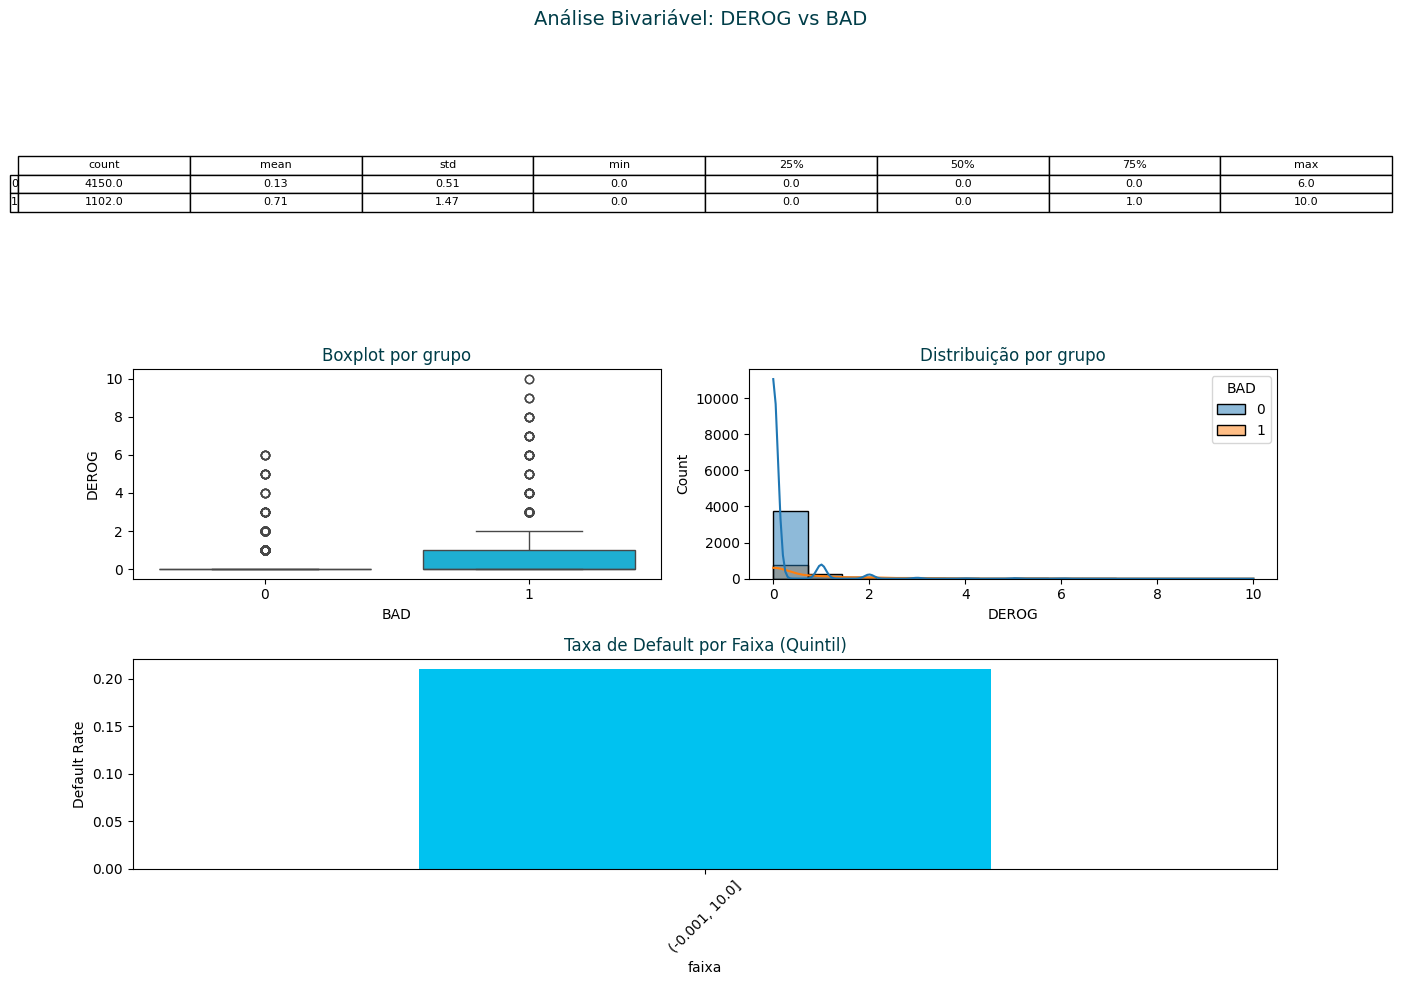

In [ ]:
bivariada_variavel_numerica_target(df, "DEROG", "BAD")

analise - default rate tem relação com registros negativos de histórico

###NINQ - Número de Consultas de Crédito Recentes

In [ ]:
var = "NINQ"

total = len(df
            )
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: NINQ
Quantidade de nulos: 510
% de nulos total: 8.56%
% de nulos em BAD=0: 9.12%
% de nulos em BAD=1: 6.31%


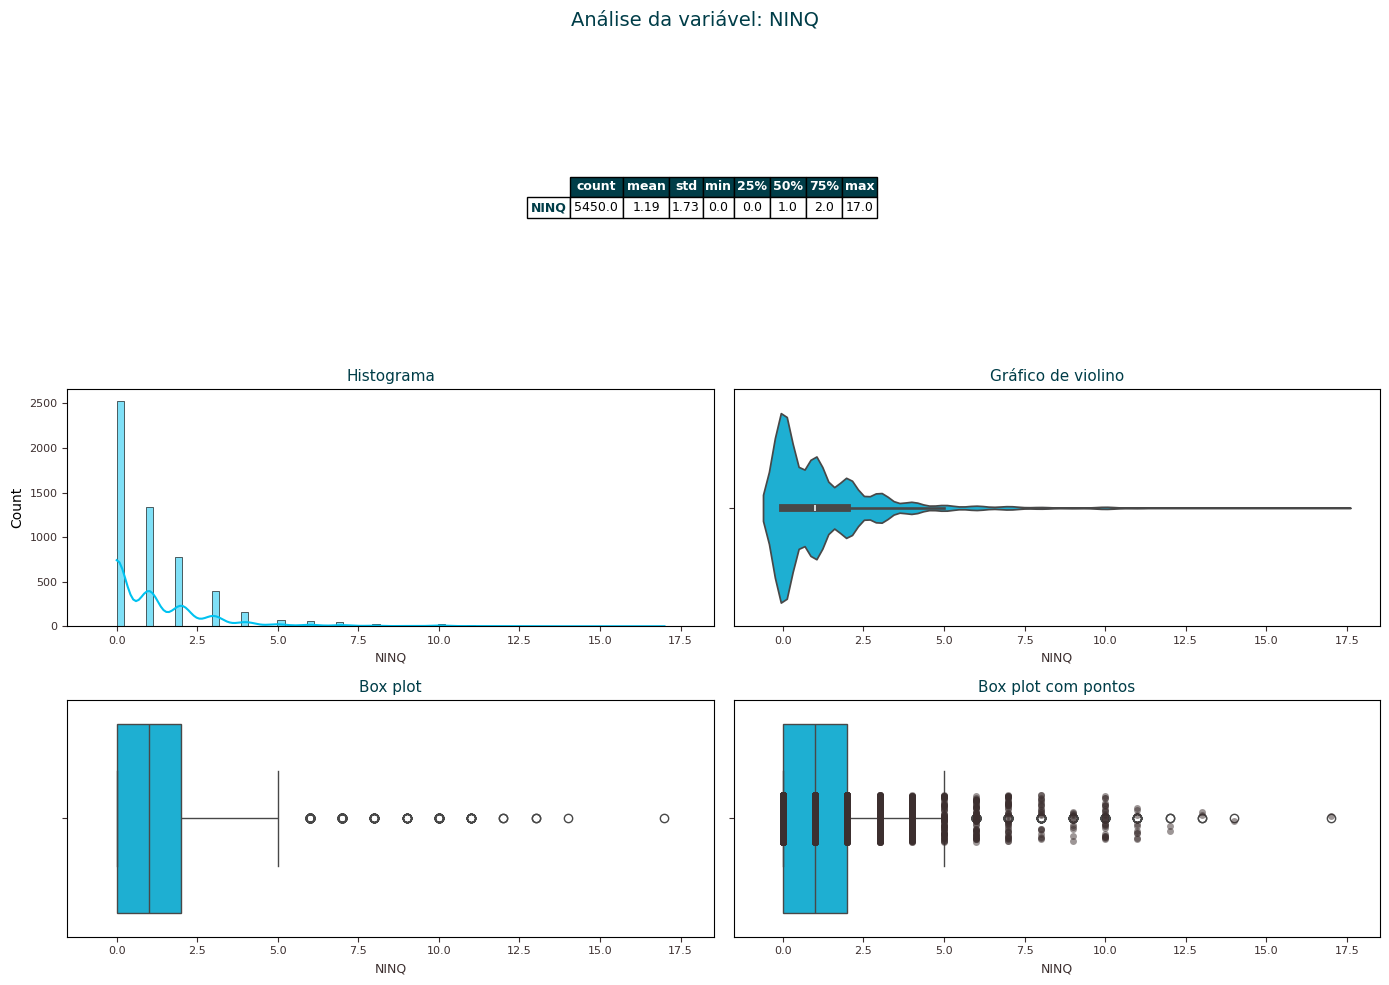

In [ ]:
univariada_variavel_numerica(df, "NINQ")

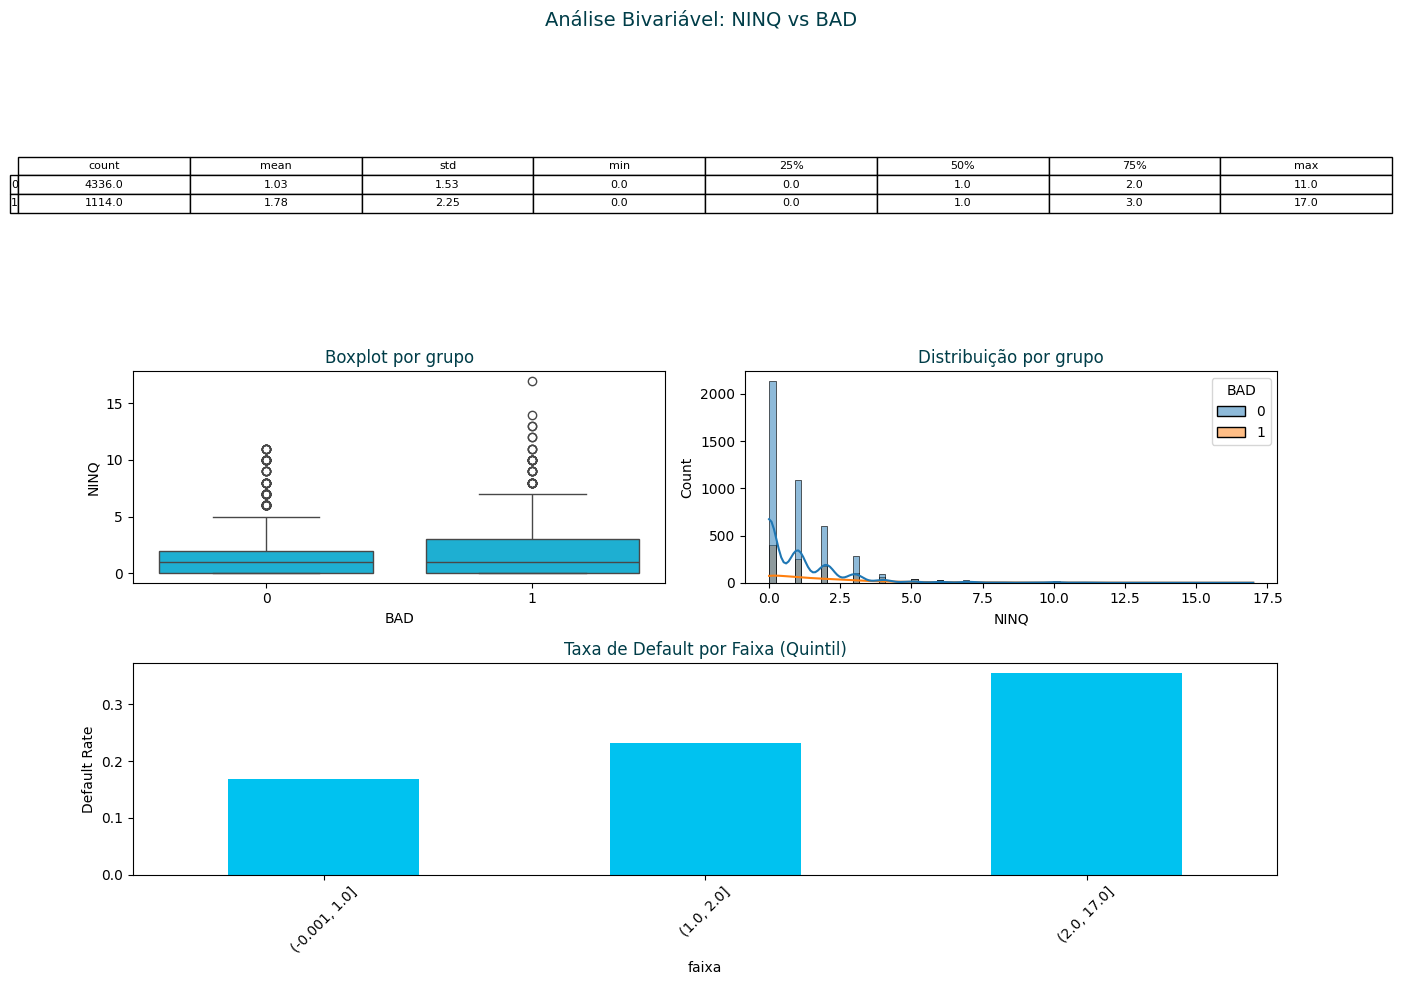

In [ ]:
bivariada_variavel_numerica_target(df, "NINQ", "BAD")

analise - numero de consultas de creditos recentes tem um peso maior quando são mais de 2 consultas.

##2.4 Estrutura da Operação

###LOAN — Valor do Empréstimo

In [ ]:
var = "LOAN"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: LOAN
Quantidade de nulos: 0
% de nulos total: 0.0%
% de nulos em BAD=0: 0.0%
% de nulos em BAD=1: 0.0%


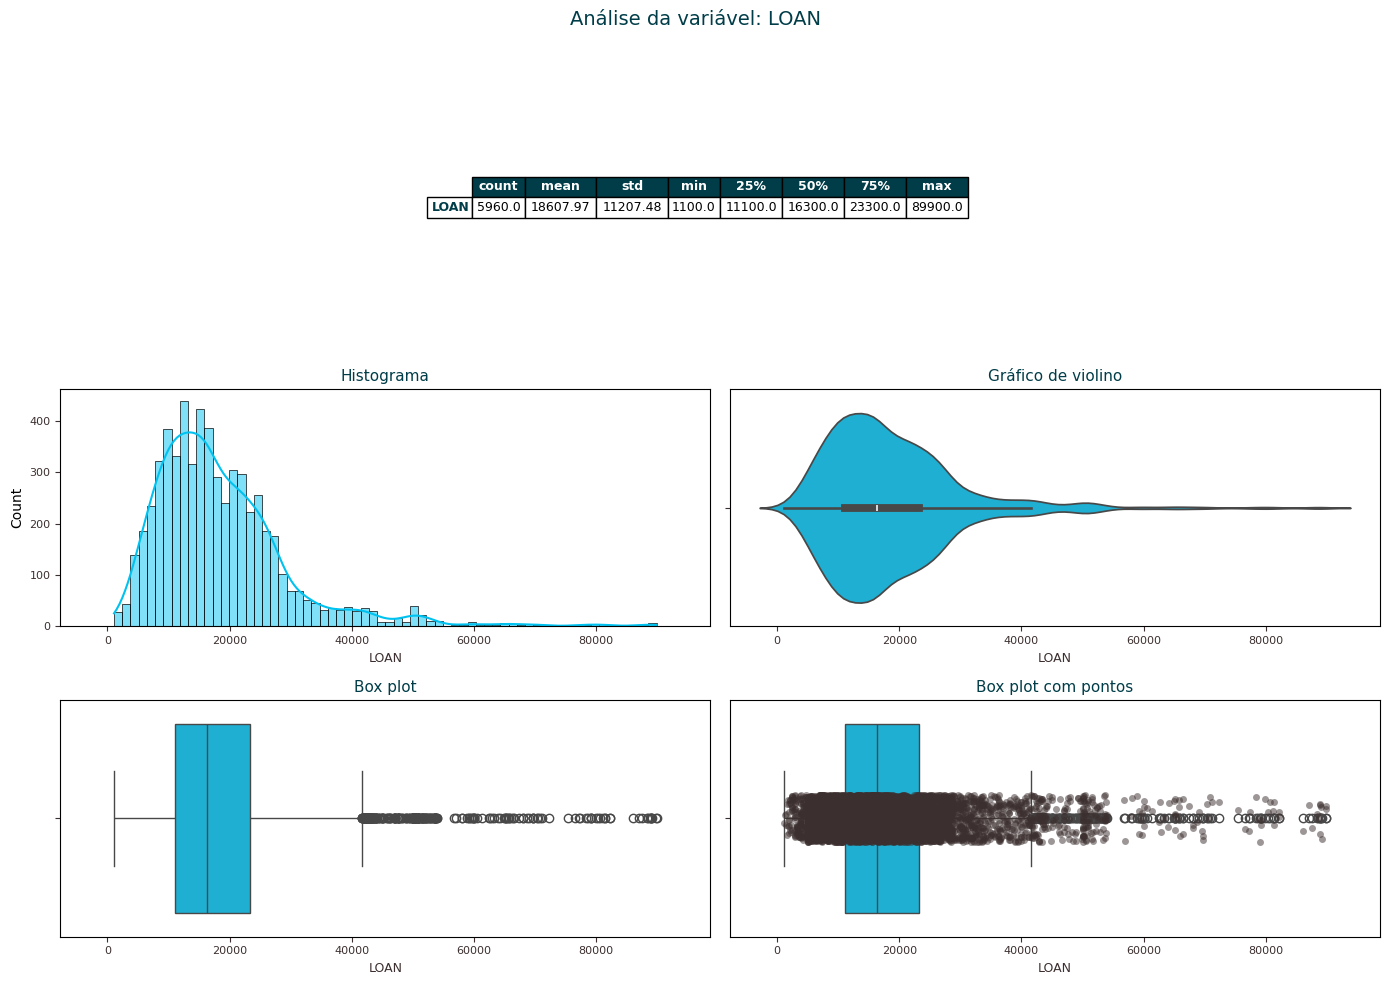

In [ ]:
univariada_variavel_numerica(df, "LOAN")

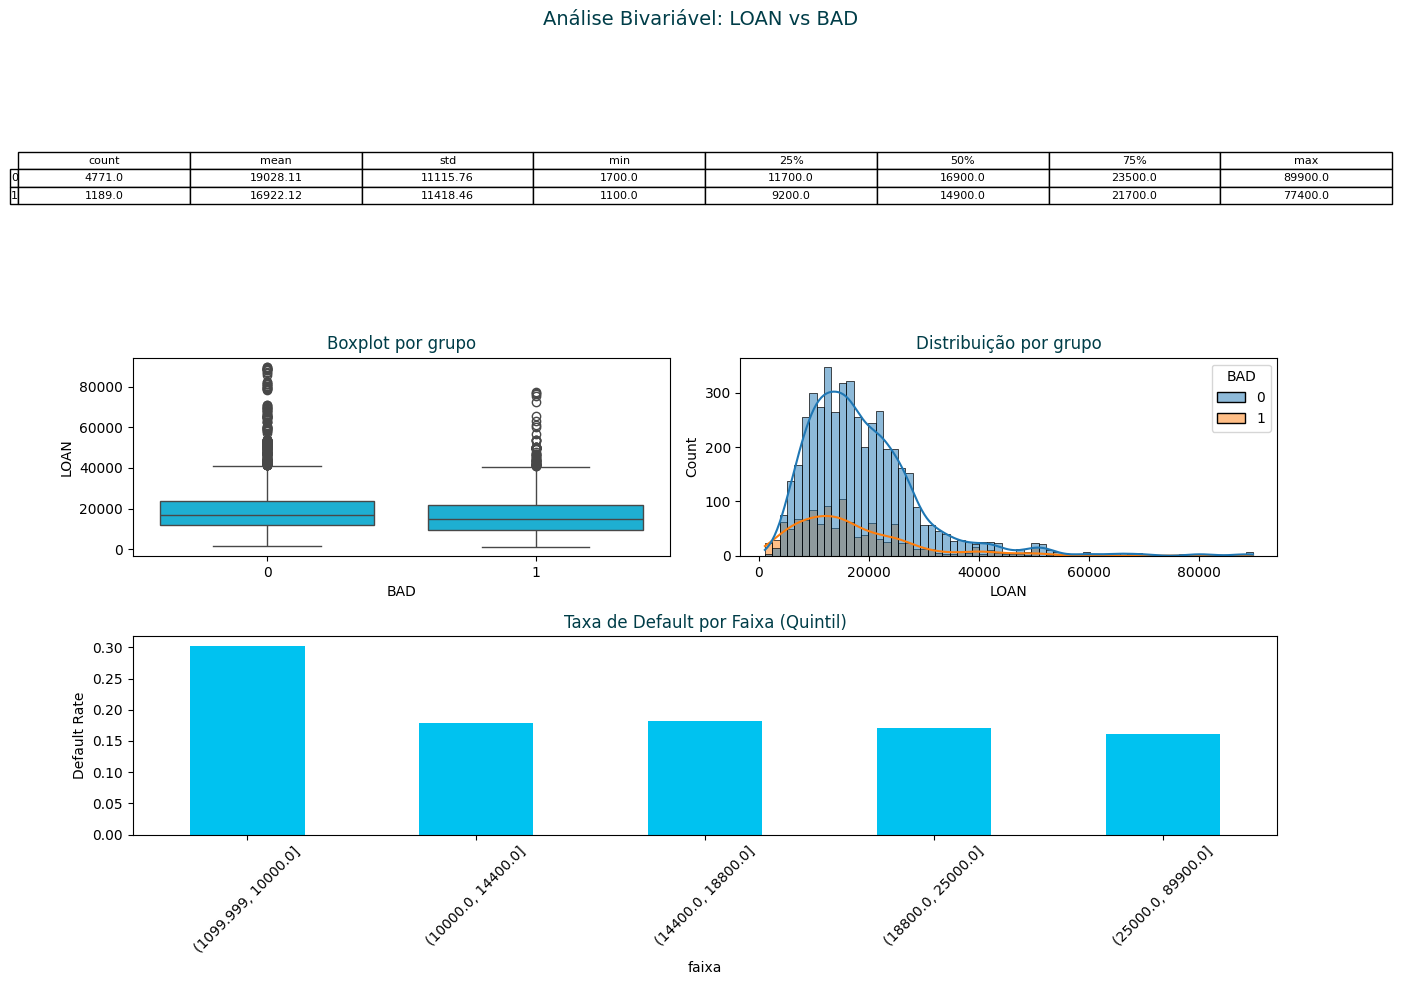

In [ ]:
bivariada_variavel_numerica_target(df, "LOAN", "BAD")

analise - o valor do empréstimo tem maior influência na inadimplencia quando é até 10k, mas em media o comportamento é parecido.

Teste de diferença de médias

- **H₀ (Hipótese nula):** Não existe diferença no valor médio do empréstimo entre clientes inadimplentes (BAD = 1) e adimplentes (BAD = 0).

- **H₁ (Hipótese alternativa):** Existe diferença no valor médio do empréstimo entre clientes inadimplentes (BAD = 1) e adimplentes (BAD = 0).

In [ ]:
from scipy.stats import ttest_ind

grupo_0 = df[df["BAD"] == 0]["LOAN"].dropna()
grupo_1 = df[df["BAD"] == 1]["LOAN"].dropna()

ttest_ind(grupo_0, grupo_1)

TtestResult(statistic=np.float64(5.81315745785895), pvalue=np.float64(6.448273297751198e-09), df=np.float64(5958.0))

Rejeitamos H₀. Existe diferença estatisticamente significativa entre o valor médio do empréstimo (LOAN) de inadimplentes e não inadimplentes.

Default rate por quintil (tabela)

In [ ]:
temp = df[["LOAN", "BAD"]].copy()
temp["faixa"] = pd.qcut(temp["LOAN"], 5, duplicates="drop")

temp.groupby("faixa")["BAD"].mean().reset_index()

,faixa,BAD
0,"(1099.999, 10000.0]",0.302230
1,"(10000.0, 14400.0]",0.178691
2,"(14400.0, 18800.0]",0.181895
3,"(18800.0, 25000.0]",0.171096
4,"(25000.0, 89900.0]",0.161401


O risco diminui conforme o valor do empréstimo aumenta.

###VALUE — Valor do Imóvel

In [ ]:
var = "VALUE"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: VALUE
Quantidade de nulos: 112
% de nulos total: 1.88%
% de nulos em BAD=0: 0.15%
% de nulos em BAD=1: 8.83%


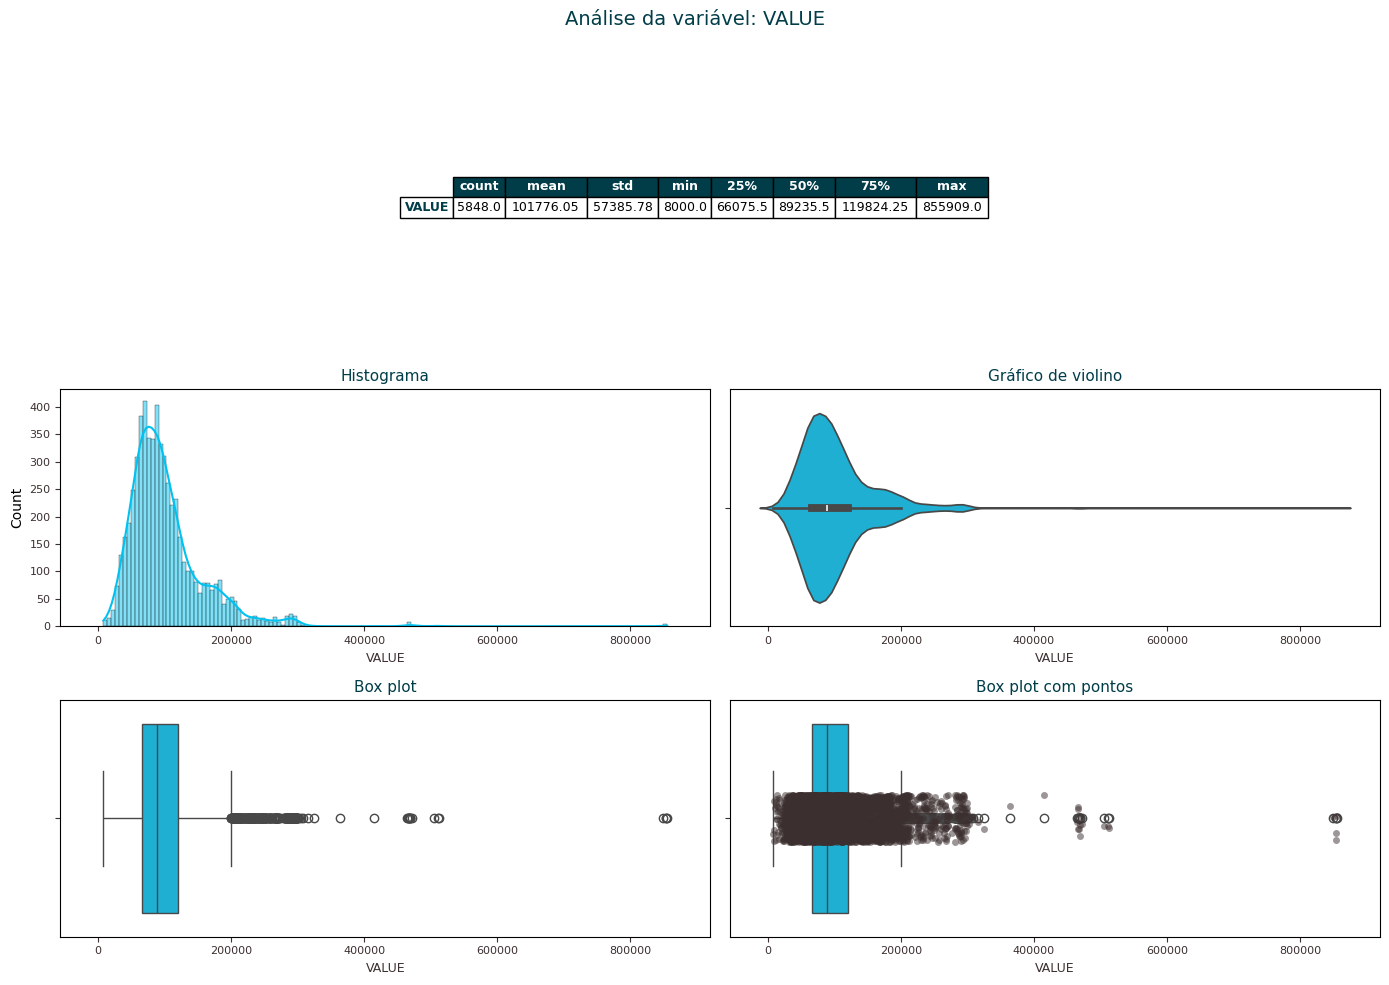

In [ ]:
univariada_variavel_numerica(df, "VALUE")

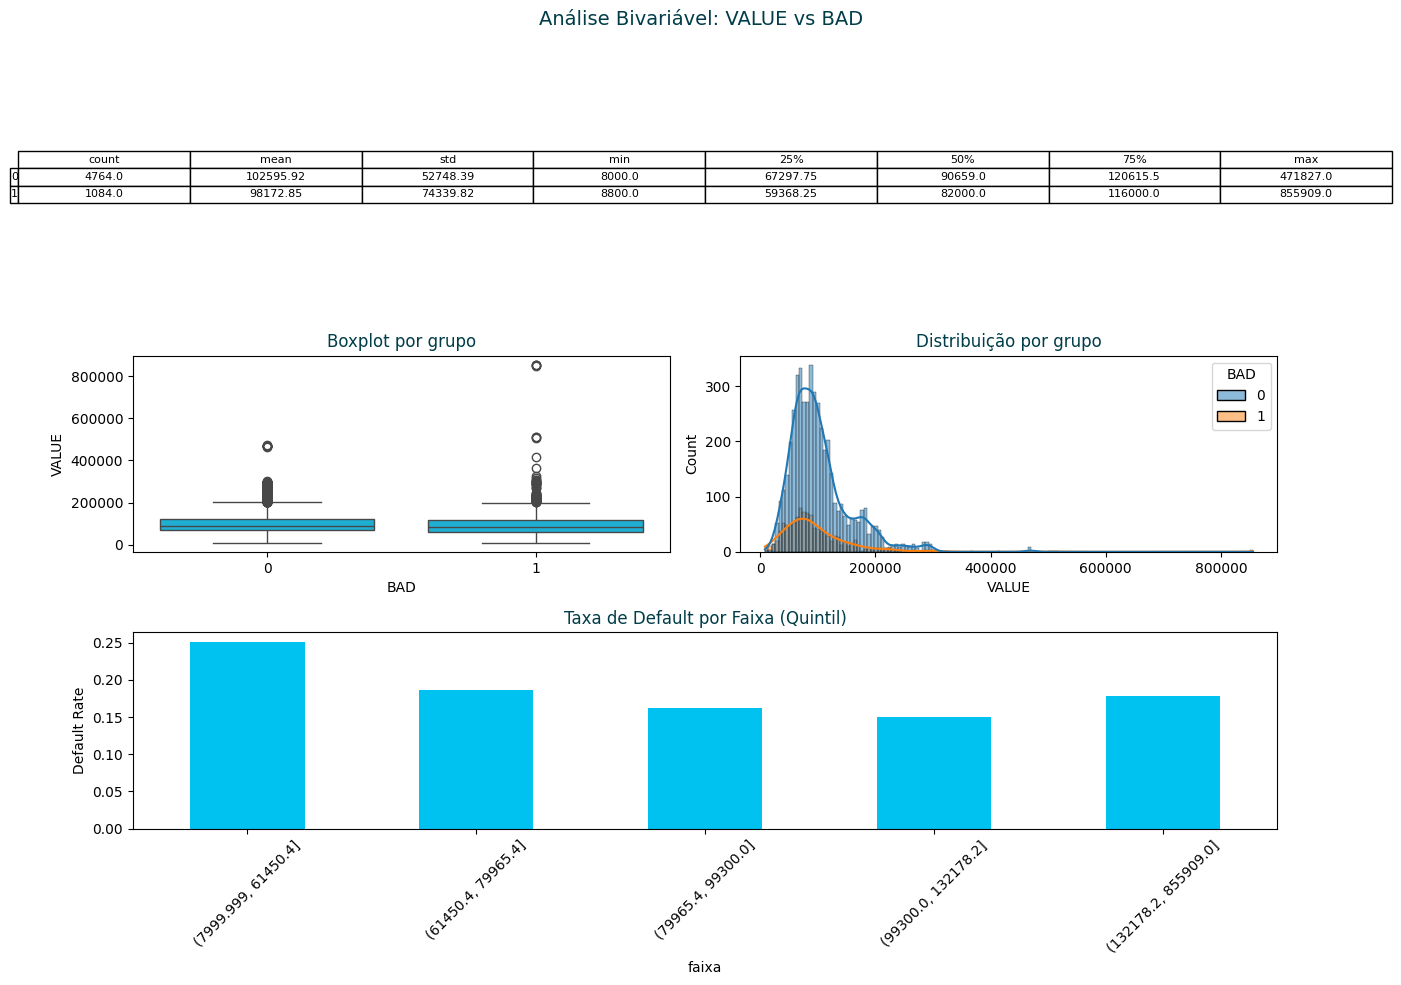

In [ ]:
bivariada_variavel_numerica_target(df, "VALUE", "BAD")

conclusão - o valor do imóvel tem influencia no default rate quando o valor é menor .

Teste de médias

- **H₀ (Hipótese nula):** Não existe diferença no valor médio do imóvel (VALUE) entre clientes inadimplentes (BAD = 1) e adimplentes (BAD = 0).

- **H₁ (Hipótese alternativa):** Existe diferença no valor médio do imóvel (VALUE) entre clientes inadimplentes (BAD = 1) e adimplentes (BAD = 0).

In [ ]:
grupo_0 = df[df["BAD"] == 0]["VALUE"].dropna()
grupo_1 = df[df["BAD"] == 1]["VALUE"].dropna()

ttest_ind(grupo_0, grupo_1)

TtestResult(statistic=np.float64(2.2912614091292616), pvalue=np.float64(0.02198370505156718), df=np.float64(5846.0))

Rejeitamos H₀. O valor do imóvel está associado ao risco de inadimplência.

Default rate por quintil

In [ ]:
temp = df[["VALUE", "BAD"]].copy()
temp["faixa"] = pd.qcut(temp["VALUE"], 5, duplicates="drop")

temp.groupby("faixa")["BAD"].mean().reset_index()

,faixa,BAD
0,"(7999.999, 61450.4]",0.251282
1,"(61450.4, 79965.4]",0.186484
2,"(79965.4, 99300.0]",0.161538
3,"(99300.0, 132178.2]",0.149701
4,"(132178.2, 855909.0]",0.177778


O risco diminui conforme o valor do imóvel aumenta.

###MORTDUE — Saldo Hipotecário

In [ ]:
var = "MORTDUE"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: MORTDUE
Quantidade de nulos: 518
% de nulos total: 8.69%
% de nulos em BAD=0: 8.64%
% de nulos em BAD=1: 8.92%


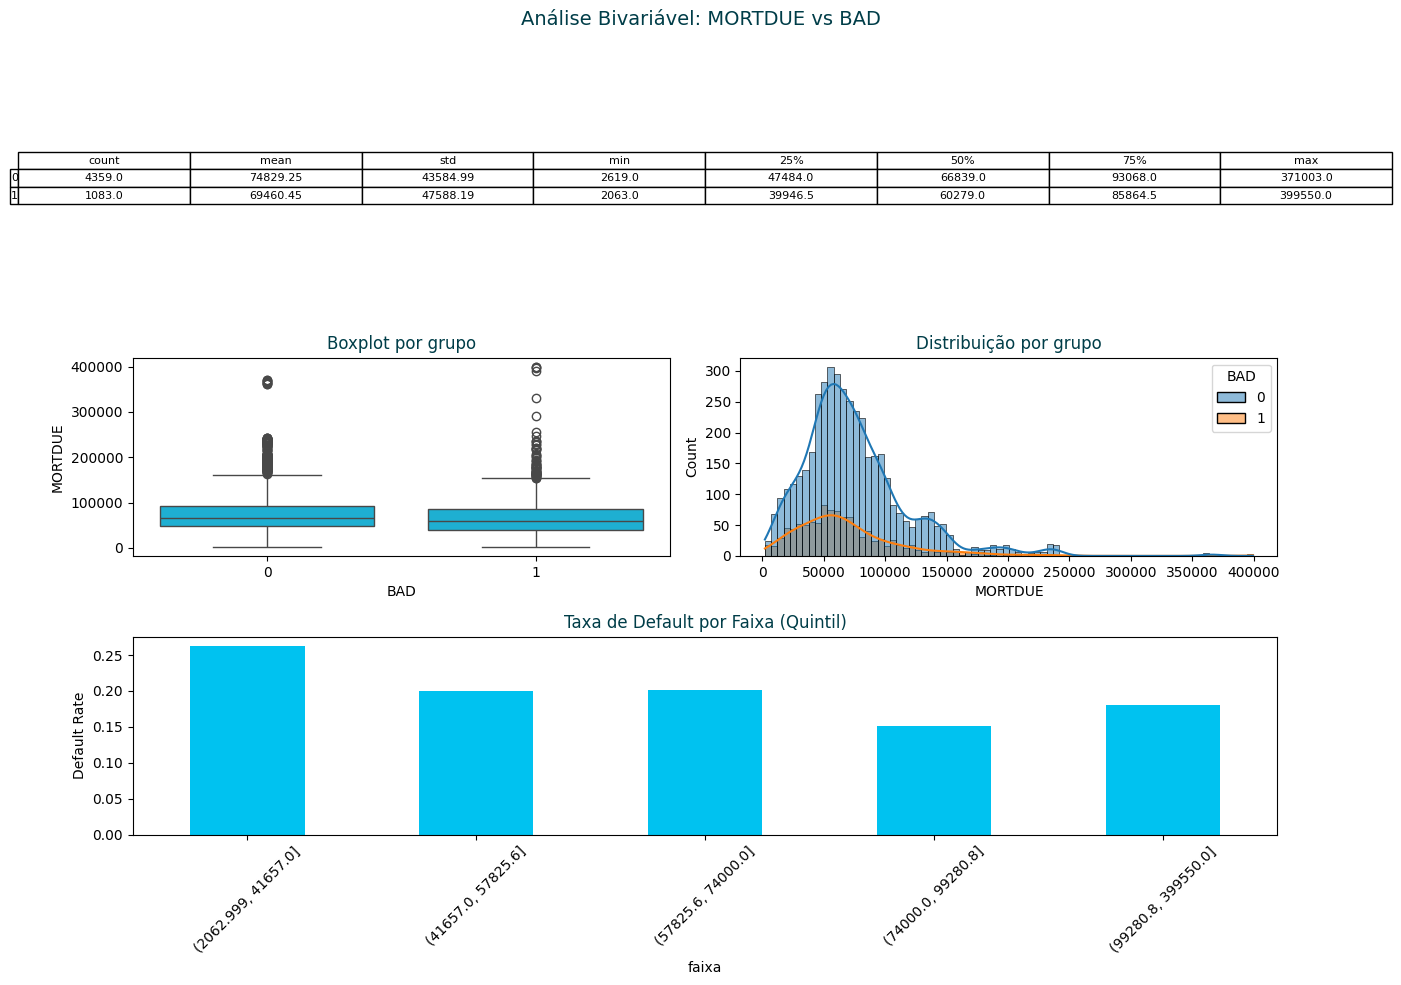

In [ ]:
bivariada_variavel_numerica_target(df, "MORTDUE", "BAD")

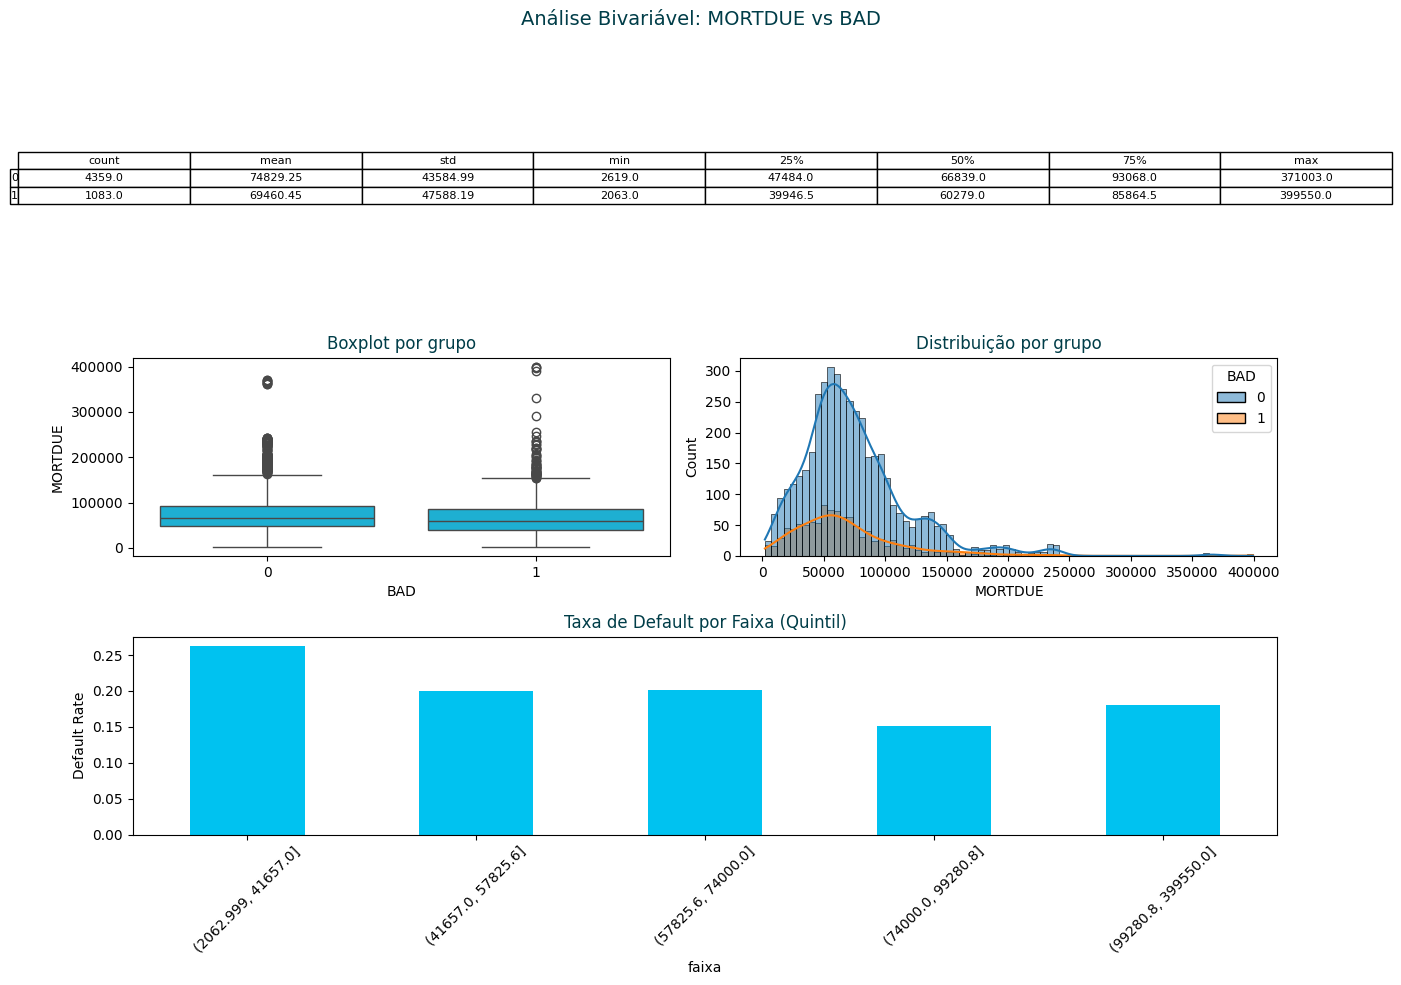

In [ ]:
bivariada_variavel_numerica_target(df, "MORTDUE", "BAD")

Teste de diferença de médias

- **H₀ (Hipótese nula):** Não existe diferença no valor médio atualmente devido em hipoteca (MORTDUE) entre clientes inadimplentes (BAD = 1) e adimplentes (BAD = 0).

- **H₁ (Hipótese alternativa):** Existe diferença no valor médio atualmente devido em hipoteca (MORTDUE) entre clientes inadimplentes (BAD = 1) e adimplentes (BAD = 0).

In [ ]:
grupo_0 = df[df["BAD"] == 0]["MORTDUE"].dropna()
grupo_1 = df[df["BAD"] == 1]["MORTDUE"].dropna()

ttest_ind(grupo_0, grupo_1)

TtestResult(statistic=np.float64(3.560612876121472), pvalue=np.float64(0.00037315277915502335), df=np.float64(5440.0))

Rejeitamos H₀. O valor atualmente devido em hipoteca está associado ao risco de inadimplência.

In [ ]:
temp = df[["MORTDUE", "BAD"]].copy()
temp["faixa"] = pd.qcut(temp["MORTDUE"], 5, duplicates="drop")

temp.groupby("faixa")["BAD"].mean().reset_index()

,faixa,BAD
0,"(2062.999, 41657.0]",0.262626
1,"(41657.0, 57825.6]",0.199449
2,"(57825.6, 74000.0]",0.200917
3,"(74000.0, 99280.8]",0.151013
4,"(99280.8, 399550.0]",0.180900


a medida que o saldo da hipoteca diminui o risco diminui tambem

Resumo da analise descritiva


###REASON - Motivo do empréstimo

In [ ]:
var = "REASON"

total = len(df)
nulos = df[var].isna().sum()
perc_total = round(nulos / total * 100, 2)

perc_bad_0 = round(df[df["BAD"] == 0][var].isna().mean() * 100, 2)
perc_bad_1 = round(df[df["BAD"] == 1][var].isna().mean() * 100, 2)

print(f"Variável: {var}")
print(f"Quantidade de nulos: {nulos}")
print(f"% de nulos total: {perc_total}%")
print(f"% de nulos em BAD=0: {perc_bad_0}%")
print(f"% de nulos em BAD=1: {perc_bad_1}%")

Variável: REASON
Quantidade de nulos: 252
% de nulos total: 4.23%
% de nulos em BAD=0: 4.28%
% de nulos em BAD=1: 4.04%


Describe da variável categórica:


,count,unique,top,freq
REASON,5708,2,DebtCon,3928


Tabela de frequência da variável categórica (com percentuais e total):


,REASON,Frequência,Percentual (%)
0,DebtCon,3928,65.91
1,HomeImp,1780,29.87
2,NaN,252,4.23
3,Total,5960,100.00


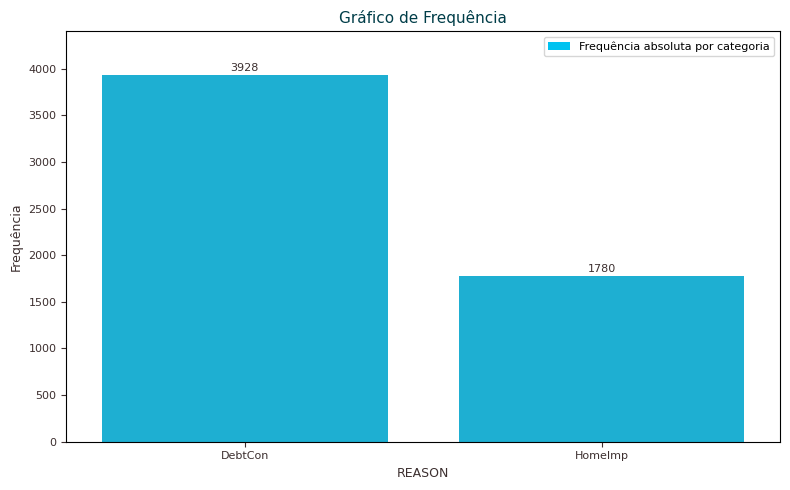

In [ ]:

univariada_variavel_categoria(df, "REASON")

Tabela Cruzada (Frequência):


BAD,0,1,All
REASON,,,
DebtCon,3183,745,3928
HomeImp,1384,396,1780
All,4567,1141,5708



Percentual de Default por Categoria (%):


BAD,0,1
REASON,,
DebtCon,81.03,18.97
HomeImp,77.75,22.25


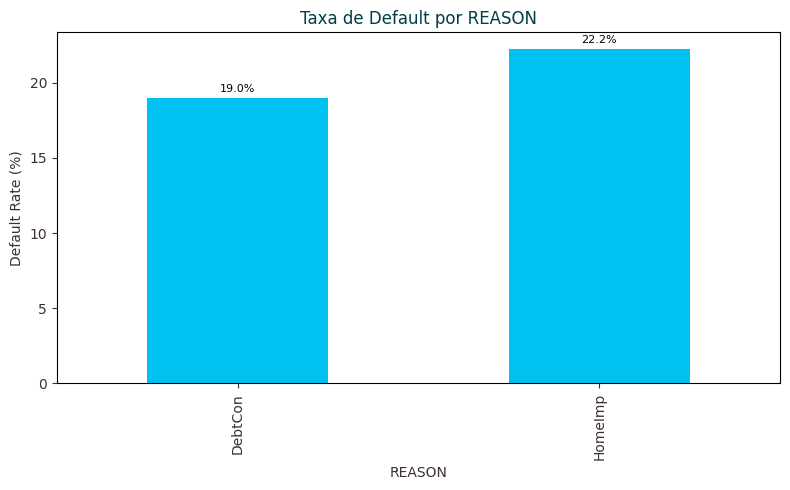

In [ ]:
bivariada_variavel_categoria_target(df, "REASON", "BAD")

#3.Relação entre variaveis

##3.1 Matriz de Correlação - variáveis numericas

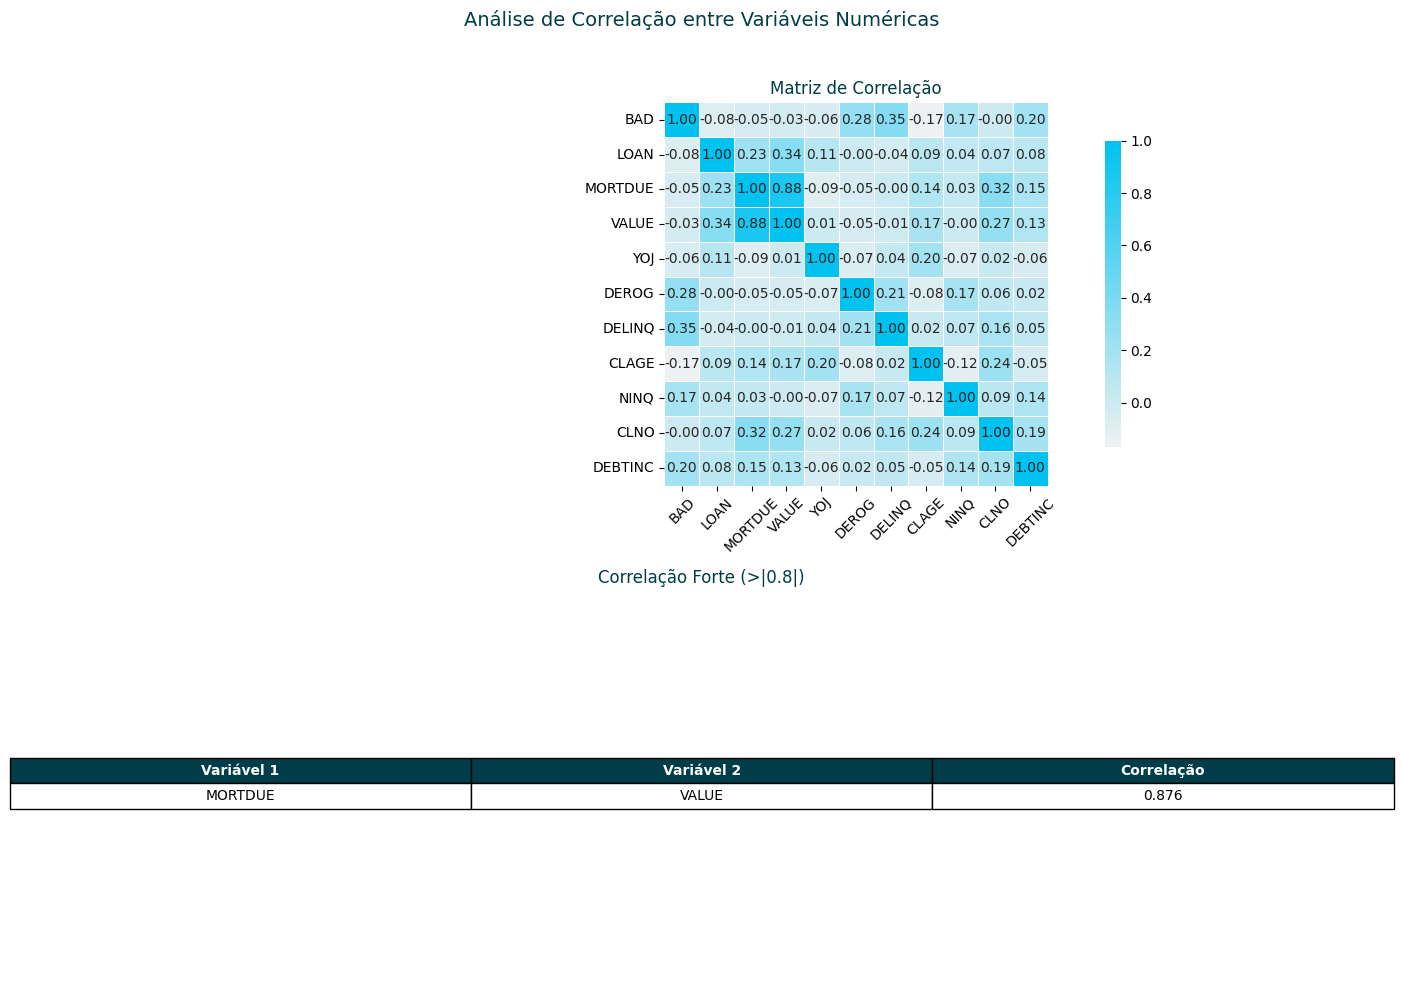

,Variável 1,Variável 2,Correlação
0,MORTDUE,VALUE,0.876


In [ ]:
analise_correlacao(df, threshold=0.8)

###i.Interpreação correlação

| Variável        | Descrição da Métrica                       | Correlação com BAD | Força Relativa               | Interpretação                                                       | Decisão para o Modelo                                   |
| --------------- | ------------------------------------------ | ------------------ | ---------------------------- | ------------------------------------------------------------------- | ------------------------------------------------------- |
| VALUE / MORTDUE | Valor atual do imóvel / saldo da hipoteca  | ≈ -0.03            | Muito Alta (entre variáveis) | Forte multicolinearidade entre valor do imóvel e dívida hipotecária | Evitar usar VALUE e MORTDUE juntos (multicolinearidade) |
| LOAN            | Valor do empréstimo solicitado             | ≈ -0.08            | Muito Baixa                  | Valor do empréstimo possui baixa relação direta com inadimplência   | Manter (variável estrutural do empréstimo)              |
| VALUE           | Valor estimado da propriedade              | ≈ -0.03            | Muito Baixa                  | Valor do imóvel não apresenta relação direta com inadimplência      | Manter apenas se relevante no modelo                    |
| MORTDUE         | Saldo atual de hipotecas                   | ≈ -0.05            | Muito Baixa                  | Saldo hipotecário isoladamente não explica inadimplência            | Manter apenas se relevante no modelo                    |
| DEBTINC         | Relação dívida / renda                     | ≈ 0.20             | Moderada                     | Maior comprometimento de renda aumenta risco de default             | Manter (indicador de capacidade de pagamento)           |
| DELINQ          | Número de linhas de crédito inadimplentes  | ≈ 0.35             | Moderada / Alta              | Histórico de inadimplência é forte indicador de risco futuro        | Manter (forte variável comportamental)                  |
| DEROG           | Número de registros negativos no histórico | ≈ 0.28             | Moderada                     | Registros negativos no histórico aumentam risco de default          | Manter (histórico negativo relevante)                   |
| NINQ            | Número de consultas recentes de crédito    | ≈ 0.17             | Moderada                     | Muitas consultas recentes podem indicar pressão por crédito         | Manter (indicador de pressão de crédito)                |
| CLAGE           | Idade da linha de crédito mais antiga      | ≈ -0.17            | Moderada (negativa)          | Histórico de crédito mais longo tende a reduzir risco               | Manter (proxy de estabilidade financeira)               |
| CLNO            | Número total de linhas de crédito          | ≈ 0.00             | Muito Baixa                  | Quantidade de linhas de crédito não explica default                 | Manter (informação estrutural do cliente)               |
| YOJ             | Anos no emprego atual                      | ≈ -0.06            | Muito Baixa                  | Tempo no emprego tem baixa relação com inadimplência                | Manter (indicador de estabilidade profissional)         |


##3.2 Análise de Associação - variáveis categóricas


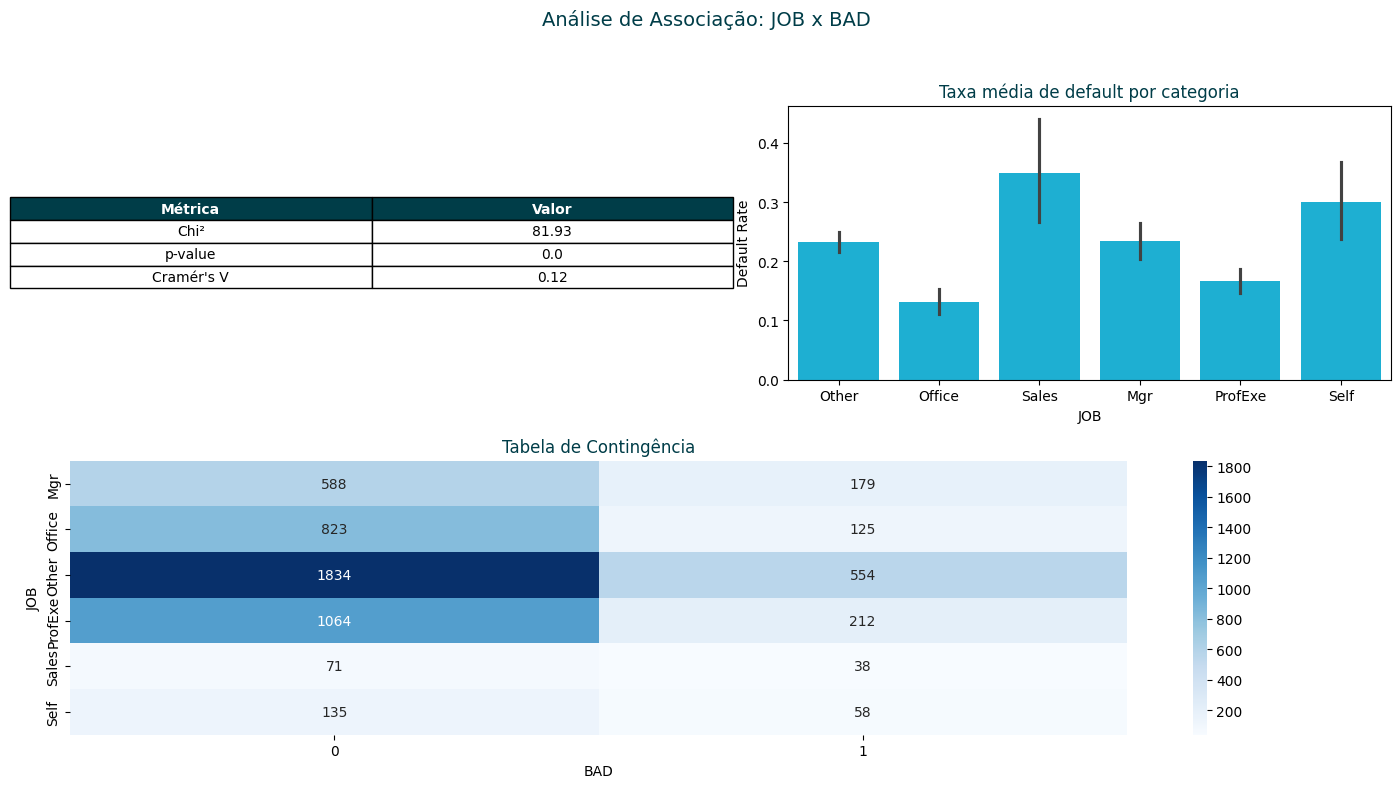

,Métrica,Valor
0,Chi²,81.93
1,p-value,0.00
2,Cramér's V,0.12


In [ ]:
analise_associacao_categorica(df, "JOB")

| Métrica             | Resultado | Interpretação                                                                                            |
| ------------------- | --------- | -------------------------------------------------------------------------------------------------------- |
| Qui-quadrado (Chi²) | 81.93     | Existe associação estatisticamente significativa entre a ocupação do cliente (JOB) e o evento de default |
| p-value             | 0.00      | A hipótese de independência entre JOB e inadimplência é rejeitada                                        |
| Cramér’s V          | 0.12      | Associação fraca a moderada entre ocupação e risco de inadimplência                                      |


| Categoria JOB | Interpretação de Risco                                                  |
| ------------- | ----------------------------------------------------------------------- |
| Sales         | Apresenta a maior taxa média de default, indicando maior risco relativo |
| Self          | Taxa de default elevada, sugerindo maior volatilidade de renda          |
| Other         | Risco intermediário de inadimplência                                    |
| Manager (Mgr) | Risco moderado, próximo da média da base                                |
| ProfExe       | Taxa de default relativamente menor                                     |
| Office        | Menor taxa média de default entre as categorias                         |



| Insight                                                | Implicação para Modelagem                                                     |
| ------------------------------------------------------ | ----------------------------------------------------------------------------- |
| Existe associação estatística entre ocupação e default | A variável **JOB deve ser considerada no modelo**                             |
| Diferenças de risco entre categorias ocupacionais      | Pode ser útil aplicar **codificação de risco (WOE ou target encoding)**       |
| Associação moderada                                    | Variável útil como **complemento às variáveis financeiras e comportamentais** |


#4.Modelagem Preditiva de Risco de Crédito

##4.1 Preparação dos dados

###4.1.1.Identificação de inconsistências

####. LOAN maior que VALUE

In [ ]:
(df["LOAN"] > df["VALUE"]).sum()

np.int64(12)

In [ ]:
df[df["LOAN"] > df["VALUE"]]

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
3538,0,18600,57300.0,8000.0,DebtCon,Other,6.0,NaN,NaN,68.000000,1.0,17.0,NaN
3655,0,19200,65206.0,13933.0,DebtCon,Other,7.0,NaN,NaN,57.591831,0.0,16.0,42.502435
3683,0,19400,63508.0,12414.0,DebtCon,Other,5.0,NaN,NaN,64.407605,1.0,16.0,40.570169
3707,0,19500,58638.0,13930.0,DebtCon,Other,4.0,NaN,NaN,69.005027,0.0,16.0,42.500025
3739,0,19800,63701.0,14609.0,DebtCon,Other,4.0,NaN,NaN,62.359738,1.0,17.0,41.874198
3757,0,20000,59936.0,12737.0,DebtCon,Other,5.0,NaN,NaN,63.395400,0.0,17.0,40.446579
4155,0,21700,60792.0,14580.0,DebtCon,Other,5.0,NaN,NaN,62.856357,1.0,17.0,40.315819
4225,1,22000,82000.0,12500.0,DebtCon,ProfExe,3.0,0.0,0.0,117.766667,6.0,23.0,NaN
5777,1,46300,39800.0,41600.0,DebtCon,Other,NaN,0.0,0.0,111.600000,1.0,3.0,NaN
5948,0,86000,47355.0,85000.0,DebtCon,Other,15.0,0.0,0.0,210.966667,0.0,16.0,NaN


#####.Histograma de Loan

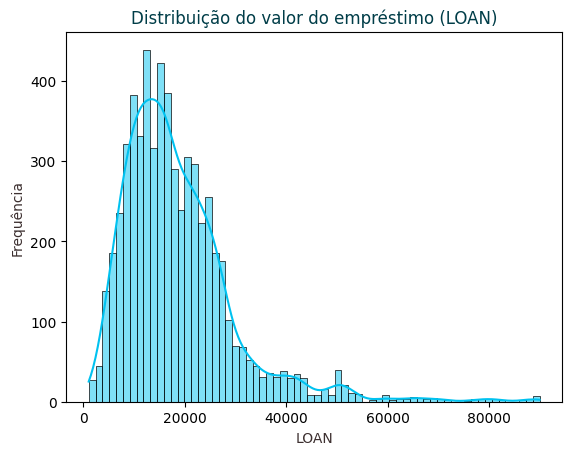

In [ ]:
sns.histplot(
data=df,
x="LOAN",
kde=True,
ax=plt.gca(),
color=COLOR_BLUE
)

plt.title("Distribuição do valor do empréstimo (LOAN)", color=COLOR_TITLE)
plt.xlabel("LOAN", color=COLOR_DARK)
plt.ylabel("Frequência", color=COLOR_DARK)

plt.show()

#####.Histograma de Value

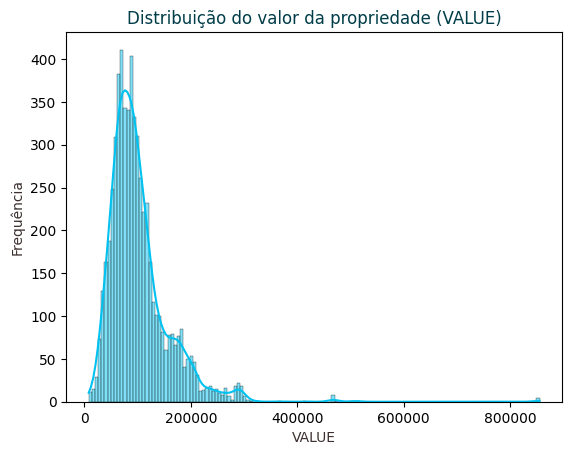

In [ ]:
sns.histplot(
data=df,
x="VALUE",
kde=True,
ax=plt.gca(),
color=COLOR_BLUE
)

plt.title("Distribuição do valor da propriedade (VALUE)", color=COLOR_TITLE)
plt.xlabel("VALUE", color=COLOR_DARK)
plt.ylabel("Frequência", color=COLOR_DARK)

plt.show()

###.Sugestão -Tratamento de inconsistência LOAN vs VALUE



Foram identificadas 12 observações (≈0,2% da base) em que LOAN > VALUE, implicando LTV > 100%. Em operações de crédito com garantia imobiliária, essa situação é economicamente inconsistente e provavelmente representa outliers ou erros de registro.

Essas observações devem ser removidas porque:

removem inconsistência econômica nos dados

melhoram a estabilidade do modelo

representam uma fração muito pequena da base

##.MORTDUE maior que VALUE

In [ ]:
(df["MORTDUE"] > df["VALUE"]).sum()

np.int64(51)

In [ ]:
df[df["MORTDUE"] > df["VALUE"]]

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
50,1,3100,39589.0,36100.0,HomeImp,Other,1.5,0.0,0.0,153.166667,1.0,14.0,NaN
94,0,4000,64240.0,63990.0,HomeImp,Sales,5.0,2.0,0.0,160.300000,1.0,23.0,NaN
136,1,4900,25597.0,23031.0,HomeImp,Other,5.0,0.0,0.0,101.746766,0.0,8.0,33.243157
184,1,5000,40000.0,32480.0,HomeImp,Other,8.0,3.0,2.0,163.366667,1.0,16.0,NaN
216,1,5200,40564.0,39527.0,HomeImp,Other,0.0,0.0,0.0,157.771036,1.0,13.0,72.670433
218,0,5300,66987.0,65111.0,HomeImp,Sales,4.0,1.0,0.0,175.328704,1.0,22.0,40.442570
252,0,5500,72147.0,69918.0,HomeImp,Sales,4.0,2.0,0.0,158.534498,0.0,23.0,43.404430
339,0,6100,68743.0,65321.0,HomeImp,Sales,3.0,1.0,0.0,153.066783,0.0,22.0,40.150527
457,0,6900,53776.0,51952.0,HomeImp,Other,5.0,0.0,0.0,87.900118,0.0,17.0,22.286997


###.Sugestão - Tratamento de inconsistência MORTDUE vs VALUE

Tratamento de inconsistência MORTDUE vs VALUE

Foram identificadas 43 observações (≈0,7% da base) em que MORTDUE > VALUE, implicando Mortgage LTV superior a 100%. Esses casos apresentam taxa de default significativamente maior, indicando possível sinal de risco.

Entretanto, alguns valores de MORT_LTV são extremamente altos (até ~6), sugerindo outliers ou inconsistências de registro. Para preservar o sinal de risco e reduzir distorções na modelagem, os valores extremos foram truncados.

In [ ]:
#df_clean["MORT_LTV"] = df_clean["MORT_LTV"].clip(upper=1)

##.DELINQ maior que CLNO

In [ ]:
(df["DELINQ"] > df["CLNO"]).sum()

np.int64(1)

###.Sugestão - Tratamento de inconsistência DELINQ vs CLNO

Foi identificada 1 observação em que DELINQ > CLNO. Como DELINQ representa o número de atrasos e CLNO o número de linhas de crédito, essa situação é logicamente inconsistente, pois o número de atrasos não pode exceder o número de contas existentes.

Por se tratar de um caso isolado e provavelmente decorrente de erro de registro ou inconsistência de dados, a observação foi removida da base para manter a coerência lógica do dataset.

In [ ]:
#df_clean = df_clean[df_clean["DELINQ"] <= df_clean["CLNO"]]

###4.1.2.Detecção de outliers (IQR)

In [ ]:
outlier_report = []

for col in df.select_dtypes(include=["float64", "int64"]).columns:

  data = df[col].dropna()

  Q1 = data.quantile(0.25)
  Q3 = data.quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = ((data < lower) | (data > upper)).sum()

  outlier_report.append({
    "variavel": col,
    "outliers": outliers,
    "percentual_outliers": round(outliers / len(df) * 100, 2),
    "limite_inferior": round(lower, 2),
    "limite_superior": round(upper, 2),
    "media": round(data.mean(), 2),
    "mediana": round(data.median(), 2),
    "min": round(data.min(), 2),
    "max": round(data.max(), 2)
  })

  outlier_report_df = pd.DataFrame(outlier_report)
  outlier_report_df.sort_values("outliers", ascending=False)

In [ ]:
outlier_report_df.sort_values("percentual_outliers", ascending=False)

,variavel,outliers,percentual_outliers,limite_inferior,limite_superior,media,mediana,min,max
6,DELINQ,1201,20.15,0.00,0.00,0.45,0.00,0.00,15.00
0,BAD,1189,19.95,0.00,0.00,0.20,0.00,0.00,1.00
5,DEROG,725,12.16,0.00,0.00,0.25,0.00,0.00,10.00
3,VALUE,320,5.37,-14547.62,200447.38,101776.05,89235.50,8000.00,855909.00
1,LOAN,256,4.30,-7200.00,41600.00,18607.97,16300.00,1100.00,89900.00
2,MORTDUE,234,3.93,-21542.00,159306.00,73760.82,65019.00,2063.00,399550.00
9,CLNO,219,3.67,-1.50,42.50,21.30,20.00,0.00,71.00
8,NINQ,177,2.97,-3.00,5.00,1.19,1.00,0.00,17.00
10,DEBTINC,94,1.58,14.35,53.80,33.78,34.82,0.52,203.31
4,YOJ,91,1.53,-12.00,28.00,8.92,7.00,0.00,41.00


####Sugestão - Tratamento de outliers

A detecção de valores extremos foi inicialmente analisada utilizando o método IQR para identificar possíveis outliers. No entanto, em datasets de crédito, muitos valores identificados como outliers representam comportamento real dos clientes e não necessariamente erros de dados. Por esse motivo, o tratamento foi definido considerando a natureza de cada variável.

As variáveis devem ser tratadas da seguinte forma:

Variáveis de contagem (DELINQ, DEROG, NINQ, CLNO) foram mantidas sem tratamento, pois valores elevados representam comportamento real de risco de crédito e não erros de registro.

Variáveis financeiras (LOAN, VALUE, MORTDUE) apresentam distribuição altamente assimétrica com cauda longa. Para reduzir a assimetria e melhorar a estabilidade dos modelos, foi aplicada transformação logarítmica (log1p).

Variáveis de razão e comportamento (DEBTINC, CLAGE, YOJ, LTV, MORT_LTV) tiveram valores extremos limitados utilizando percentile capping entre o 1º e o 99º percentil, reduzindo a influência de valores extremos sem remover observações.

Adicionalmente, a variável LTV foi segmentada em faixas (low, medium, high, very_high) utilizando binning, com o objetivo de melhorar a interpretabilidade e capturar possíveis relações não lineares com o risco de default.

###4.1.3.Feature Engineering

####.Variáveis com alta concentração em zero

In [ ]:
for col in ["DELINQ", "DEROG", "NINQ"]:

    perc_zero = (df[col] == 0).mean()

    print(f"{col}: {round(perc_zero*100,2)}% dos valores são zero")

DELINQ: 70.12% dos valores são zero
DEROG: 75.96% dos valores são zero
NINQ: 42.47% dos valores são zero


####.Criação LTV

In [ ]:

df["LTV"] = df["LOAN"] / df["VALUE"]

df["LTV"].describe()

,LTV
count,5848.000000
mean,0.216597
std,0.165112
min,0.015179
25%,0.122324
50%,0.170527
75%,0.245009
max,2.325000


#####.Histograma LTV

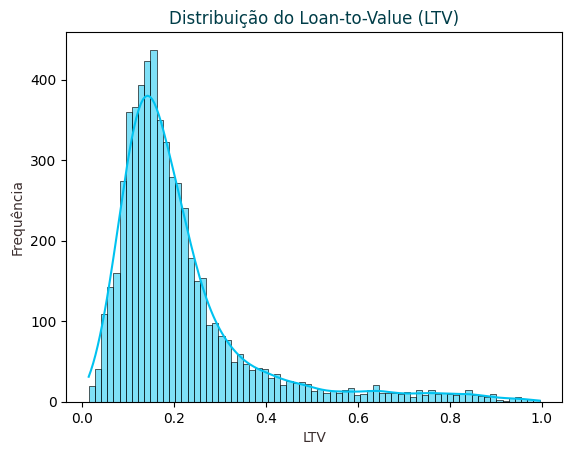

In [ ]:
sns.histplot(
data=df[df["LTV"] < 1],
x="LTV",
kde=True,
ax=plt.gca(),
color=COLOR_BLUE
)

plt.title("Distribuição do Loan-to-Value (LTV)", color=COLOR_TITLE)
plt.xlabel("LTV", color=COLOR_DARK)
plt.ylabel("Frequência", color=COLOR_DARK)

plt.show()

####.Criação MORT_LTV

In [ ]:
df["MORT_LTV"] = df["MORTDUE"] / df["VALUE"]
df["MORT_LTV"].describe()

,MORT_LTV
count,5357.000000
mean,0.708494
std,0.381115
min,0.020538
25%,0.623000
50%,0.718861
75%,0.795614
max,7.162500


#####.Histograma MORT_LTV

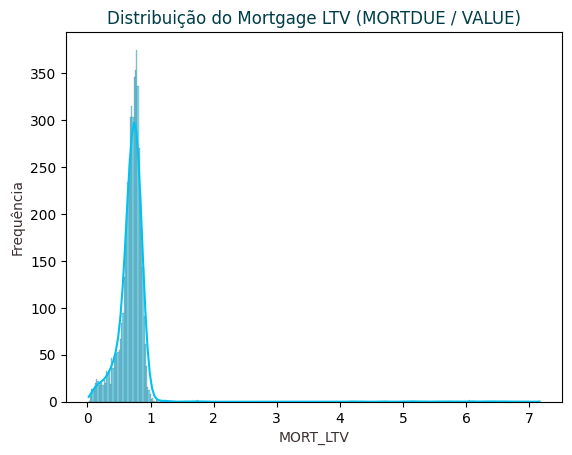

In [ ]:
sns.histplot(
data=df,
x="MORT_LTV",
kde=True,
color=COLOR_BLUE
)

plt.title("Distribuição do Mortgage LTV (MORTDUE / VALUE)", color=COLOR_TITLE)
plt.xlabel("MORT_LTV", color=COLOR_DARK)
plt.ylabel("Frequência", color=COLOR_DARK)

plt.show()

####.Criação - Binário Histórico de atraso

In [ ]:
df["has_delinquency"] = (df["DELINQ"] > 0).astype(int)

####.Criação - Binário Histórico negativo no crédito

In [ ]:
df["has_derog"] = (df["DEROG"] > 0).astype(int)

####.Criação Binário - Consultas recentes de crédito

In [ ]:
df["has_inquiry"] = (df["NINQ"] > 0).astype(int)

####.Criação Binário - Alto comprometimento da renda

In [ ]:
df["high_debtinc"] = (df["DEBTINC"] > 35).astype(int)

high_debtinc -> o risco ficou menor, o que é contraintuitivo.
O resultado pode estar relacionado à presença de valores faltantes ou à distribuição específica da base. Por esse motivo, essa variável será mantida para testes posteriores, mas não será considerada como um forte indicador isolado de risco

####.Criação Binário - Alto LTV

In [ ]:
df["high_ltv"] = (df["LTV"] > 0.8).astype(int)

####.Criação Binário - double risk

In [ ]:
df["double_risk"] = (
    (df["high_ltv"] == 1) &
    (df["high_debtinc"] == 1)
).astype(int)

####.Criação LTV LOAN VALUE

In [ ]:
df['LTV_LOAN_VALUE'] = df['LOAN'] / df['VALUE']

####.Criação TOTAL LTV

In [ ]:
df['TOTAL_LTV'] = (df['LOAN'] + df['MORTDUE']) / df['VALUE']

####.Criação LOAN DEBTINC

In [ ]:
df['LOAN_DEBTINC'] = df['LOAN'] * df['DEBTINC']

####.Criação MORT DEBTINC

In [ ]:
df['MORT_DEBTINC'] = df['MORTDUE'] * df['DEBTINC']

####.Criação VALUE DEBTINC

In [ ]:
df['VALUE_DEBTINC'] = df['VALUE'] * df['DEBTINC']

####.Criação DELINQ RATIO

In [ ]:
df["DELINQ_RATIO"] = df["DELINQ"] / df["CLNO"].replace(0, np.nan)

####.Criação DEROG RATIO

In [ ]:
df["DEROG_RATIO"] = df["DEROG"] / df["CLNO"].replace(0, np.nan)

####.Criação CREDIT ACTIVITY

In [ ]:
df["CREDIT_ACTIVITY"] = df["NINQ"] / df["CLNO"].replace(0, np.nan)

####.Criação CREDIT_LINES_PER_YEAR

In [ ]:

df["CREDIT_LINES_PER_YEAR"] = df["CLNO"] / df["YOJ"].replace(0, np.nan)

####.Criação TENURE RATIO

In [ ]:

df["TENURE_RATIO"] = df["YOJ"] / df["CLAGE"].replace(0, np.nan)

####.Criação LOAN PER LINE

In [ ]:
df['LOAN_PER_LINE'] = df['LOAN'] / df['CLNO'].replace(0, np.nan)

####.Criação MORT PER LINE

In [ ]:
df['MORT_PER_LINE'] = df['MORTDUE'] / df['CLNO'].replace(0, np.nan)


####.Criação VALUE PER LINE

In [ ]:
df['VALUE_PER_LINE'] = df['VALUE'] / df['CLNO'].replace(0, np.nan)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,1.994966e-01,3.996555e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
LOAN,5960.0,1.860797e+04,1.120748e+04,1100.000000,1.110000e+04,1.630000e+04,2.330000e+04,8.990000e+04
MORTDUE,5442.0,7.376082e+04,4.445761e+04,2063.000000,4.627600e+04,6.501900e+04,9.148800e+04,3.995500e+05
VALUE,5848.0,1.017760e+05,5.738578e+04,8000.000000,6.607550e+04,8.923550e+04,1.198242e+05,8.559090e+05
YOJ,5445.0,8.922268e+00,7.573982e+00,0.000000,3.000000e+00,7.000000e+00,1.300000e+01,4.100000e+01
DEROG,5252.0,2.545697e-01,8.460468e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+01
DELINQ,5380.0,4.494424e-01,1.127266e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01
CLAGE,5652.0,1.797663e+02,8.581009e+01,0.000000,1.151167e+02,1.734667e+02,2.315623e+02,1.168234e+03
NINQ,5450.0,1.186055e+00,1.728675e+00,0.000000,0.000000e+00,1.000000e+00,2.000000e+00,1.700000e+01
CLNO,5738.0,2.129610e+01,1.013893e+01,0.000000,1.500000e+01,2.000000e+01,2.600000e+01,7.100000e+01


###4.1.4. Avaliação das Features vs BAD

In [ ]:
risk_features = [

    # flags criadas
    "has_delinquency",
    "has_derog",
    "has_inquiry",
    "high_debtinc",
    "high_ltv",
    "double_risk",

    # métricas derivadas importantes
    "DELINQ_RATIO",
    "CREDIT_ACTIVITY",
    "LTV",
    "MORT_LTV",
    "TOTAL_LTV",
    "LOAN_DEBTINC",
    "MORT_DEBTINC"

]


summary = []

for col in risk_features:

    temp = df[[col, "BAD"]].copy()

    # remover inf
    temp = temp.replace([np.inf, -np.inf], np.nan)

    # remover missing
    temp = temp.dropna()

    if temp[col].nunique() > 2:

        try:

            temp["bin"] = pd.qcut(
                temp[col],
                q=4,
                duplicates="drop"
            )

            risk = temp.groupby("bin")["BAD"].mean()

        except:
            risk = temp.groupby(col)["BAD"].mean()

    else:

        risk = temp.groupby(col)["BAD"].mean()

    diff = risk.max() - risk.min()

    summary.append({

        "feature": col,
        "min_default_rate": risk.min(),
        "max_default_rate": risk.max(),
        "risk_difference": diff

    })


summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(
    "risk_difference",
    ascending=False
)

summary_df

,feature,min_default_rate,max_default_rate,risk_difference
1,has_derog,0.160649,0.480000,0.319351
0,has_delinquency,0.137634,0.444629,0.306996
5,double_risk,0.026316,0.200608,0.174292
7,CREDIT_ACTIVITY,0.150964,0.308633,0.157668
3,high_debtinc,0.116572,0.251571,0.134998
2,has_inquiry,0.154883,0.245975,0.091091
10,TOTAL_LTV,0.140403,0.217326,0.076923
8,LTV,0.160055,0.206566,0.046512
4,high_ltv,0.158416,0.200205,0.041789
11,LOAN_DEBTINC,0.063939,0.100597,0.036658


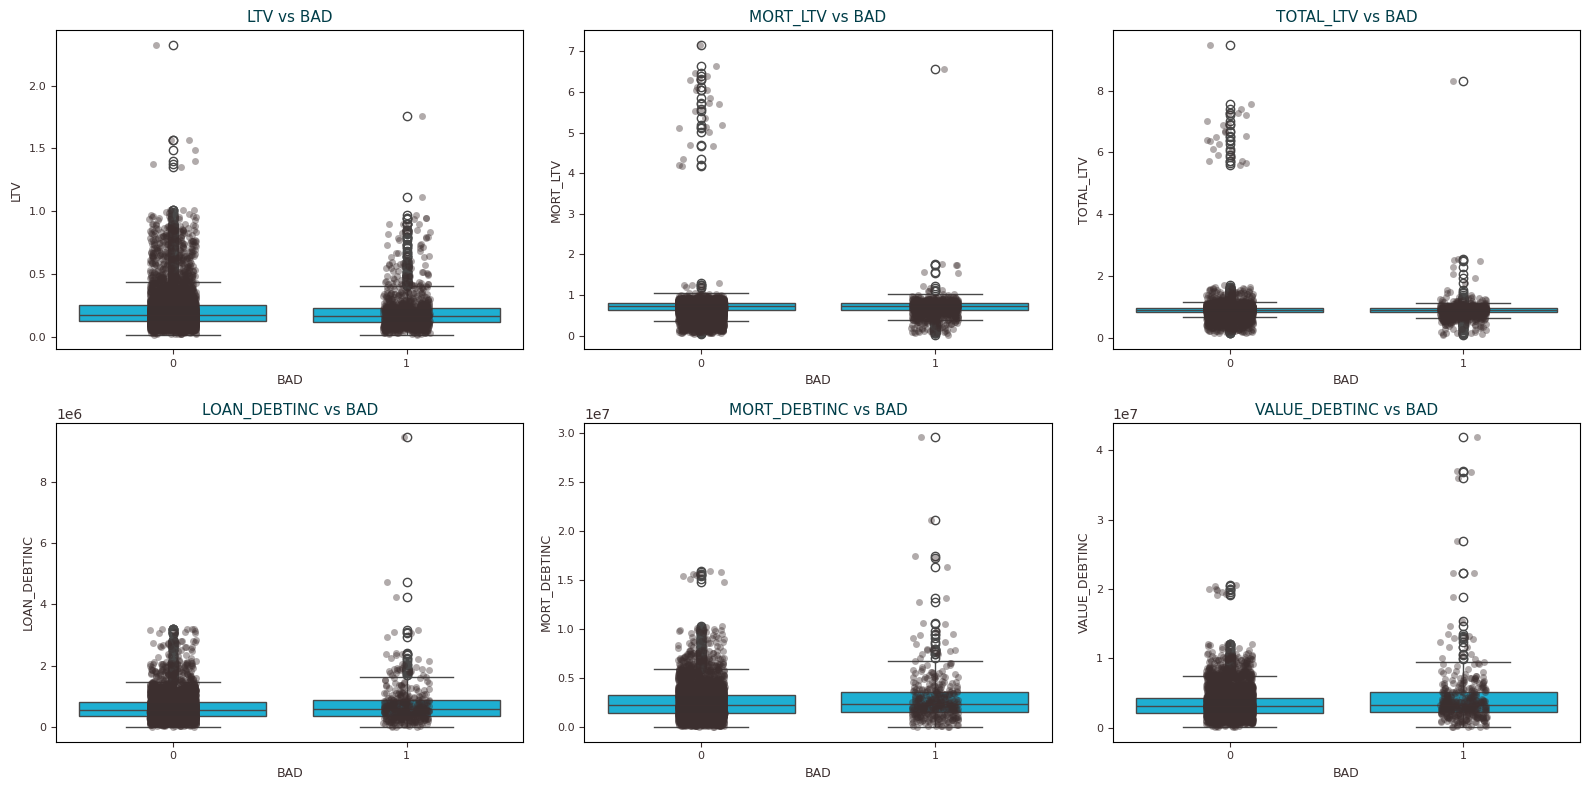

In [ ]:
continuous_features = [

    # métricas estruturais
    "LTV",
    "MORT_LTV",
    "TOTAL_LTV",

    # métricas financeiras
    "LOAN_DEBTINC",
    "MORT_DEBTINC",
    "VALUE_DEBTINC",

    # intensidade de crédito
    "DELINQ_RATIO",
    "DEROG_RATIO",
    "CREDIT_ACTIVITY",

    # comportamento de crédito
    "CREDIT_LINES_PER_YEAR",
    "TENURE_RATIO",

    # métricas por linha
    "LOAN_PER_LINE",
    "MORT_PER_LINE",
    "VALUE_PER_LINE"
]

fig, axes = plt.subplots(2, 3, figsize=(16,8))

for i, col in enumerate(continuous_features[:6]):

    ax = axes[i//3, i%3]

    sns.boxplot(
        data=df,
        x="BAD",
        y=col,
        ax=ax,
        color=COLOR_BLUE
    )

    sns.stripplot(
        data=df,
        x="BAD",
        y=col,
        ax=ax,
        color=COLOR_DARK,
        alpha=0.4,
        jitter=True
    )

    ax.set_title(f"{col} vs BAD", fontsize=11, color=COLOR_TITLE)
    ax.set_xlabel("BAD", fontsize=9, color=COLOR_DARK)
    ax.set_ylabel(col, fontsize=9, color=COLOR_DARK)

    ax.tick_params(colors=COLOR_DARK, labelsize=8)

plt.tight_layout()
plt.show()


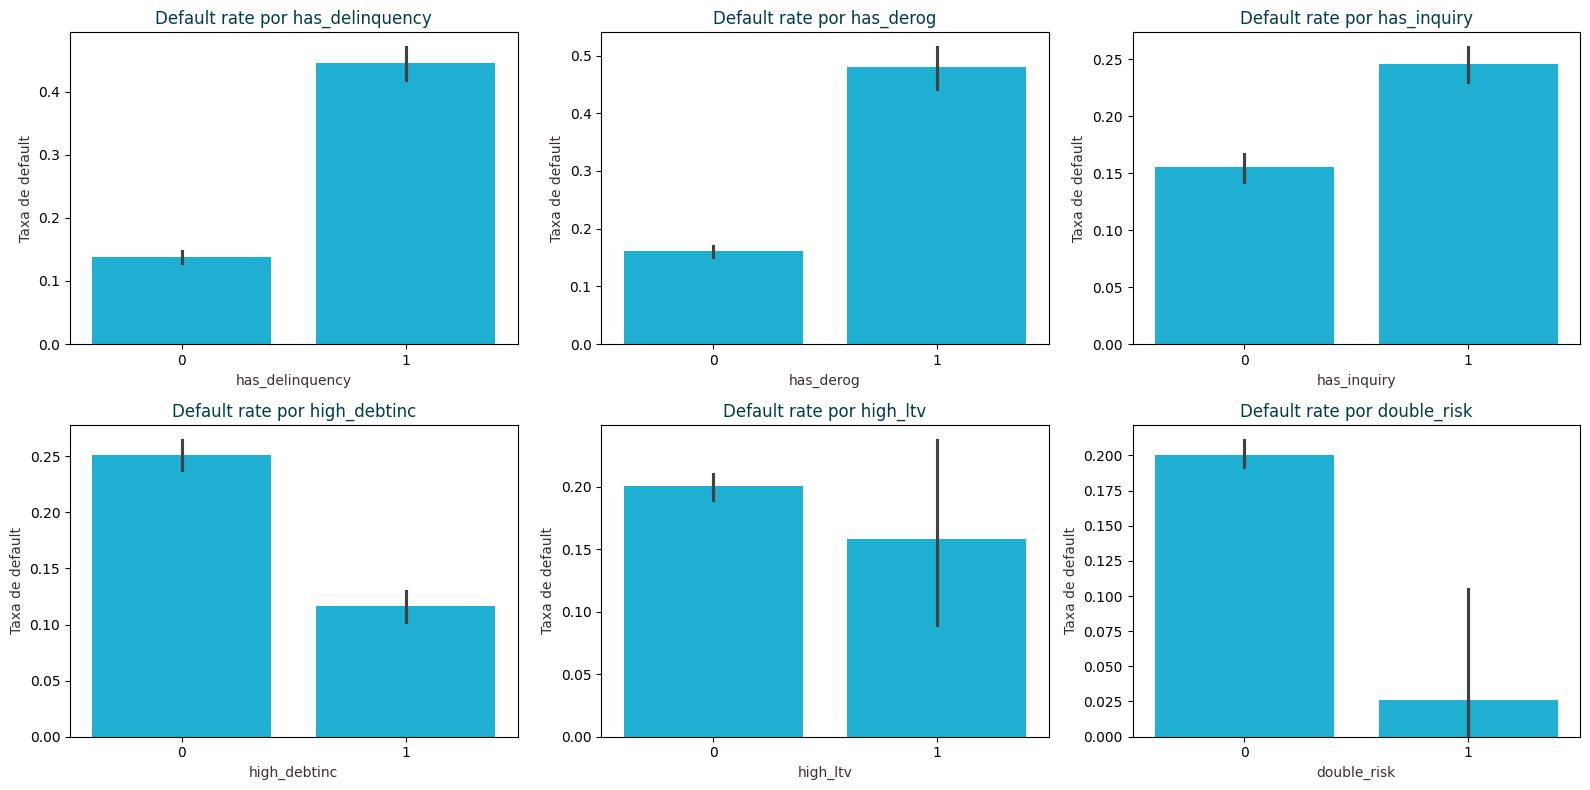

In [ ]:
risk_features = [

    "has_delinquency",
    "has_derog",
    "has_inquiry",
    "high_debtinc",
    "high_ltv",
    "double_risk"

]

import math

n = len(risk_features)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))

axes = axes.flatten()

for i, col in enumerate(risk_features):

    ax = axes[i]

    sns.barplot(
        data=df,
        x=col,
        y="BAD",
        color=COLOR_BLUE,
        ax=ax
    )

    ax.set_title(f"Default rate por {col}", color=COLOR_TITLE)
    ax.set_xlabel(col, color=COLOR_DARK)
    ax.set_ylabel("Taxa de default", color=COLOR_DARK)

# remover eixos vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
risk_summary = []

for col in risk_features:

    rate = df.groupby(col)["BAD"].mean()

    risk_summary.append({
        "feature": col,
        "default_rate_0": rate.loc[0],
        "default_rate_1": rate.loc[1],
        "risk_difference": rate.loc[1] - rate.loc[0]
    })

pd.DataFrame(risk_summary).sort_values("risk_difference", ascending=False)

,feature,default_rate_0,default_rate_1,risk_difference
1,has_derog,0.160649,0.480000,0.319351
0,has_delinquency,0.137634,0.444629,0.306996
2,has_inquiry,0.154883,0.245975,0.091091
4,high_ltv,0.200205,0.158416,-0.041789
3,high_debtinc,0.251571,0.116572,-0.134998
5,double_risk,0.200608,0.026316,-0.174292


###4.1.5. Identificação Nulos

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": df.isnull().mean()
}).sort_values("missing_pct", ascending=False)
missing_summary

,missing_count,missing_pct
MORT_DEBTINC,1669,0.280034
VALUE_DEBTINC,1298,0.217785
DEBTINC,1267,0.212584
LOAN_DEBTINC,1267,0.212584
CREDIT_LINES_PER_YEAR,1021,0.171309
DEROG_RATIO,770,0.129195
DEROG,708,0.118792
MORT_PER_LINE,698,0.117114
TENURE_RATIO,691,0.115940
DELINQ_RATIO,642,0.107718


In [ ]:
missing_by_target = df.groupby("BAD").apply(lambda x: x.isnull().mean())

missing_by_target = missing_by_target.T

missing_by_target.columns = ["BAD = 0", "BAD = 1"]

missing_by_target["diferença"] = (
    missing_by_target["BAD = 1"] - missing_by_target["BAD = 0"]
)

missing_by_target.sort_values("diferença", ascending=False)

,BAD = 0,BAD = 1,diferença
VALUE_DEBTINC,0.102075,0.682086,0.580011
DEBTINC,0.100817,0.661060,0.560242
LOAN_DEBTINC,0.100817,0.661060,0.560242
MORT_DEBTINC,0.178369,0.687973,0.509604
VALUE_PER_LINE,0.043178,0.143818,0.100641
VALUE,0.001467,0.088310,0.086842
LTV,0.001467,0.088310,0.086842
LTV_LOAN_VALUE,0.001467,0.088310,0.086842
TOTAL_LTV,0.086355,0.160639,0.074284
MORT_LTV,0.086355,0.160639,0.074284


####.Percentual de valores nulos por variável e por target

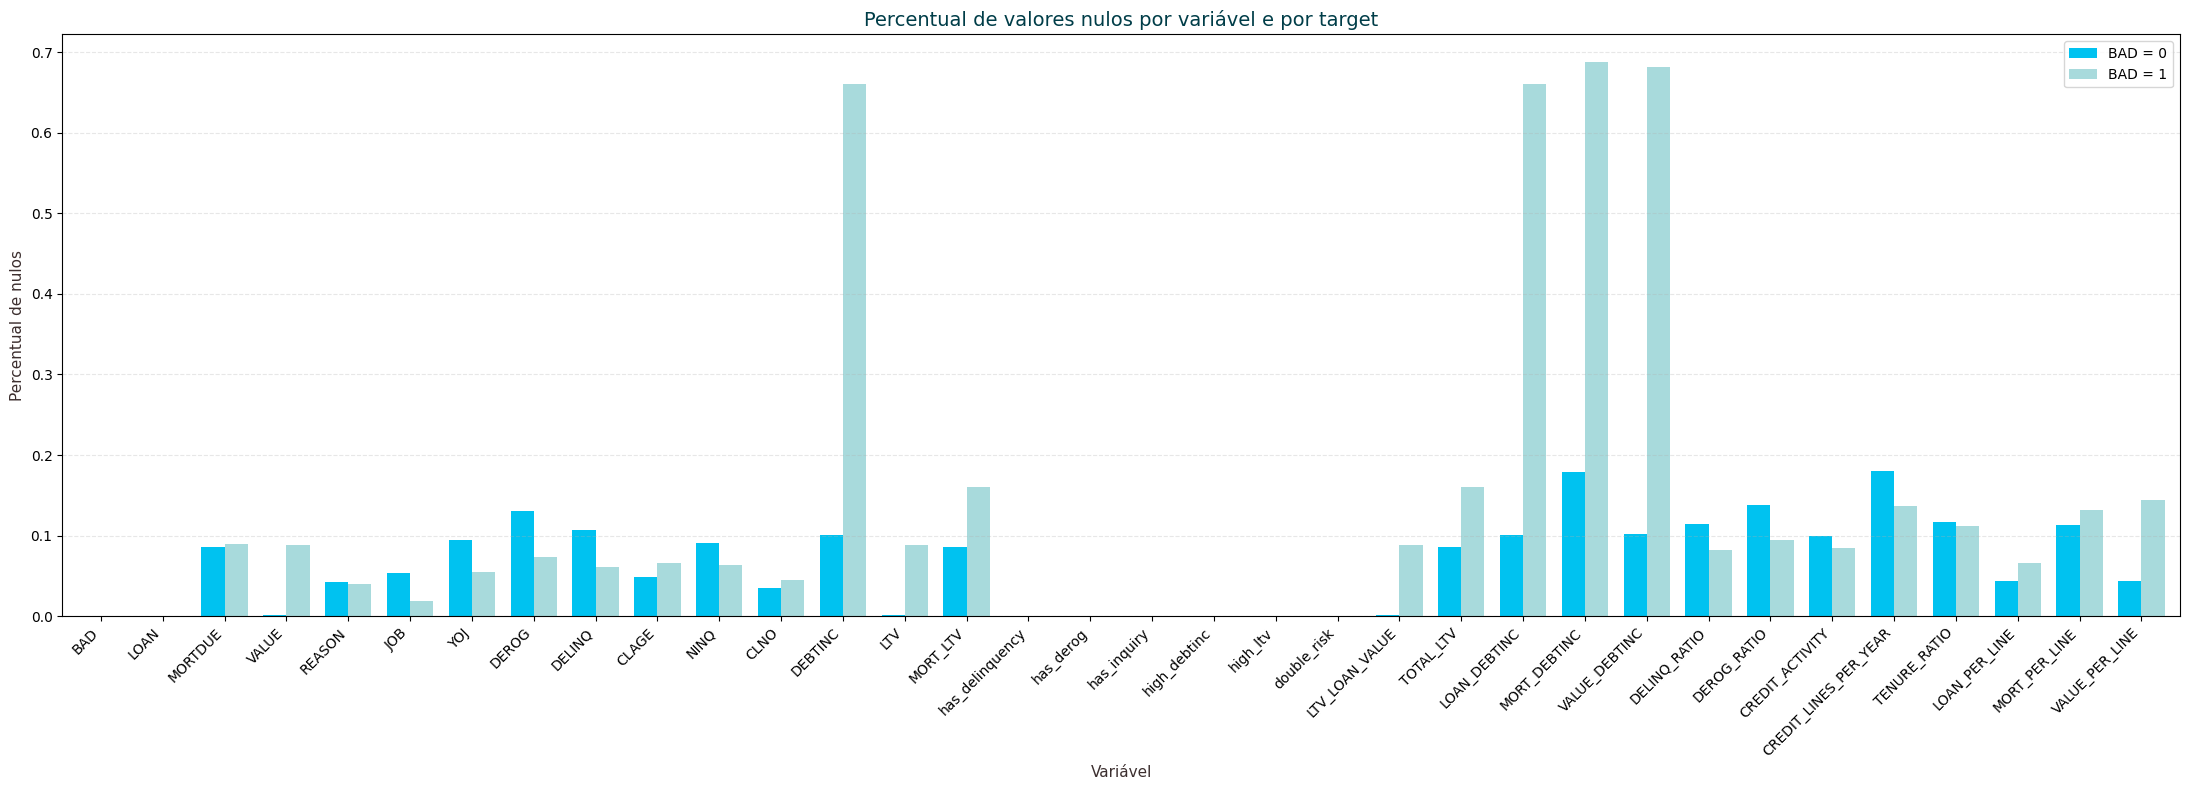

In [ ]:
plt.figure(figsize=(22,8))

missing_by_target[["BAD = 0","BAD = 1"]].plot(
    kind="bar",
    width=0.75,
    color=[COLOR_BLUE, "#a8dadc"],
    ax=plt.gca()
)

plt.title(
    "Percentual de valores nulos por variável e por target",
    color=COLOR_TITLE,
    fontsize=14
)

plt.xlabel("Variável", color=COLOR_DARK, fontsize=11)
plt.ylabel("Percentual de nulos", color=COLOR_DARK, fontsize=11)

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

#### . Estratégia para lidar com nulos


In [ ]:
# ===============================
# DESCRIÇÃO E GRUPO DAS VARIÁVEIS
# ===============================

descricao_variaveis = {

    "BAD": "Indicador de inadimplência",

    "CLAGE": "Tempo histórico crédito",
    "CLNO": "Total linhas crédito",
    "DEBTINC": "Relação dívida/renda",
    "DELINQ": "Linhas inadimplentes",
    "DEROG": "Registros negativos",
    "JOB": "Categoria ocupacional",
    "LOAN": "Valor empréstimo",
    "MORTDUE": "Valor devido hipoteca",
    "NINQ": "Consultas recentes",
    "REASON": "Motivo empréstimo",
    "VALUE": "Valor imóvel",
    "YOJ": "Anos no emprego",

    "LTV": "Loan to Value (Empréstimo / Valor do imóvel)",
    "MORT_LTV": "Mortgage / Valor do imóvel",
    "TOTAL_LTV": "Endividamento total imobiliário",

    "LOAN_DEBTINC": "Interação empréstimo e comprometimento de renda",
    "MORT_DEBTINC": "Interação hipoteca e comprometimento de renda",
    "VALUE_DEBTINC": "Interação valor do imóvel e comprometimento de renda",

    "DELINQ_RATIO": "Proporção de linhas inadimplentes",
    "DEROG_RATIO": "Proporção de registros negativos",
    "CREDIT_ACTIVITY": "Proporção de consultas de crédito",

    "CREDIT_LINES_PER_YEAR": "Intensidade de crédito por ano de trabalho",
    "TENURE_RATIO": "Estabilidade no emprego vs histórico de crédito",

    "LOAN_PER_LINE": "Valor médio do empréstimo por linha de crédito",
    "MORT_PER_LINE": "Valor médio de hipoteca por linha de crédito",
    "VALUE_PER_LINE": "Valor médio do imóvel por linha de crédito",

    "has_delinquency": "Flag histórico de inadimplência",
    "has_derog": "Flag registros negativos",
    "has_inquiry": "Flag consultas recentes crédito",
    "high_ltv": "Flag alto Loan to Value",
    "high_debtinc": "Flag alto comprometimento renda",
    "double_risk": "Flag combinação alto LTV e alto DEBTINC"
}

grupo_variaveis = {

    "BAD": "Target",

    "YOJ": "Perfil do Cliente",
    "JOB": "Perfil do Cliente",
    "CLAGE": "Perfil do Cliente",
    "CLNO": "Perfil do Cliente",
    "TENURE_RATIO": "Perfil do Cliente",

    "DEBTINC": "Capacidade de Pagamento",
    "DELINQ": "Capacidade de Pagamento",
    "DEROG": "Capacidade de Pagamento",
    "NINQ": "Capacidade de Pagamento",

    "DELINQ_RATIO": "Capacidade de Pagamento",
    "DEROG_RATIO": "Capacidade de Pagamento",
    "CREDIT_ACTIVITY": "Capacidade de Pagamento",
    "CREDIT_LINES_PER_YEAR": "Capacidade de Pagamento",

    "has_delinquency": "Capacidade de Pagamento",
    "has_derog": "Capacidade de Pagamento",
    "has_inquiry": "Capacidade de Pagamento",
    "high_debtinc": "Capacidade de Pagamento",

    "LOAN": "Estrutura da Operação",
    "VALUE": "Estrutura da Operação",
    "MORTDUE": "Estrutura da Operação",
    "REASON": "Estrutura da Operação",

    "LTV": "Estrutura da Operação",
    "MORT_LTV": "Estrutura da Operação",
    "TOTAL_LTV": "Estrutura da Operação",

    "LOAN_DEBTINC": "Estrutura da Operação",
    "MORT_DEBTINC": "Estrutura da Operação",
    "VALUE_DEBTINC": "Estrutura da Operação",

    "LOAN_PER_LINE": "Estrutura da Operação",
    "MORT_PER_LINE": "Estrutura da Operação",
    "VALUE_PER_LINE": "Estrutura da Operação",

    "high_ltv": "Estrutura da Operação",
    "double_risk": "Estrutura da Operação"
}

# ===============================
# MISSING
# ===============================

missing_total = (df.isna().mean() * 100).round(2)

missing_bad_0 = (df[df["BAD"] == 0].isna().mean() * 100).round(2)
missing_bad_1 = (df[df["BAD"] == 1].isna().mean() * 100).round(2)

diff_missing = (missing_bad_0 - missing_bad_1).abs().round(2)

# ===============================
# TIPO DAS VARIÁVEIS
# ===============================

tipo = pd.Series(index=df.columns, dtype="object")

tipo.loc[df.select_dtypes(include=["object"]).columns] = "Categórica"

num_cols = df.select_dtypes(include=["int64","float64"]).columns

tipo.loc[num_cols[df[num_cols].nunique(dropna=True) == 2]] = "Binária"
tipo.loc[num_cols[df[num_cols].nunique(dropna=True) > 2]] = "Numérica"

tipo.loc["BAD"] = "Target"

# ===============================
# ASSOCIAÇÃO COM BAD
# ===============================

corr_num = df.corr(numeric_only=True)["BAD"].drop("BAD").abs()

from scipy.stats import chi2_contingency
import numpy as np

cramers_v = {}

for col in df.select_dtypes(include=["object"]).columns:

    tab = pd.crosstab(df[col], df["BAD"])

    if tab.shape[0] > 1:

        chi2, p, dof, exp = chi2_contingency(tab)
        n = tab.sum().sum()

        cramers_v[col] = np.sqrt(chi2 / (n * (min(tab.shape)-1)))

corr_cat = pd.Series(cramers_v)

associacao_bad = pd.concat([corr_num, corr_cat]).round(3)

# ===============================
# QUADRO
# ===============================

quadro = pd.DataFrame({

    "Grupo": df.columns.map(grupo_variaveis),
    "Variável": df.columns,
    "Tipo": tipo.values,
    "Descrição": df.columns.map(descricao_variaveis),
    "Associacao_com_BAD": df.columns.map(associacao_bad),
    "%_Missing_Total": df.columns.map(missing_total),
    "Diff_Missing_BAD": df.columns.map(diff_missing)

})

# ===============================
# ESTRATÉGIA FINAL
# ===============================

estrategia_decidida = {

    "DEROG": "Missing informativo (criar flag)",

    "DELINQ_RATIO": "Imputação + Flag Missing",
    "DEBTINC": "Imputação + Flag Missing",
    "DEROG_RATIO": "Imputação + Flag Missing",
    "VALUE_DEBTINC": "Imputação + Flag Missing",
    "CREDIT_LINES_PER_YEAR": "Imputação + Flag Missing",
    "MORT_DEBTINC": "Imputação + Flag Missing",
    "LOAN_DEBTINC": "Imputação + Flag Missing",
    "TOTAL_LTV": "Imputação + Flag Missing",
    "MORT_LTV": "Imputação + Flag Missing"
}

quadro["Estrategia_Final"] = quadro["Variável"].map(estrategia_decidida)

# ===============================
# JUSTIFICATIVAS
# ===============================

justificativas = {

"DEROG": "Ausência pode indicar falta de histórico negativo. Em scorecards é comum tratar missing como informativo.",

"DELINQ_RATIO": "Variável contínua derivada do comportamento de crédito. Imputação mantém distribuição enquanto flag captura ausência.",

"DEBTINC": "Uma das variáveis mais preditivas em modelos de crédito. Imputação preserva escala da relação dívida/renda.",

"DEROG_RATIO": "Indicador proporcional de registros negativos. Imputação mantém continuidade da variável.",

"VALUE_DEBTINC": "Relaciona valor do imóvel com comprometimento de renda.",

"CREDIT_LINES_PER_YEAR": "Mede intensidade de uso de crédito ao longo do tempo.",

"MORT_DEBTINC": "Relação entre hipoteca e renda relevante para capacidade de pagamento.",

"LOAN_DEBTINC": "Indica peso do empréstimo sobre renda disponível.",

"TOTAL_LTV": "LTV é uma das variáveis mais importantes em risco imobiliário.",

"MORT_LTV": "Captura colateralização da dívida hipotecária."
}

quadro["Justificativa"] = quadro["Variável"].map(justificativas)

# ===============================
# ORDENAR
# ===============================

quadro = quadro.sort_values(
    ["Associacao_com_BAD","%_Missing_Total"],
    ascending=[False,False]
)

In [ ]:

quadro

,Grupo,Variável,Tipo,Descrição,Associacao_com_BAD,%_Missing_Total,Diff_Missing_BAD,Estrategia_Final,Justificativa
8,Capacidade de Pagamento,DELINQ,Numérica,Linhas inadimplentes,0.354,9.73,4.59,NaN,NaN
26,Capacidade de Pagamento,DELINQ_RATIO,Numérica,Proporção de linhas inadimplentes,0.353,10.77,3.26,Imputação + Flag Missing,Variável contínua derivada do comportamento de...
15,Capacidade de Pagamento,has_delinquency,Binária,Flag histórico de inadimplência,0.308,0.00,0.00,NaN,NaN
7,Capacidade de Pagamento,DEROG,Numérica,Registros negativos,0.276,11.88,5.70,Missing informativo (criar flag),Ausência pode indicar falta de histórico negat...
16,Capacidade de Pagamento,has_derog,Binária,Flag registros negativos,0.261,0.00,0.00,NaN,NaN
12,Capacidade de Pagamento,DEBTINC,Numérica,Relação dívida/renda,0.200,21.26,56.03,Imputação + Flag Missing,Uma das variáveis mais preditivas em modelos d...
27,Capacidade de Pagamento,DEROG_RATIO,Numérica,Proporção de registros negativos,0.182,12.92,4.37,Imputação + Flag Missing,Indicador proporcional de registros negativos....
10,Capacidade de Pagamento,NINQ,Numérica,Consultas recentes,0.175,8.56,2.81,NaN,NaN
9,Perfil do Cliente,CLAGE,Numérica,Tempo histórico crédito,0.170,5.17,1.74,NaN,NaN
18,Capacidade de Pagamento,high_debtinc,Binária,Flag alto comprometimento renda,0.164,0.00,0.00,NaN,NaN


| Estratégia               | Condição no código                                                                          | O que significa                                                       | Ação recomendada                                                     | Justificativa estatística                                         |
| ------------------------ | ------------------------------------------------------------------------------------------- | --------------------------------------------------------------------- | -------------------------------------------------------------------- | ----------------------------------------------------------------- |
| Sem ação                 | `%_Missing_Total = 0`                                                                       | A variável não possui valores faltantes                               | Nenhuma transformação necessária                                     | Não há perda de informação nem risco de viés                      |
| Imputação simples        | `Tipo = Numérica` e `%_Missing_Total < 5%`                                                  | Pequena quantidade de valores faltantes                               | Substituir por média ou mediana                                      | Pequena proporção de missing raramente afeta a distribuição       |
| Imputação + Flag Missing | `Tipo = Numérica` e `%_Missing_Total entre 5% e 15%`                                        | Missing pode carregar informação relevante                            | Imputar valor (mediana) + criar variável indicadora (`flag_missing`) | Permite que o modelo capture padrão associado à ausência de dados |
| Missing informativo      | `%_Missing_Total > 10%` e `Diff_Missing_BAD > 3%` **ou variável com significado econômico** | Missing tem comportamento diferente entre adimplentes e inadimplentes | Criar flag de missing e manter valor imputado ou categoria própria   | Evidência de **MNAR (Missing Not At Random)**                     |
| Criar categoria Missing  | `Tipo = Categórica` com valores faltantes                                                   | Missing tratado como categoria                                        | Substituir NA por `"Missing"`                                        | Evita perda de informação e preserva observações                  |
| Avaliar Remover          | `%_Missing_Total > 40%` e `Força_com_BAD < 0.05`                                            | Muito missing e pouca relevância preditiva                            | Considerar remoção da variável                                       | Baixo ganho informacional e alto risco de ruído                   |


### 4.1.5.Variáveis com Possível Risco de Leakage

In [ ]:
possible_leakage_vars = [
    "DELINQ",
    "DEROG",
    "NINQ"
]

df[possible_leakage_vars].describe()

,DELINQ,DEROG,NINQ
count,5380.000000,5252.000000,5450.000000
mean,0.449442,0.254570,1.186055
std,1.127266,0.846047,1.728675
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,0.000000,0.000000,2.000000
max,15.000000,10.000000,17.000000


Avaliação de risco de data leakage

Algumas variáveis como DELINQ, DEROG e NINQ foram inicialmente avaliadas como potenciais fontes de data leakage, pois refletem eventos negativos no histórico de crédito.

Entretanto, essas informações representam dados históricos do cliente obtidos em bureaus de crédito, que normalmente estão disponíveis no momento da concessão do empréstimo.

Portanto, essas variáveis não caracterizam leakage, pois não utilizam informações do futuro ou relacionadas ao desempenho do empréstimo atual.

DELINQ
Número de linhas de crédito inadimplentes

não diz qual empréstimo, apenas o histórico do cliente.

### 4.1.6.Análise de risco por variável

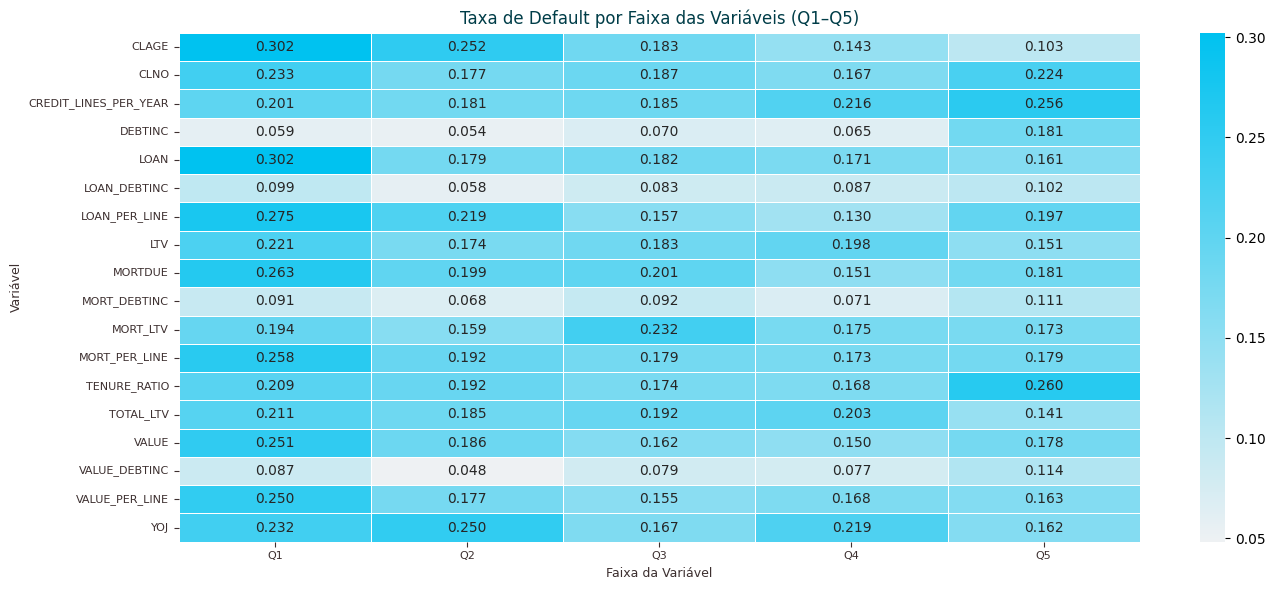

In [ ]:
variaveis = [

    # perfil de crédito
    "CLAGE",
    "CLNO",
    "YOJ",

    # capacidade de pagamento
    "DEBTINC",
    "DELINQ",
    "DEROG",
    "NINQ",

    # estrutura da operação
    "LOAN",
    "VALUE",
    "MORTDUE",

    # métricas derivadas
    "LTV",
    "MORT_LTV",
    "TOTAL_LTV",

    "LOAN_DEBTINC",
    "MORT_DEBTINC",
    "VALUE_DEBTINC",

    "DELINQ_RATIO",
    "DEROG_RATIO",
    "CREDIT_ACTIVITY",

    "CREDIT_LINES_PER_YEAR",
    "TENURE_RATIO",

    "LOAN_PER_LINE",
    "MORT_PER_LINE",
    "VALUE_PER_LINE"

]

heatmap_faixa_risco_variaveis(df, "BAD", variaveis)

### .Principais insights — Taxa de Default por Faixa das Variáveis



CLAGE apresenta relação inversa com o risco: clientes com maior tempo de histórico de crédito possuem menor taxa de default.

VALUE e MORTDUE indicam maior inadimplência nas faixas mais baixas, sugerindo associação entre menor valor de patrimônio/garantia e maior risco.

DEBTINC mostra aumento claro da taxa de default nas faixas superiores, indicando que maior comprometimento de renda está associado a maior probabilidade de inadimplência.

LTV e MORT_LTV apresentam variações moderadas entre faixas, sugerindo influência no risco, porém com comportamento menos monotônico.

CLNO e YOJ apresentam padrões menos consistentes, indicando possível efeito indireto ou dependente de outras variáveis.

Conclusão: variáveis relacionadas a histórico de crédito, comprometimento financeiro e valor do ativo demonstram maior capacidade de discriminar risco e são fortes candidatas para inclusão no modelo de previsão de default.

## 4.2 Seleção de Variáveis

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import KBinsDiscretizer
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

target = 'BAD'

df_work = df.copy()

num_cols = df_work.select_dtypes(include=['number']).columns.tolist()
cat_cols = df_work.select_dtypes(exclude=['number']).columns.tolist()

num_cols = [c for c in num_cols if c != target]
cat_cols = [c for c in cat_cols if c != target]

features = num_cols + cat_cols

# -----------------------
# Cramer's V
# -----------------------

def cramers_v(x, y):

    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]

    n = confusion.sum().sum()
    r,k = confusion.shape

    return np.sqrt((chi2/n) / (min(k-1,r-1)))

# -----------------------
# KS
# -----------------------

def ks_stat(tab):

    good = tab['good'].values
    bad = tab['bad'].values

    good = good/good.sum()
    bad = bad/bad.sum()

    return np.max(np.abs(np.cumsum(good) - np.cumsum(bad)))

# -----------------------
# IV
# -----------------------

def iv_stat(tab):

    good = tab['good'].values
    bad = tab['bad'].values

    dist_good = good/good.sum()
    dist_bad = bad/bad.sum()

    woe = np.log((dist_good+1e-6)/(dist_bad+1e-6))

    iv = np.sum((dist_good-dist_bad)*woe)

    return iv

# -----------------------
# BIN NUMERIC SAFE
# -----------------------

def bin_numeric(series):

    n_unique = series.nunique()

    bins = min(10, n_unique)

    if bins < 2:
        return series.fillna("MISSING")

    est = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='quantile')

    mask = series.notna()

    b = pd.Series(index=series.index)

    b.loc[mask] = est.fit_transform(series.loc[mask].values.reshape(-1,1)).flatten()

    b = b.astype("object")

    b = b.fillna("MISSING")

    return b

# -----------------------
# REDUNDANCY
# -----------------------

corr_matrix = df_work[num_cols].corr().abs()

np.fill_diagonal(corr_matrix.values,np.nan)

cramer_matrix = pd.DataFrame(index=cat_cols,columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:

        if c1==c2:
            cramer_matrix.loc[c1,c2]=np.nan
        else:
            cramer_matrix.loc[c1,c2]=cramers_v(
                df_work[c1].fillna("MISSING"),
                df_work[c2].fillna("MISSING")
            )

# -----------------------
# MAIN LOOP
# -----------------------

rows=[]

for col in features:

    s=df_work[col]

    missing_count=s.isna().sum()
    missing_pct=s.isna().mean()

    if col in num_cols:
        b=bin_numeric(s)
    else:
        b=s.fillna("MISSING")

    tab=pd.crosstab(b,df_work[target]).rename(columns={0:"good",1:"bad"})

    if "good" not in tab.columns:
        tab["good"]=0

    if "bad" not in tab.columns:
        tab["bad"]=0

    tab=tab[["good","bad"]]

    iv=iv_stat(tab)
    ks=ks_stat(tab)

    # redundancy

    if col in num_cols:

        red_feature=corr_matrix[col].idxmax()
        red_value=corr_matrix[col].max()
        metric="pearson"

    else:

        red_feature=cramer_matrix.loc[col].idxmax()
        red_value=cramer_matrix.loc[col].max()
        metric="cramers_v"

    # decision rules

    if iv < 0.02 or missing_pct > 0.6 or red_value > 0.85:
        decision="ELIMINAR"
    else:
        decision="ADICIONAR"

    rows.append({
        "feature":col,
        "type":"numeric" if col in num_cols else "categorical",
        "missing_count":missing_count,
        "missing_pct":missing_pct,
        "IV":iv,
        "KS":ks,
        "redundancy_feature":red_feature,
        "redundancy_value":red_value,
        "redundancy_metric":metric,
        "decision":decision
    })

summary_df=pd.DataFrame(rows).sort_values(by="IV",ascending=False)

# -----------------------
# COLOR STYLE
# -----------------------

def color_decision(val):

    if val=="ADICIONAR":
        return "background-color: lightgreen"
    if val=="ELIMINAR":
        return "background-color: salmon"

summary_df.style.applymap(color_decision,subset=["decision"])

,feature,type,missing_count,missing_pct,IV,KS,redundancy_feature,redundancy_value,redundancy_metric,decision
9,DEBTINC,numeric,1267,0.212584,1.877039,0.600415,high_debtinc,0.687616,pearson,ADICIONAR
22,VALUE_DEBTINC,numeric,1298,0.217785,1.778720,0.580011,MORT_DEBTINC,0.901767,pearson,ELIMINAR
20,LOAN_DEBTINC,numeric,1267,0.212584,1.653304,0.560242,LOAN,0.879328,pearson,ELIMINAR
21,MORT_DEBTINC,numeric,1669,0.280034,1.218584,0.509604,MORTDUE,0.901924,pearson,ELIMINAR
5,DELINQ,numeric,580,0.097315,0.565320,0.263392,DELINQ_RATIO,0.842394,pearson,ADICIONAR
23,DELINQ_RATIO,numeric,642,0.107718,0.495733,0.248020,DELINQ,0.842394,pearson,ADICIONAR
2,VALUE,numeric,112,0.018792,0.469555,0.086842,VALUE_DEBTINC,0.896948,pearson,ELIMINAR
18,LTV_LOAN_VALUE,numeric,112,0.018792,0.404775,0.086842,LTV,1.000000,pearson,ELIMINAR
10,LTV,numeric,112,0.018792,0.404775,0.086842,LTV_LOAN_VALUE,1.000000,pearson,ELIMINAR
4,DEROG,numeric,708,0.118792,0.347187,0.156673,has_derog,0.751952,pearson,ADICIONAR


| variável              | grupo     | missing | força com BAD | comportamento risco | lógica negócio | redundância             | decisão |
| --------------------- | --------- | ------- | ------------- | ------------------- | -------------- | ----------------------- | ------- |
| CLAGE                 | perfil    | baixo   | médio         | monotônico ↓        | alta           | baixa                   | manter  |
| CLNO                  | perfil    | baixo   | médio         | irregular           | média          | baixa                   | testar  |
| YOJ                   | perfil    | médio   | baixo         | fraco               | média          | baixa                   | testar  |
| DEBTINC               | pagamento | alto    | alto          | monotônico ↑        | alta           | baixa                   | manter  |
| DELINQ                | pagamento | médio   | alto          | monotônico ↑        | alta           | baixa                   | manter  |
| DEROG                 | pagamento | médio   | muito alto    | monotônico ↑        | alta           | baixa                   | manter  |
| NINQ                  | pagamento | médio   | médio         | moderado            | alta           | baixa                   | manter  |
| LOAN                  | estrutura | baixo   | médio         | irregular           | média          | redundante              | avaliar |
| VALUE                 | estrutura | baixo   | médio         | irregular           | média          | redundante              | avaliar |
| MORTDUE               | estrutura | médio   | médio         | moderado            | média          | baixa                   | testar  |
| LTV                   | estrutura | baixo   | alto          | monotônico ↑        | alta           | substitui LOAN/VALUE    | manter  |
| MORT_LTV              | estrutura | médio   | médio         | moderado            | média          | baixa                   | testar  |
| TOTAL_LTV             | estrutura | baixo   | médio         | moderado            | média          | correlacionado com LTV  | testar  |
| DELINQ_RATIO          | derivada  | baixo   | alto          | monotônico ↑        | alta           | derivada de DELINQ      | manter  |
| DEROG_RATIO           | derivada  | baixo   | alto          | monotônico ↑        | alta           | derivada de DEROG       | manter  |
| CREDIT_ACTIVITY       | derivada  | baixo   | médio         | moderado            | média          | derivada de NINQ        | testar  |
| CREDIT_LINES_PER_YEAR | derivada  | médio   | baixo         | fraco               | média          | derivada CLNO/YOJ       | avaliar |
| TENURE_RATIO          | derivada  | médio   | baixo         | fraco               | média          | derivada CLAGE/YOJ      | avaliar |
| LOAN_DEBTINC          | derivada  | médio   | médio         | moderado            | alta           | combinação LOAN + renda | testar  |
| MORT_DEBTINC          | derivada  | médio   | médio         | moderado            | alta           | combinação MORT + renda | testar  |
| VALUE_DEBTINC         | derivada  | médio   | baixo         | fraco               | média          | redundante com VALUE    | avaliar |
| has_delinquency       | derivada  | 0       | muito alto    | forte               | alta           | derivada                | manter  |
| has_derog             | derivada  | 0       | muito alto    | forte               | alta           | derivada                | manter  |
| has_inquiry           | derivada  | 0       | médio         | moderado            | média          | derivada                | manter  |
| high_debtinc          | derivada  | 0       | negativo      | invertido           | baixa          | derivada                | remover |
| high_ltv              | derivada  | 0       | fraco         | fraco               | baixa          | derivada                | remover |
| double_risk           | _         |         |               |                     |                |                         |         |


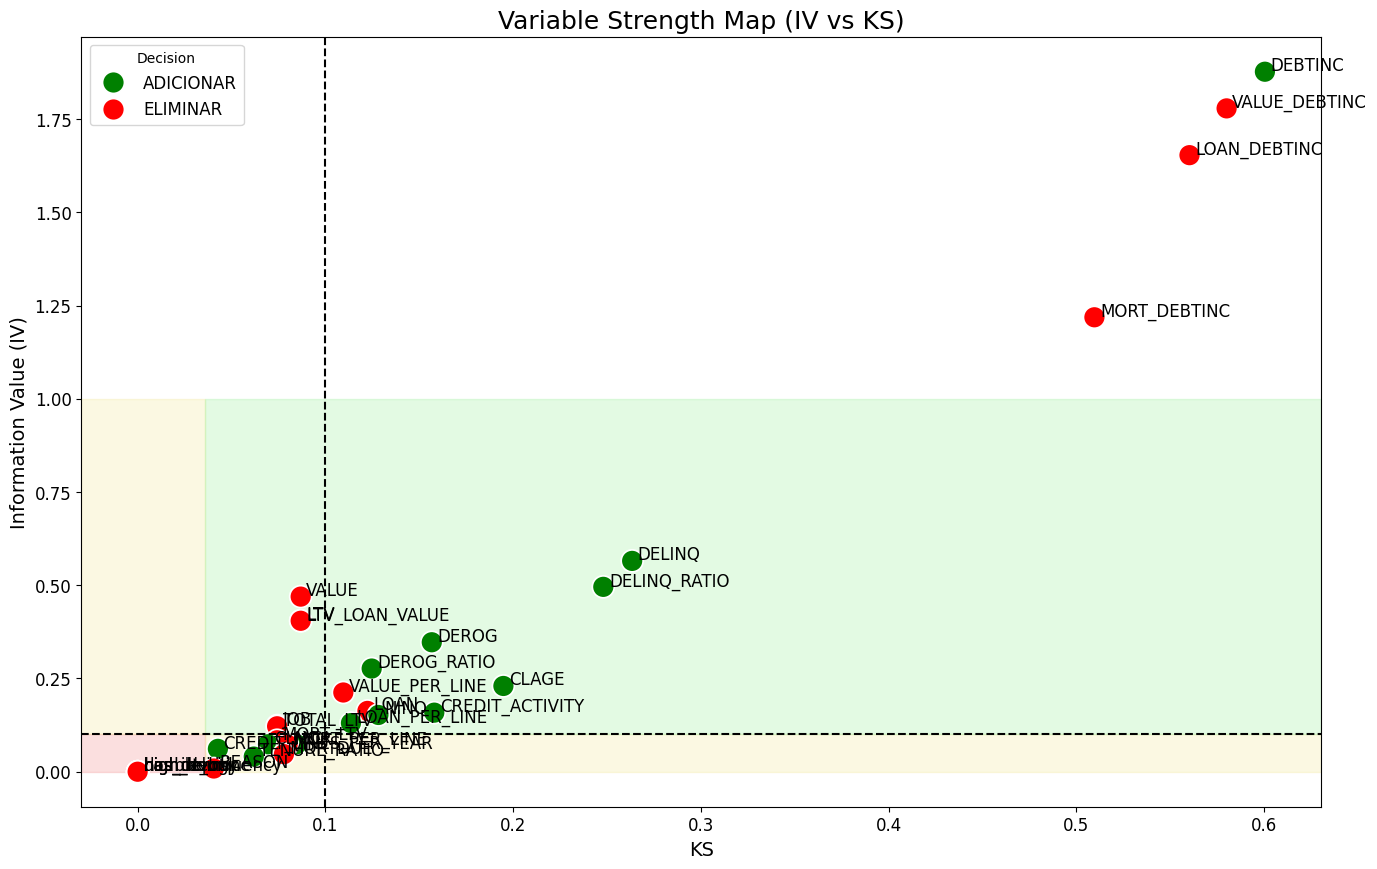

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

# limites
ks_cut = 0.1
iv_cut = 0.1

# quadrantes coloridos
plt.axhspan(0, iv_cut, xmin=0, xmax=ks_cut, color="lightcoral", alpha=0.25)
plt.axhspan(0, iv_cut, xmin=ks_cut, xmax=1, color="khaki", alpha=0.25)
plt.axhspan(iv_cut, 1, xmin=0, xmax=ks_cut, color="khaki", alpha=0.25)
plt.axhspan(iv_cut, 1, xmin=ks_cut, xmax=1, color="lightgreen", alpha=0.25)

# scatter
sns.scatterplot(
    data=summary_df,
    x="KS",
    y="IV",
    hue="decision",
    palette={"ADICIONAR":"green","ELIMINAR":"red"},
    s=250
)

# labels
for i,row in summary_df.iterrows():
    plt.text(
        row["KS"]+0.003,
        row["IV"]+0.003,
        row["feature"],
        fontsize=12
    )

# linhas de corte
plt.axhline(iv_cut,color="black",linestyle="--")
plt.axvline(ks_cut,color="black",linestyle="--")

# títulos
plt.title("Variable Strength Map (IV vs KS)",fontsize=18)
plt.xlabel("KS",fontsize=14)
plt.ylabel("Information Value (IV)",fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(title="Decision",fontsize=12)

plt.show()

## 4.3 Divisão treino e teste

In [ ]:
#separar em treino e teste
from sklearn.model_selection import train_test_split
x = df.drop('BAD', axis = 1)
y = df['BAD']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,
                                                    random_state = 0, stratify = y)


In [ ]:
# --------------- contando -----------------
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


BAD
0    0.800545
1    0.199455
Name: proportion, dtype: float64
BAD
0    0.800336
1    0.199664
Name: proportion, dtype: float64


#### . Removendo inconsistências

In [ ]:
def remove_credit_inconsistencies(X, y):

    mask_valid = (
        (X["LOAN"] <= X["VALUE"]) &
        (X["DELINQ"] <= X["CLNO"])
    )

    X_clean = X[mask_valid].copy()
    y_clean = y[mask_valid].copy()

    return X_clean, y_clean

In [ ]:
x_train, y_train = remove_credit_inconsistencies(x_train, y_train)
x_test, y_test = remove_credit_inconsistencies(x_test, y_test)

In [ ]:
features_remover = [

    'VALUE_DEBTINC',
    'LOAN_DEBTINC',
    'MORT_DEBTINC',

    'LTV_LOAN_VALUE',
   # 'LTV',

    'VALUE_PER_LINE',
    'MORT_PER_LINE',

    'TOTAL_LTV',
    'MORT_LTV',

    'REASON'
]

x_train = x_train.drop(columns=features_remover)
x_test = x_test.drop(columns=features_remover)

## 4.3 Pipeline de pré-processamento -

##### . tratamento de inconsistencias economicas

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np


class CreditConsistencyCleaner(BaseEstimator, TransformerMixin):

    def __init__(self,
                 mortdue_col="MORTDUE",
                 value_col="VALUE"):

        self.mortdue_col = mortdue_col
        self.value_col = value_col


    def fit(self, X, y=None):
        return self


    def transform(self, X):

        X = X.copy()

        # ==========================
        # Criar MORT_LTV
        # ==========================
        X["MORT_LTV"] = X[self.mortdue_col] / X[self.value_col]

        # truncar valores extremos
        X["MORT_LTV"] = X["MORT_LTV"].clip(upper=1)

        return X

##### .tratamento para lidar com outliers - log transform variaveis financeiras

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class LogTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = np.log1p(X[col])
        return X

##### . tratamento para lidar com outliers - Transformer para percentile capping

In [ ]:
class PercentileCapper(BaseEstimator, TransformerMixin):

    def __init__(self, columns, lower=0.01, upper=0.99):
        self.columns = columns
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):

        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

        for col in self.columns:
            self.lower_bounds_[col] = X[col].quantile(self.lower)
            self.upper_bounds_[col] = X[col].quantile(self.upper)

        return self

    def transform(self, X):

        X = X.copy()

        for col in self.columns:
            X[col] = X[col].clip(
                self.lower_bounds_[col],
                self.upper_bounds_[col]
            )

        return X

##### . tratamento para lidar com outliers - Transformer para binning da variavel LTV

In [ ]:
class LTVBinning(BaseEstimator, TransformerMixin):

    def __init__(self, column="LTV"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        bins = [0, 0.4, 0.6, 0.8, 1, np.inf]
        labels = ["very_low", "low", "medium", "high", "very_high"]

        X["LTV_bin"] = pd.cut(X[self.column], bins=bins, labels=labels)

        return X

#### . Aplicação da estrategia de tratamento de nulos - missing flag


In [ ]:
#from sklearn.impute import SimpleImputer

#SimpleImputer(
#    strategy="median",
#    add_indicator=True
#)

#### . Aplicação da estrategia de tratamento de nulos - imputação e flag controlada por variavel

In [ ]:
#from sklearn.impute import SimpleImputer

#SimpleImputer(
#    strategy="median",
#    add_indicator=True
#)

#### . Aplicação da estrategia de tratamento de nulos - imputação para variáveis numéricas simples

In [ ]:
class SimpleImputerCustom(BaseEstimator, TransformerMixin):

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.medians_ = X[self.columns].median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.columns] = X[self.columns].fillna(self.medians_)
        return X

#### .Aplicação One Hot Encoder - variáveis categóricas

In [ ]:
#from sklearn.preprocessing import OneHotEncoder

## 4.3 Pipeline

In [ ]:
missing_flag_impute_vars = [
    "DELINQ_RATIO",
    "DEBTINC",
    "DEROG_RATIO",
    "CREDIT_LINES_PER_YEAR"
]


simple_impute_vars = [
    "MORTDUE",
    "YOJ",
    "CLAGE",
    "NINQ",
    "CLNO",
    "VALUE",
    "LOAN_PER_LINE",
    "CREDIT_ACTIVITY",
    "TENURE_RATIO",
    "DELINQ"
]


log_vars = [
    "LOAN",
    "VALUE",
    "MORTDUE"
]


cap_vars = [
    "DEBTINC",
    "CLAGE",
    "YOJ"
]


numeric_vars = list(dict.fromkeys(
    simple_impute_vars +
    missing_flag_impute_vars +
    log_vars +
    cap_vars +
    ["DEROG"]
))


categorical_vars = [
    "JOB",
    "LTV_bin"
]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_vars
        ),
        (
            "categorical",
            Pipeline([
                (
                    "missing_fill",
                    SimpleImputer(
                        strategy="constant",
                        fill_value="Missing"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop="first",
                        sparse_output=False
                    )
                )
            ]),
            categorical_vars,
        ),
    ],
    remainder="drop"
)
pipeline = Pipeline([
    ("consistency_cleaning", CreditConsistencyCleaner()),
    ("ltv_binning", LTVBinning()),
    ("preprocess", preprocessor)
    ])

### Aplicação Pipeline

In [ ]:
X_train_transformed = pipeline.fit_transform(x_train, y_train)
X_test_transformed = pipeline.transform(x_test)


# recuperar nomes das features

feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)


## 4.5 Verificação pós nulos e dummies

In [ ]:
print("NaNs no treino:", X_train_transformed.isna().sum().sum())
print("NaNs no teste:", X_test_transformed.isna().sum().sum())


NaNs no treino: 0
NaNs no teste: 0


### . Detecção de métricas redundantes

In [ ]:
import numpy as np

# usar apenas variáveis numéricas
num_df =X_train_transformed.select_dtypes(include="number")

corr = num_df.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

redundant_features = [
    column for column in upper.columns
    if any(upper[column] > 0.9)
]

print("Variáveis altamente correlacionadas:")
print(redundant_features)

Variáveis altamente correlacionadas:
[]


## 5. Modelagem

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    log_loss
)


modelos = {
    "Logistic": LogisticRegression(
        max_iter=1000,        # número máximo de iterações para convergir
        random_state=42       # garante reprodutibilidade
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,     # número de árvores na floresta
        random_state=42       # garante reprodutibilidade
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300,     # número de árvores / boosting rounds
        random_state=42,      # garante reprodutibilidade
        verbosity=-1          # reduz mensagens de log no output
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,     # número de árvores / boosting rounds
        random_state=42,      # garante reprodutibilidade
        eval_metric="logloss",# métrica de otimização durante o treino
        verbosity=0           # evita excesso de mensagens no output
    )
}


### Treinamento

In [ ]:
np.isnan(X_train_transformed).sum()

,0
numeric__MORTDUE,0
numeric__YOJ,0
numeric__CLAGE,0
numeric__NINQ,0
numeric__CLNO,0
numeric__VALUE,0
numeric__LOAN_PER_LINE,0
numeric__CREDIT_ACTIVITY,0
numeric__TENURE_RATIO,0
numeric__DELINQ,0


### Treinamento

In [ ]:
resultados = {}

for nome, modelo in modelos.items():

    print(f"\nTreinando {nome}")

    modelo.fit(X_train_transformed, y_train)

    y_pred = modelo.predict(X_test_transformed)
    y_prob = modelo.predict_proba(X_test_transformed)[:,1]

    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1

    ks_stat = ks_2samp(
        y_prob[y_test == 1],
        y_prob[y_test == 0]
    ).statistic

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    brier = brier_score_loss(y_test, y_prob)
    ll = log_loss(y_test, y_prob)

    resultados[nome] = {
        "AUC": auc,
        "Gini": gini,
        "KS": ks_stat,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "Brier": brier,
        "LogLoss": ll,
        "Model": modelo,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


Treinando Logistic

Treinando RandomForest

Treinando LightGBM

Treinando XGBoost


#### .Métricas

### Feature Importance

In [ ]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

#### .RandomForest

In [ ]:
rf_model = resultados["RandomForest"]["Model"]

fi_rf = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

#display(fi_rf.head(20))

#### .Light GBM

In [ ]:
# LightGBM
lgb_model = resultados["LightGBM"]["Model"]

fi_lgb = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": lgb_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

#display(fi_lgb.head(20))

#### .XGBoost

In [ ]:
xgb_model = resultados["XGBoost"]["Model"]

fi_xgb = (
    pd.DataFrame({
        "Feature": feature_names,
        "Gain": xgb_model.feature_importances_
    })
    .sort_values("Gain", ascending=False)
    .reset_index(drop=True)
)

#display(fi_xgb.head(20))

#### .Logistic

In [ ]:
# pegar modelo treinado
log_model = resultados["Logistic"]["Model"]

# coeficientes
coef = log_model.coef_[0]

# dataframe de importance
fi_log = pd.DataFrame({
    "Feature": feature_names,
    "Coef": coef,
    "Importance_LOG": np.abs(coef)
})

# ordenar
fi_log = fi_log.sort_values("Importance_LOG", ascending=False).reset_index(drop=True)

#display(fi_log.head(20))

In [ ]:
print(fi_rf.columns)
print(fi_lgb.columns)
print(fi_log.columns)
print(fi_xgb.columns)

Index(['Feature', 'Importance'], dtype='object')
Index(['Feature', 'Importance'], dtype='object')
Index(['Feature', 'Coef', 'Importance_LOG'], dtype='object')
Index(['Feature', 'Gain'], dtype='object')


In [ ]:
# padronizar importance de cada modelo

fi_rf_model = fi_rf.rename(columns={
    "Importance": "Importance_RF"
})

fi_lgb_model = fi_lgb.rename(columns={
    "Importance": "Importance_LGB"
})

fi_log_model = fi_log.rename(columns={
    "Coef_abs": "Importance_LOG"
})[["Feature","Importance_LOG"]]

fi_xgb_model = fi_xgb.rename(columns={
    "Gain": "Importance_XGB"
})
fi_compare = (
    fi_rf_model
    .merge(fi_lgb_model, on="Feature", how="outer")
    .merge(fi_log_model, on="Feature", how="outer")
    .merge(fi_xgb_model, on="Feature", how="outer")
)

#display(fi_compare.head(20))

,Feature,Importance_RF,Importance_LGB,Importance_LOG,Importance_XGB
0,categorical__JOB_Missing,0.002626,50,0.020850,0.063515
1,categorical__JOB_Office,0.007641,79,0.072183,0.033185
2,categorical__JOB_Other,0.009408,85,0.011169,0.012659
3,categorical__JOB_ProfExe,0.007169,94,0.014145,0.020481
4,categorical__JOB_Sales,0.003669,23,0.008983,0.029543
5,categorical__JOB_Self,0.003428,27,0.019696,0.009517
6,categorical__LTV_bin_low,0.001735,14,0.010260,0.016640
7,categorical__LTV_bin_medium,0.001410,7,0.005239,0.065115
8,categorical__LTV_bin_very_low,0.003004,11,0.064147,0.024343
9,numeric__CLAGE,0.076455,1062,0.007460,0.026016


In [ ]:
print(fi_compare.columns)

Index(['Feature', 'Importance_RF', 'Importance_LGB', 'Importance_LOG',
       'Importance_XGB'],
      dtype='object')


#### .Comparação de Feature Importance

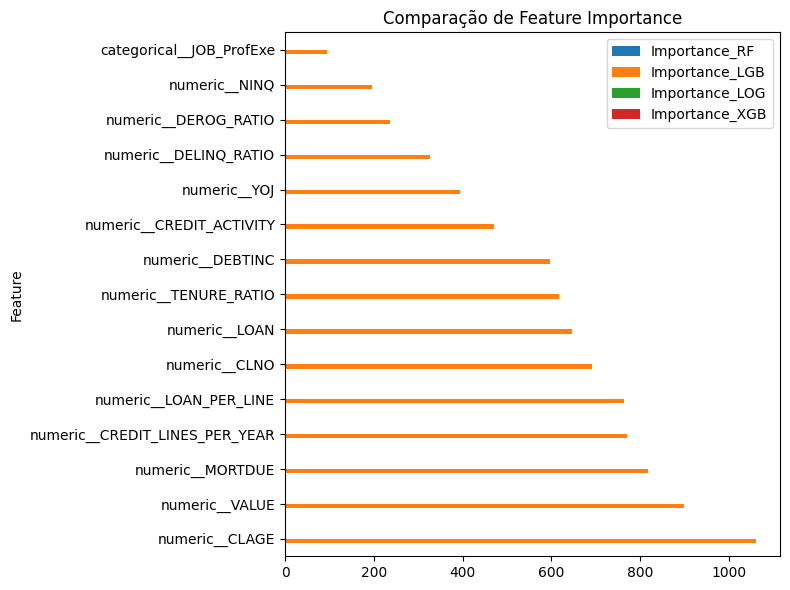

In [ ]:
fi_compare["mean_importance"] = fi_compare[
    ["Importance_RF","Importance_LGB","Importance_LOG","Importance_XGB"]
].mean(axis=1)

fi_compare_top = fi_compare.sort_values(
    "mean_importance",
    ascending=False
).head(15)

fi_compare_top.set_index("Feature")[[
    "Importance_RF",
    "Importance_LGB",
    "Importance_LOG",
    "Importance_XGB"
]].plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Comparação de Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
consenso = pd.concat([
    fi_rf.head(10)["Feature"],
    fi_lgb.head(10)["Feature"],
    fi_xgb.head(10)["Feature"],
    fi_log.head(10)["Feature"]
], ignore_index=True).value_counts()

print("TOP FEATURES CONSENSO")
print(consenso.head(10))

TOP FEATURES CONSENSO
Feature
numeric__DEBTINC                  3
numeric__DELINQ_RATIO             3
numeric__DELINQ                   3
numeric__VALUE                    2
numeric__CLAGE                    2
numeric__CREDIT_LINES_PER_YEAR    2
numeric__LOAN                     2
numeric__CLNO                     2
numeric__MORTDUE                  2
numeric__LOAN_PER_LINE            2
Name: count, dtype: int64


### rever metricas e retirar as redundantes

#### .Métricas

In [ ]:

metricas_df = pd.DataFrame(resultados).T

metricas_df = metricas_df[[
    "AUC",
    "Gini",
    "KS",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Brier",
    "LogLoss"
]]
display(metricas_df)


,AUC,Gini,KS,Accuracy,Precision,Recall,F1,Brier,LogLoss
Logistic,0.791757,0.583514,0.44003,0.837165,0.702128,0.317308,0.437086,0.121125,0.406044
RandomForest,0.977189,0.954379,0.848914,0.91954,0.902597,0.668269,0.767956,0.054441,0.185739
LightGBM,0.966708,0.933417,0.843048,0.929119,0.894118,0.730769,0.804233,0.056998,0.222284
XGBoost,0.961619,0.923238,0.834376,0.928161,0.871508,0.75,0.806202,0.055832,0.227039



#### .Roc Curve

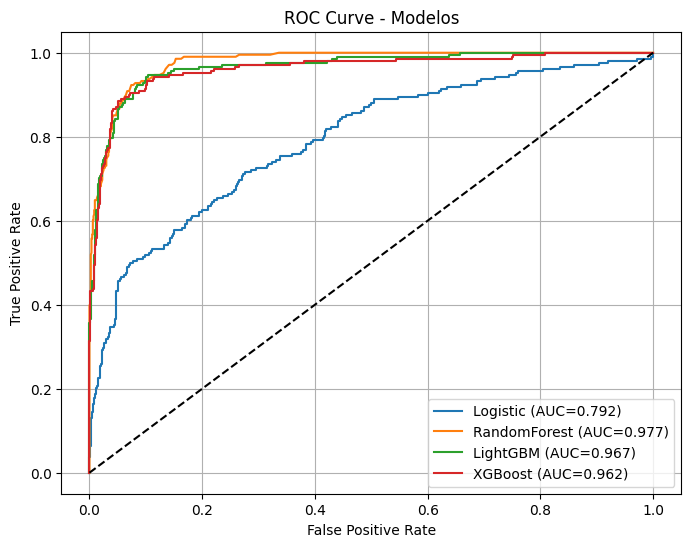

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for nome, res in resultados.items():

    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    auc = roc_auc_score(y_test, res["y_prob"])

    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Modelos")

plt.legend()
plt.grid()
plt.show()

### .KS Curve

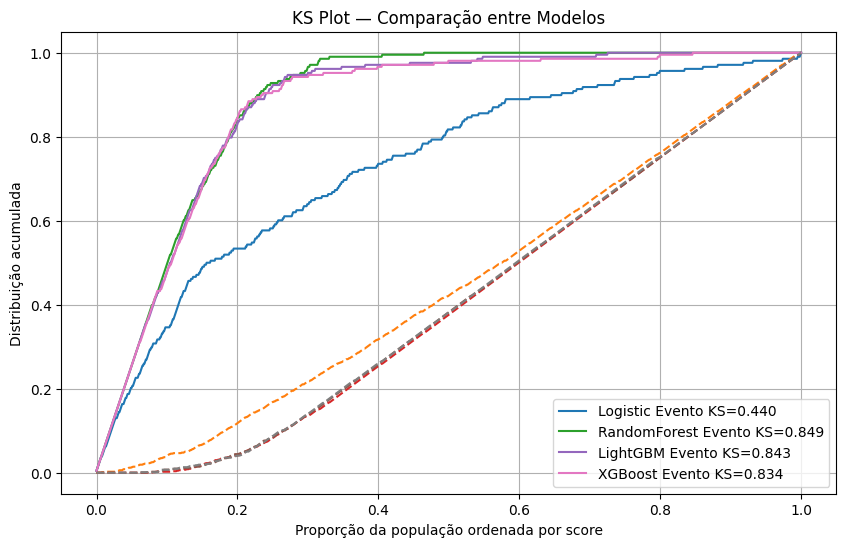

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_true = df_scores["y_true"].values

models = {
    "Logistic": df_scores["Logistic"].values,
    "RandomForest": df_scores["RandomForest"].values,
    "LightGBM": df_scores["LightGBM"].values,
    "XGBoost": df_scores["XGBoost"].values
}

def ks_curve(y_true, y_prob):

    idx = np.argsort(-y_prob)

    y_sorted = y_true[idx]

    is_pos = (y_sorted == 1).astype(int)
    is_neg = (y_sorted == 0).astype(int)

    cum_pos = np.cumsum(is_pos) / is_pos.sum()
    cum_neg = np.cumsum(is_neg) / is_neg.sum()

    ks = np.max(np.abs(cum_pos - cum_neg))

    x = np.linspace(0,1,len(y_sorted))

    return x, cum_pos, cum_neg, ks


plt.figure(figsize=(10,6))

for name, prob in models.items():

    x, pos, neg, ks = ks_curve(y_true, prob)

    plt.plot(x, pos, label=f"{name} Evento KS={ks:.3f}")
    plt.plot(x, neg, linestyle="--")

plt.xlabel("Proporção da população ordenada por score")
plt.ylabel("Distribuição acumulada")
plt.title("KS Plot — Comparação entre Modelos")

plt.legend()
plt.grid(True)

plt.show()

#### .Resumo Métricas

In [ ]:
 metricas_df

,AUC,Gini,KS,Accuracy,Precision,Recall,F1,Brier,LogLoss
Logistic,0.791757,0.583514,0.44003,0.837165,0.702128,0.317308,0.437086,0.121125,0.406044
RandomForest,0.977189,0.954379,0.848914,0.91954,0.902597,0.668269,0.767956,0.054441,0.185739
LightGBM,0.966708,0.933417,0.843048,0.929119,0.894118,0.730769,0.804233,0.056998,0.222284
XGBoost,0.961619,0.923238,0.834376,0.928161,0.871508,0.75,0.806202,0.055832,0.227039


Melhor modelo: RandomForest


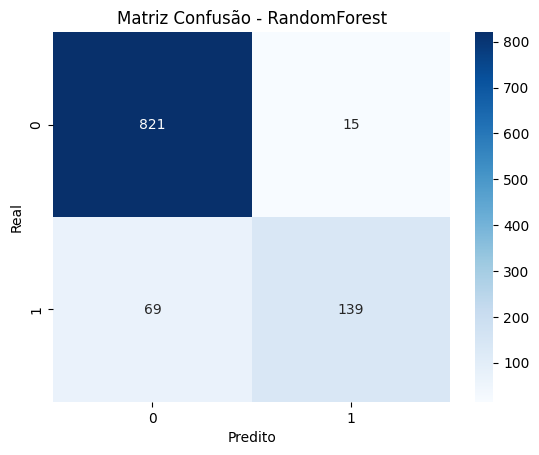

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = metricas_df["AUC"].astype(float).idxmax()

print("Melhor modelo:", best_model)

y_pred_best = resultados[best_model]["y_pred"]

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(f"Matriz Confusão - {best_model}")

plt.show()

##### .Calibration Curve

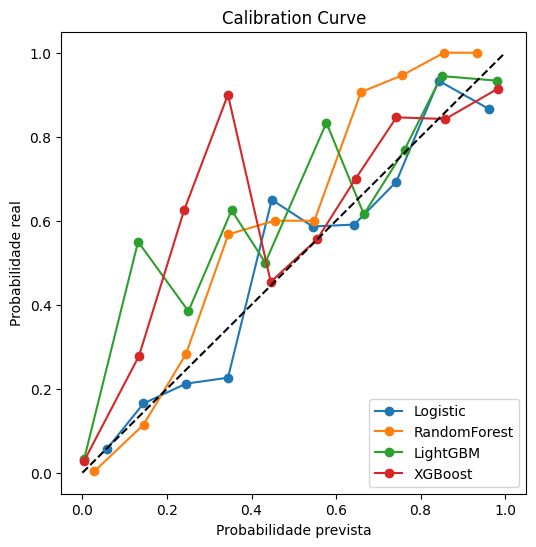

In [ ]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(6,6))

for nome, res in resultados.items():

    prob_true, prob_pred = calibration_curve(
        y_test,
        res["y_prob"],
        n_bins=10
    )

    plt.plot(prob_pred, prob_true, marker="o", label=nome)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Probabilidade prevista")
plt.ylabel("Probabilidade real")

plt.title("Calibration Curve")

plt.legend()
plt.show()

##### .Brier Score Comparação

=== BRIER SCORE COMPARAÇÃO ===
               Brier
RandomForest  0.0544
XGBoost       0.0558
LightGBM      0.0570
Logistic      0.1211


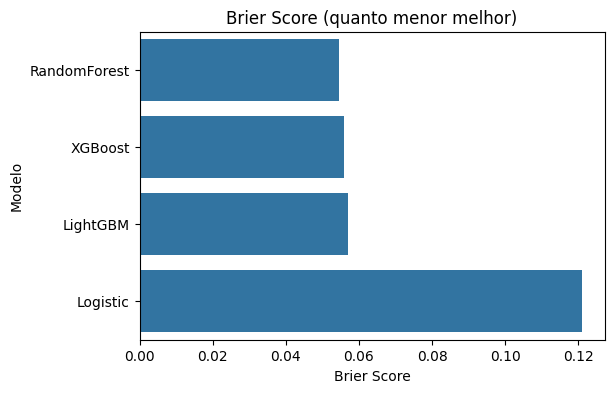

In [ ]:
print("=== BRIER SCORE COMPARAÇÃO ===")

brier_scores = {
    nome: brier_score_loss(y_test, res['y_prob'])
    for nome, res in resultados.items()
}

brier_df = pd.DataFrame.from_dict(
    brier_scores,
    orient='index',
    columns=['Brier']
).sort_values('Brier')

print(brier_df.round(4))


# gráfico
plt.figure(figsize=(6,4))

sns.barplot(
    x=brier_df['Brier'],
    y=brier_df.index
)

plt.title("Brier Score (quanto menor melhor)")
plt.xlabel("Brier Score")
plt.ylabel("Modelo")

plt.show()

##### .Distribuição de Probabilidades

=== DISTRIBUIÇÃO PROBABILIDADES ===


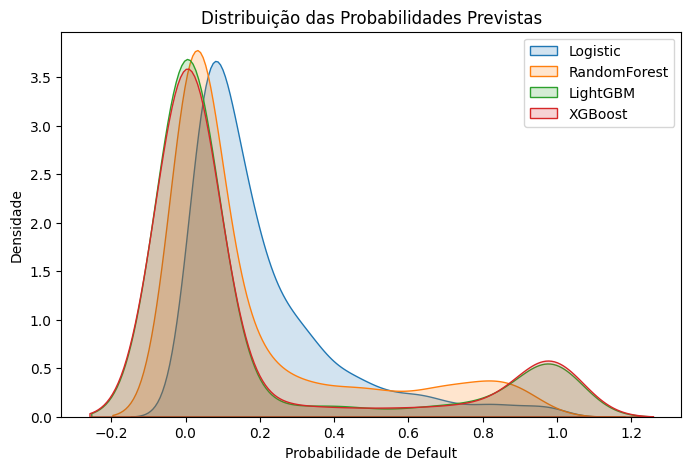

In [ ]:
print("=== DISTRIBUIÇÃO PROBABILIDADES ===")

plt.figure(figsize=(8,5))

for nome, res in resultados.items():

    sns.kdeplot(
        res['y_prob'],
        label=nome,
        fill=True,
        alpha=0.2
    )

plt.title("Distribuição das Probabilidades Previstas")
plt.xlabel("Probabilidade de Default")
plt.ylabel("Densidade")

plt.legend()
plt.show()

##### .Todos os Modelos

In [ ]:
print("=== 15. RELATÓRIO FINAL (TODOS MODELOS) ===")

final_report = pd.DataFrame({

    'Modelo': list(resultados.keys()),

    'AUC': [res['AUC'] for res in resultados.values()],

    'Gini': [res['Gini'] for res in resultados.values()],

    'KS': [res['KS'] for res in resultados.values()],

    'F1': [res['F1'] for res in resultados.values()],

    'Brier': [brier_score_loss(y_test, res['y_prob'])
              for res in resultados.values()],

    'LogLoss': [log_loss(y_test, res['y_prob'])
                for res in resultados.values()]

}).round(4).sort_values('AUC', ascending=False)


print(final_report)

=== 15. RELATÓRIO FINAL (TODOS MODELOS) ===
         Modelo     AUC    Gini      KS      F1   Brier  LogLoss
1  RandomForest  0.9772  0.9544  0.8489  0.7680  0.0544   0.1857
2      LightGBM  0.9667  0.9334  0.8430  0.8042  0.0570   0.2223
3       XGBoost  0.9616  0.9232  0.8344  0.8062  0.0558   0.2270
0      Logistic  0.7918  0.5835  0.4400  0.4371  0.1211   0.4060


In [ ]:
top_features = pd.concat([

    fi_rf.head(10)['Feature'],
    fi_lgb.head(10)['Feature'],
    fi_xgb.head(10)['Feature'],
    fi_log.head(10)['Feature']

], ignore_index=True).value_counts().head(15)


print("\n=== TOP 15 FEATURES (Consenso 4 Modelos) ===")

print(top_features)


=== TOP 15 FEATURES (Consenso 4 Modelos) ===
Feature
numeric__DEBTINC                  3
numeric__DELINQ_RATIO             3
numeric__DELINQ                   3
numeric__VALUE                    2
numeric__CLAGE                    2
numeric__CREDIT_LINES_PER_YEAR    2
numeric__LOAN                     2
numeric__CLNO                     2
numeric__MORTDUE                  2
numeric__LOAN_PER_LINE            2
numeric__TENURE_RATIO             2
numeric__CREDIT_ACTIVITY          2
categorical__JOB_Missing          2
categorical__JOB_Office           2
numeric__DEROG                    2
Name: count, dtype: int64


In [ ]:
df_scores = pd.DataFrame({
    "y_true": y_test,
    "Logistic": resultados["Logistic"]["y_prob"],
    "RandomForest": resultados["RandomForest"]["y_prob"],
    "LightGBM": resultados["LightGBM"]["y_prob"],
    "XGBoost": resultados["XGBoost"]["y_prob"]
})

df_scores.head()

,y_true,Logistic,RandomForest,LightGBM,XGBoost
4987,0,0.071190,0.036667,0.000082,0.000146
3190,0,0.335460,0.070000,0.001364,0.002184
301,0,0.220508,0.146667,0.004073,0.011756
5187,1,0.897847,0.826667,0.999795,0.999637
3240,0,0.173881,0.010000,0.001038,0.000614


#### .Lift

In [ ]:
import pandas as pd

def lift_curve(y_true, y_prob):

    df_lift = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob
    })

    df_lift = df_lift.sort_values("y_prob", ascending=False).reset_index(drop=True)

    taxa_base = df_lift["y_true"].mean()

    lift = []

    for p in range(1,101):

        limite = int(len(df_lift) * p / 100)

        positivos = df_lift.iloc[:limite]["y_true"].mean()

        lift.append(positivos / taxa_base)

    return lift

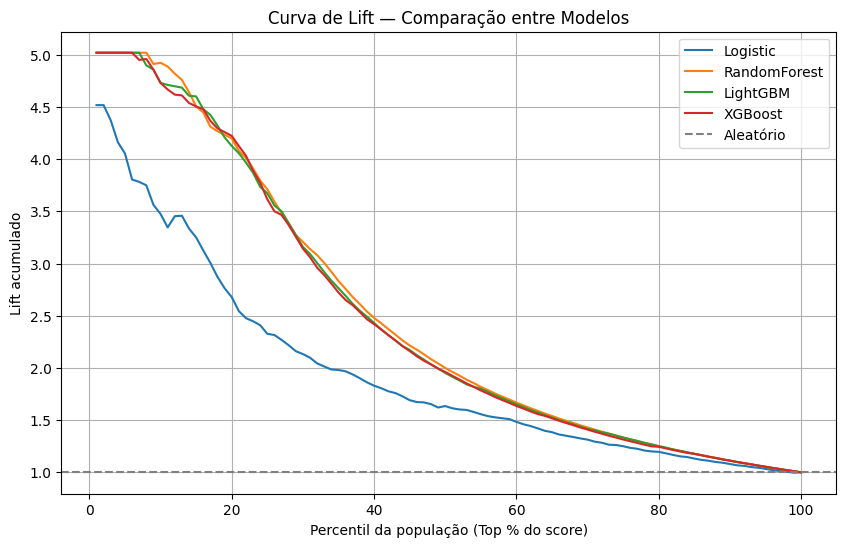

In [ ]:
plt.figure(figsize=(10,6))

percentil = range(1,101)

for name, prob in models.items():

    lift = lift_curve(y_true, prob)

    plt.plot(percentil, lift, label=name)

plt.axhline(1, linestyle="--", color="gray", label="Aleatório")

plt.xlabel("Percentil da população (Top % do score)")
plt.ylabel("Lift acumulado")

plt.title("Curva de Lift — Comparação entre Modelos")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
lift_table = pd.DataFrame()

for name, prob in models.items():

    lift_table[name] = lift_curve(y_true, prob)

lift_table["percentil"] = range(1,101)

lift_table.head(20)

,Logistic,RandomForest,LightGBM,XGBoost,percentil
0,4.517308,5.019231,5.019231,5.019231,1
1,4.517308,5.019231,5.019231,5.019231,2
2,4.371588,5.019231,5.019231,5.019231,3
3,4.162289,5.019231,5.019231,5.019231,4
4,4.053994,5.019231,5.019231,5.019231,5
5,3.804901,5.019231,5.019231,5.019231,6
6,3.781612,5.019231,5.019231,4.950474,7
7,3.749305,5.019231,4.898285,4.958758,8
8,3.562035,4.911290,4.857320,4.857320,9
9,3.474852,4.922707,4.729660,4.729660,10


#### . Analise Financeira - Matriz de Confusão

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

lucro_bom = 4200
perda_default = -11250

def tabela_financeira(y_true, y_prob):

    thresholds = np.arange(0.05,1.0,0.05)
    rows = []

    for t in thresholds:

        y_pred = (y_prob >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        # clientes aprovados (predito = bom)
        aprovados = tn + fn

        # taxa de default entre aprovados
        default_rate = fn / aprovados if aprovados > 0 else 0

        # lucro financeiro
        lucro = tn * lucro_bom + fn * perda_default

        approval_rate = aprovados / len(y_true)
        rows.append({
            "threshold": t,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "aprovados": aprovados,
            "default_rate": default_rate,
            "approval_rate": approval_rate,
            "lucro": lucro
        })

    return pd.DataFrame(rows)

In [ ]:
tabelas_financeiras = {}

for m in ["Logistic","RandomForest","LightGBM","XGBoost"]:

    tabelas_financeiras[m] = tabela_financeira(
        y_test,
        resultados[m]["y_prob"]
    )

In [ ]:
comparacao_modelos = []

for m in tabelas_financeiras:

    df = tabelas_financeiras[m]

    idx = df["lucro"].idxmax()

    comparacao_modelos.append({

        "modelo": m,

        "threshold_otimo": df.loc[idx,"threshold"],

        "lucro_max": df.loc[idx,"lucro"],

        "taxa_aprovacao":
            df.loc[idx,"aprovados"] / len(y_test),

        "taxa_default":
            df.loc[idx,"default_rate"],

        "clientes_aprovados":
            df.loc[idx,"aprovados"]
    })

comparacao_modelos = pd.DataFrame(comparacao_modelos)

comparacao_modelos

,modelo,threshold_otimo,lucro_max,taxa_aprovacao,taxa_default,clientes_aprovados
0,Logistic,0.35,2079450,0.837165,0.117849,874
1,RandomForest,0.25,3055200,0.767241,0.024969,801
2,LightGBM,0.10,3014250,0.782567,0.033048,817
3,XGBoost,0.10,3046650,0.775862,0.028395,810


In [ ]:
tabelas_financeiras["Logistic"].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
threshold,5.000000e-02,1.000000e-01,1.500000e-01,2.000000e-01,2.500000e-01,0.300000,0.350000,0.400000,0.450000,0.500000,0.550000,0.600000,0.650000,0.700000,0.750000,0.8,0.85,0.900000,0.950000
TP,2.000000e+02,1.850000e+02,1.580000e+02,1.390000e+02,1.260000e+02,111.000000,105.000000,92.000000,74.000000,66.000000,58.000000,49.000000,39.000000,36.000000,30.000000,27.0,18.00,13.000000,8.000000
FP,6.810000e+02,4.440000e+02,3.080000e+02,2.110000e+02,1.520000e+02,107.000000,65.000000,42.000000,38.000000,28.000000,19.000000,16.000000,10.000000,7.000000,5.000000,3.0,2.00,2.000000,1.000000
TN,1.550000e+02,3.920000e+02,5.280000e+02,6.250000e+02,6.840000e+02,729.000000,771.000000,794.000000,798.000000,808.000000,817.000000,820.000000,826.000000,829.000000,831.000000,833.0,834.00,834.000000,835.000000
FN,8.000000e+00,2.300000e+01,5.000000e+01,6.900000e+01,8.200000e+01,97.000000,103.000000,116.000000,134.000000,142.000000,150.000000,159.000000,169.000000,172.000000,178.000000,181.0,190.00,195.000000,200.000000
aprovados,8.810000e+02,6.290000e+02,4.660000e+02,3.500000e+02,2.780000e+02,218.000000,170.000000,134.000000,112.000000,94.000000,77.000000,65.000000,49.000000,43.000000,35.000000,30.0,20.00,15.000000,9.000000
default_rate,7.729852e-01,7.058824e-01,6.609442e-01,6.028571e-01,5.467626e-01,0.490826,0.382353,0.313433,0.339286,0.297872,0.246753,0.246154,0.204082,0.162791,0.142857,0.1,0.10,0.133333,0.111111
lucro,-6.821250e+06,-4.218000e+06,-2.801400e+06,-1.789950e+06,-1.180800e+06,-737550.000000,-290250.000000,-86100.000000,-116700.000000,-37800.000000,29850.000000,25800.000000,51300.000000,72450.000000,69750.000000,79650.0,53100.00,32100.000000,22350.000000


In [ ]:
tabelas_financeiras["RandomForest"].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
threshold,5.000000e-02,1.000000e-01,0.150000,0.200000,0.250000,0.300000,0.350000,0.400000,0.450000,0.500000,0.550000,0.60000,0.650000,0.700000,0.75,0.8,0.85,0.9,0.95
TP,2.080000e+02,2.060000e+02,200.000000,194.000000,188.000000,182.000000,169.000000,161.000000,151.000000,142.000000,135.000000,124.00000,115.000000,95.000000,82.00,60.0,38.00,17.0,3.00
FP,3.010000e+02,1.760000e+02,113.000000,79.000000,55.000000,45.000000,32.000000,29.000000,22.000000,16.000000,8.000000,5.00000,3.000000,2.000000,0.00,0.0,0.00,0.0,0.00
TN,5.350000e+02,6.600000e+02,723.000000,757.000000,781.000000,791.000000,804.000000,807.000000,814.000000,820.000000,828.000000,831.00000,833.000000,834.000000,836.00,836.0,836.00,836.0,836.00
FN,0.000000e+00,2.000000e+00,8.000000,14.000000,20.000000,26.000000,39.000000,47.000000,57.000000,66.000000,73.000000,84.00000,93.000000,113.000000,126.00,148.0,170.00,191.0,205.00
aprovados,5.090000e+02,3.820000e+02,313.000000,273.000000,243.000000,227.000000,201.000000,190.000000,173.000000,158.000000,143.000000,129.00000,118.000000,97.000000,82.00,60.0,38.00,17.0,3.00
default_rate,5.913556e-01,4.607330e-01,0.361022,0.289377,0.226337,0.198238,0.159204,0.152632,0.127168,0.101266,0.055944,0.03876,0.025424,0.020619,0.00,0.0,0.00,0.0,0.00
lucro,-2.512650e+06,-1.114800e+06,-431250.000000,-73950.000000,170850.000000,258150.000000,349800.000000,349950.000000,386700.000000,416400.000000,477000.000000,464550.00000,449250.000000,376500.000000,344400.00,252000.0,159600.00,71400.0,12600.00


In [ ]:
tabelas_financeiras["LightGBM"].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
threshold,0.050000,0.100000,0.150000,0.200000,0.25,0.300000,0.350000,0.400000,0.450000,0.500000,0.550000,0.600000,0.6500,0.70000,0.750000,0.800000,0.850000,0.900000,0.950000
TP,185.000000,181.000000,174.000000,170.000000,166.00,165.000000,162.000000,160.000000,154.000000,152.000000,151.000000,147.000000,146.0000,139.00000,135.000000,129.000000,122.000000,112.000000,97.000000
FP,63.000000,46.000000,38.000000,37.000000,34.00,29.000000,28.000000,26.000000,20.000000,18.000000,18.000000,17.000000,14.0000,12.00000,12.000000,9.000000,9.000000,8.000000,6.000000
TN,773.000000,790.000000,798.000000,799.000000,802.00,807.000000,808.000000,810.000000,816.000000,818.000000,818.000000,819.000000,822.0000,824.00000,824.000000,827.000000,827.000000,828.000000,830.000000
FN,23.000000,27.000000,34.000000,38.000000,42.00,43.000000,46.000000,48.000000,54.000000,56.000000,57.000000,61.000000,62.0000,69.00000,73.000000,79.000000,86.000000,96.000000,111.000000
aprovados,248.000000,227.000000,212.000000,207.000000,200.00,194.000000,190.000000,186.000000,174.000000,170.000000,169.000000,164.000000,160.0000,151.00000,147.000000,138.000000,131.000000,120.000000,103.000000
default_rate,0.254032,0.202643,0.179245,0.178744,0.17,0.149485,0.147368,0.139785,0.114943,0.105882,0.106509,0.103659,0.0875,0.07947,0.081633,0.065217,0.068702,0.066667,0.058252
lucro,68250.000000,242700.000000,303300.000000,297750.000000,314700.00,366750.000000,365400.000000,379500.000000,421800.000000,435900.000000,431700.000000,426150.000000,455700.0000,448800.00000,432000.000000,440550.000000,411150.000000,380400.000000,339900.000000


In [ ]:
tabelas_financeiras["XGBoost"].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
threshold,0.050000,0.100000,0.150000,0.200000,0.250000,0.30,0.350000,0.400000,0.45000,0.500000,0.550000,0.600000,0.65000,0.7,0.750000,0.800000,0.850000,0.900000,0.950000
TP,188.000000,185.000000,181.000000,180.000000,173.000000,170.00,165.000000,161.000000,159.00000,156.000000,153.000000,151.000000,148.00000,144.0,137.000000,133.000000,126.000000,117.000000,104.000000
FP,63.000000,49.000000,40.000000,36.000000,32.000000,30.00,30.000000,29.000000,25.00000,23.000000,22.000000,19.000000,17.00000,16.0,16.000000,14.000000,13.000000,11.000000,8.000000
TN,773.000000,787.000000,796.000000,800.000000,804.000000,806.00,806.000000,807.000000,811.00000,813.000000,814.000000,817.000000,819.00000,820.0,820.000000,822.000000,823.000000,825.000000,828.000000
FN,20.000000,23.000000,27.000000,28.000000,35.000000,38.00,43.000000,47.000000,49.00000,52.000000,55.000000,57.000000,60.00000,64.0,71.000000,75.000000,82.000000,91.000000,104.000000
aprovados,251.000000,234.000000,221.000000,216.000000,205.000000,200.00,195.000000,190.000000,184.00000,179.000000,175.000000,170.000000,165.00000,160.0,153.000000,147.000000,139.000000,128.000000,112.000000
default_rate,0.250996,0.209402,0.180995,0.166667,0.156098,0.15,0.153846,0.152632,0.13587,0.128492,0.125714,0.111765,0.10303,0.1,0.104575,0.095238,0.093525,0.085938,0.071429
lucro,80850.000000,225750.000000,310200.000000,351000.000000,366600.000000,376500.00,355500.000000,349950.000000,386550.00000,396450.000000,395100.000000,420450.000000,430350.00000,424800.0,395400.000000,401100.000000,382950.000000,367650.000000,346800.000000


#####.Approval vs Profit Frontier - ponto ótimo por modelo

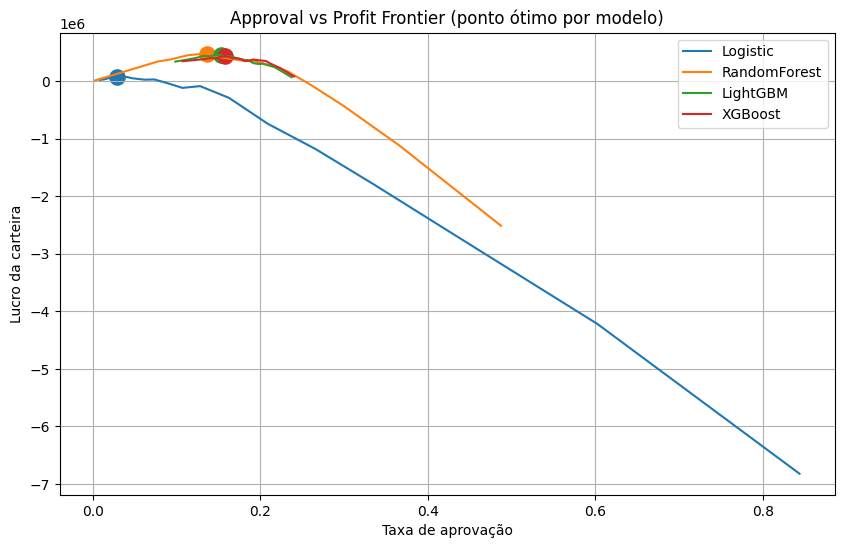

In [ ]:
plt.figure(figsize=(10,6))

for m in tabelas_financeiras:

    df = tabelas_financeiras[m]

    approval_rate = df["aprovados"] / len(y_test)

    plt.plot(
        approval_rate,
        df["lucro"],
        label=m
    )

    idx = df["lucro"].idxmax()

    plt.scatter(
        approval_rate.loc[idx],
        df["lucro"].loc[idx],
        s=120
    )

plt.xlabel("Taxa de aprovação")
plt.ylabel("Lucro da carteira")

plt.title("Approval vs Profit Frontier (ponto ótimo por modelo)")

plt.legend()
plt.grid()

plt.show()

###Análise Financeira - nivel cliente

In [ ]:
# parâmetros financeiros
taxa_juros = 0.10          # lucro se cliente pagar
taxa_recuperacao = 0.20    # recuperação em default

In [ ]:
def calcular_ev(pd, loan, taxa_juros=0.10, taxa_recuperacao=0.20):

    lucro = loan * taxa_juros

    perda = -(loan * (1 - taxa_recuperacao))

    ev = (1 - pd) * lucro + pd * perda

    return ev

In [ ]:
df_fin = df_scores.copy()

df_fin["loan"] = x_test["LOAN"].values

In [ ]:
modelos = ["Logistic", "RandomForest", "LightGBM", "XGBoost"]

for m in modelos:

    df_fin[f"EV_{m}"] = calcular_ev(
        df_fin[m],
        df_fin["loan"]
    )

In [ ]:
for m in modelos:

    df_fin[f"aprovar_{m}"] = df_fin[f"EV_{m}"] > 0

#####.Resumo financeiro

In [ ]:
resultado_financeiro = []

for m in modelos:

    aprovados = df_fin[df_fin[f"aprovar_{m}"]]

    ev_total = aprovados[f"EV_{m}"].sum()

    taxa_aprovacao = len(aprovados) / len(df_fin)

    default_rate = aprovados["y_true"].mean()

    resultado_financeiro.append({
        "Modelo": m,
        "EV_total": ev_total,
        "Clientes_aprovados": len(aprovados),
        "Taxa_aprovacao": taxa_aprovacao,
        "Default_rate": default_rate
    })

df_resultado_financeiro = pd.DataFrame(resultado_financeiro)

df_resultado_financeiro

,Modelo,EV_total,Clientes_aprovados,Taxa_aprovacao,Default_rate
0,Logistic,4.840879e+05,452,0.432950,0.059735
1,RandomForest,1.016574e+06,681,0.652299,0.002937
2,LightGBM,1.546243e+06,821,0.786398,0.034105
3,XGBoost,1.527780e+06,814,0.779693,0.029484


#####.Lucro Esperado por Modelo

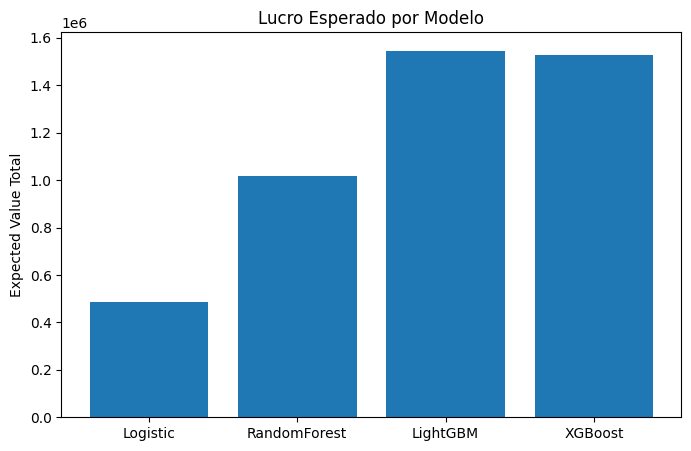

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df_resultado_financeiro["Modelo"],
    df_resultado_financeiro["EV_total"]
)

plt.title("Lucro Esperado por Modelo")
plt.ylabel("Expected Value Total")

plt.show()

In [ ]:
df_resultado_financeiro.round(3)

,Modelo,EV_total,Clientes_aprovados,Taxa_aprovacao,Default_rate
0,Logistic,484087.876,452,0.433,0.060
1,RandomForest,1016573.500,681,0.652,0.003
2,LightGBM,1546242.508,821,0.786,0.034
3,XGBoost,1527779.553,814,0.780,0.029


#####.Profit Curve

In [ ]:
def curva_lucro(df, modelo):

    temp = df.copy()

    # ordenar pelo score do modelo
    temp = temp.sort_values(by=modelo, ascending=False)

    # lucro acumulado
    temp["ev_acum"] = temp[f"EV_{modelo}"].cumsum()

    # proporção da população
    temp["pop"] = np.arange(1, len(temp)+1) / len(temp)

    return temp

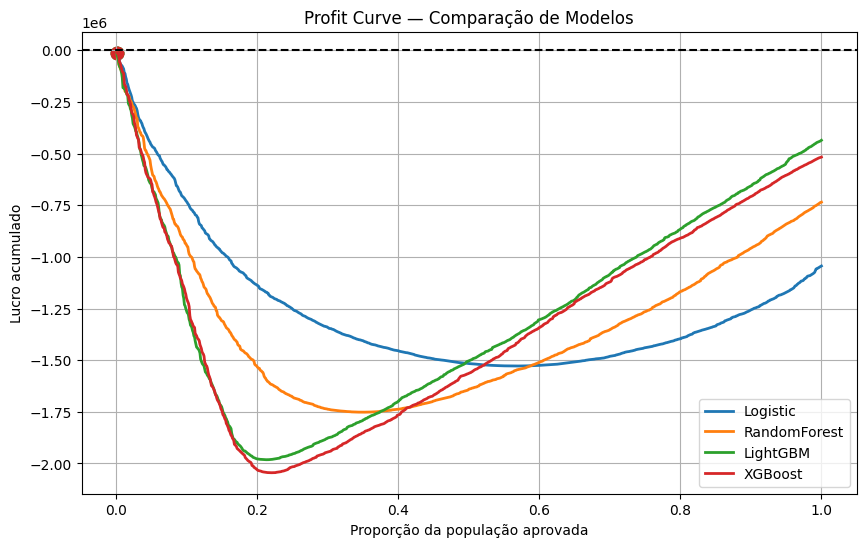

In [ ]:
plt.figure(figsize=(10,6))

for m in ["Logistic","RandomForest","LightGBM","XGBoost"]:

    temp = curva_lucro(df_fin, m)

    plt.plot(
        temp["pop"],
        temp["ev_acum"],
        linewidth=2,
        label=m
    )

    # ponto ótimo
    idx = temp["ev_acum"].idxmax()

    plt.scatter(
        temp.loc[idx,"pop"],
        temp.loc[idx,"ev_acum"],
        s=80
    )

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Proporção da população aprovada")
plt.ylabel("Lucro acumulado")

plt.title("Profit Curve — Comparação de Modelos")

plt.legend()
plt.grid(True)

plt.show()

#####.Acceptance Rate vs Default Rate

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def curva_risco(df, modelo):

    temp = df.copy()

    # ordenar pelo score do modelo (melhores clientes primeiro)
    temp = temp.sort_values(by=modelo, ascending=False)

    # proporção da população
    temp["pop"] = np.arange(1, len(temp)+1) / len(temp)

    # default acumulado
    temp["default_acum"] = temp["y_true"].cumsum()

    # clientes acumulados
    temp["clientes"] = np.arange(1, len(temp)+1)

    # taxa de default
    temp["default_rate"] = temp["default_acum"] / temp["clientes"]

    return temp

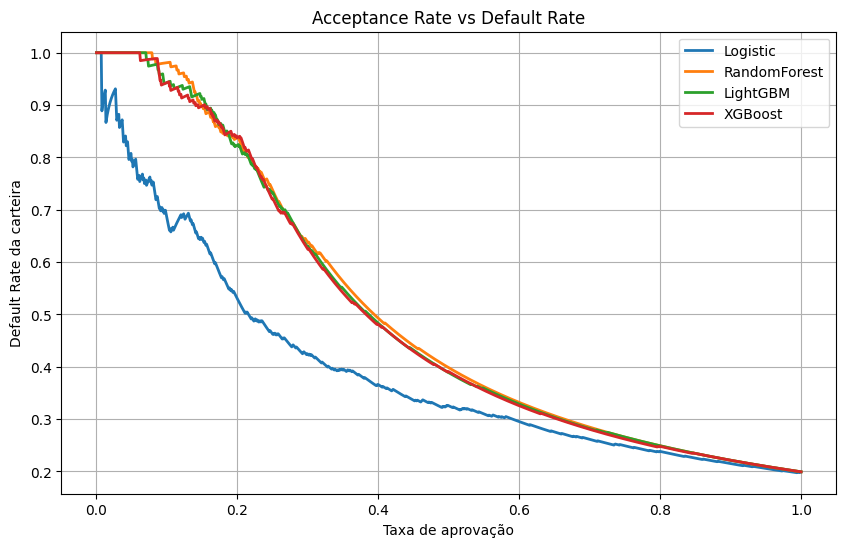

In [ ]:
plt.figure(figsize=(10,6))

for m in ["Logistic","RandomForest","LightGBM","XGBoost"]:

    temp = curva_risco(df_fin, m)

    plt.plot(
        temp["pop"],
        temp["default_rate"],
        linewidth=2,
        label=m
    )

plt.xlabel("Taxa de aprovação")
plt.ylabel("Default Rate da carteira")

plt.title("Acceptance Rate vs Default Rate")

plt.legend()
plt.grid(True)

plt.show()